## Defining p.d.f.s

### Imports

In [1]:
import numpy as np
from scipy.stats import expon, uniform, norm, crystalball, poisson
from scipy.integrate import dblquad, quad #2D, 1D integration (as seen in C1)

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

### Defining functions

In [2]:
# set parameters to default values
mu = 3
sigma = 0.3
beta = 1
m = 1.4
fraction = 0.6
a = 0.3
mu_b = 0
sigma_b = 2.5
x_left = 0
x_right = 5
y_left = 0
y_right = 10
X = np.linspace(x_left, x_right, 1000)
Y = np.linspace(y_left, y_right, 1000)

# define the gsX function given by crystalball
def g_s(X, beta, m, mu, sigma, x_left, x_right):
    return crystalball.pdf(X, beta=beta, m=m, loc=mu, scale=sigma) / (crystalball.cdf(x_right, beta=beta, m=m, loc=mu, scale=sigma) - crystalball.cdf(x_left, beta=beta, m=m, loc=mu, scale=sigma))

# Create the exponential distribution with decay constant a=0.3 (default value)
def h_s(Y, a, y_left, y_right):
    return expon.pdf(Y, scale=1/a) / (expon.cdf(y_right, scale=1/a) - expon.cdf(y_left, scale=1/a))

# define gbX given by uniform distribution 
def g_b(X, x_left, x_right):
    return uniform.pdf(X, loc=x_left, scale=(x_right-x_left))

# define hbY given by normal distribution
def h_b(Y, mu_b, sigma_b, y_left, y_right):
    return norm.pdf(Y, loc=mu_b, scale=sigma_b) / (norm.cdf(y_right, loc=mu_b, scale=sigma_b) - norm.cdf(y_left, loc=mu_b,scale=sigma_b))

# define the signal function
def s(X, Y, beta, m, mu, sigma, x_left, x_right, a, y_left, y_right):
    return g_s(X, beta, m, mu, sigma, x_left, x_right) * h_s(Y, a, y_left, y_right)

# define the background
def b(X, Y, x_left, x_right, mu_b, sigma_b, y_left, y_right):
    return g_b(X, x_left,x_right) * h_b(Y, mu_b, sigma_b, y_left, y_right)

# define function f
def f(X, Y, fraction, beta, m, mu, sigma, x_left, x_right, a, y_left, y_right, mu_b, sigma_b):
    return fraction*s(X, Y, beta, m, mu, sigma, x_left, x_right, a, y_left, y_right)+(1-fraction)*b(X, Y, x_left, x_right, mu_b, sigma_b, y_left, y_right)

### Integrating to check the validity of the definitions above

In [3]:
# signal in X integration
result_gs, abserror_gs = quad(lambda X: g_s(X, beta, m, mu, sigma, x_left, x_right), x_left, x_right)
print(f"Signal in X integral: {result_gs}, with error: {abserror_gs}")

# signal in Y integration
result_hs, abserror_hs = quad(lambda Y: h_s(Y, a, y_left, y_right), y_left, y_right)
print(f"Signal in Y integral: {result_hs}, with error: {abserror_hs}")

# background in X integration
result_gb, abserror_gb = quad(lambda X: g_b(X, x_left, x_right), x_left, x_right)
print(f"Background in X integral: {result_gb}, with error: {abserror_gb}")

# background in Y integration
result_hb, abserror_hb = quad(lambda Y: h_b(Y, mu_b, sigma_b, y_left, y_right), y_left, y_right)
print(f"Background in Y integral: {result_hb}, with error: {abserror_hb}")

# signal in X,Y integration
result_s, abserror_s = dblquad(lambda Y,X: s(X, Y, beta, m, mu, sigma, x_left, x_right, a, y_left, y_right), x_left, x_right, lambda X: y_left, lambda X: y_right)
print(f"Signal integral: {result_s}, with error: {abserror_s}")

# background in X,Y integration
result_b, abserror_b = dblquad(lambda Y,X: b(X, Y, x_left, x_right, mu_b, sigma_b, y_left, y_right), x_left, x_right, lambda X: y_left, lambda X: y_right)
print(f"Background integral: {result_b}, with error: {abserror_b}")

# whole function integration
result, abserror = dblquad(lambda Y,X: f(X, Y, fraction, beta, m, mu, sigma, x_left, x_right, a, y_left, y_right, mu_b, sigma_b), x_left, x_right, lambda X: y_left, lambda X: y_right)
print(f"Whole thing integral: {result}, with error: {abserror}")

results = np.array([result_gs, result_hs, result_gb, result_hb, result_s, result_b, result])
abs_errors = np.array([abserror_gs, abserror_hs, abserror_gb, abserror_hb, abserror_s, abserror_b, abserror])

Signal in X integral: 1.0000000376260723, with error: 7.2897966170979746e-09
Signal in Y integral: 0.9999999999999999, with error: 1.1102230246251564e-14
Background in X integral: 1.0, with error: 1.1102230246251565e-14
Background in Y integral: 1.0000000000000004, with error: 4.839198166838126e-12
Signal integral: 1.0000000376260723, with error: 7.2897964287314e-09
Background integral: 1.0000000000000002, with error: 9.678414025637658e-13
Whole thing integral: 1.0000000225756436, with error: 4.373878973809868e-09


### Checking validity with other values of parameters

In [4]:
# set parameters to different values
mu1 = 8
sigma1 = 0.5
beta1 = 2
m1 = 2.5
fraction1 = 0.5
a1 = 0.4
mu_b1 = 7
sigma_b1 = 2
x_left1 = 5
x_right1 = 10
y_left1 = 10
y_right1 = 20
X1 = np.linspace(x_left1,x_right1,1000)
Y1 = np.linspace(y_left1,y_right1,1000)

# signal in X integration
result_gs1, abserror_gs1 = quad(lambda X1: g_s(X1, beta1, m1, mu1, sigma1, x_left1, x_right1), x_left1, x_right1)
print(f"Signal in X integral: {result_gs1}, with error: {abserror_gs1}")

# signal in Y integration
result_hs1, abserror_hs1 = quad(lambda Y1: h_s(Y1, a1, y_left1, y_right1), y_left1, y_right1)
print(f"Signal in Y integral: {result_hs1}, with error: {abserror_hs1}")

# background in X integration
result_gb1, abserror_gb1 = quad(lambda X1: g_b(X1, x_left1, x_right1), x_left1, x_right1)
print(f"Background in X integral: {result_gb1}, with error: {abserror_gb1}")

# background in Y integration
result_hb1, abserror_hb1 = quad(lambda Y1: h_b(Y1, mu_b1, sigma_b1, y_left1, y_right1), y_left1, y_right1)
print(f"Background in Y integral: {result_hb1}, with error: {abserror_hb1}")

# signal in X,Y integration
result_s1, abserror_s1 = dblquad(lambda Y1,X1: s(X1, Y1, beta1, m1, mu1, sigma1, x_left1, x_right1, a1, y_left1, y_right1), x_left1, x_right1, lambda X1: y_left1, lambda X1: y_right1)
print(f"Signal integral: {result_s1}, with error: {abserror_s1}")

# background in X,Y integration
result_b1, abserror_b1 = dblquad(lambda Y1,X1: b(X1, Y1, x_left1, x_right1, mu_b1, sigma_b1, y_left1, y_right1), x_left1, x_right1, lambda X1: y_left1, lambda X1: y_right1)
print(f"Background integral: {result_b1}, with error: {abserror_b1}")

# whole function integration
result1, abserror1 = dblquad(lambda Y1,X1: f(X1, Y1, fraction1, beta1, m1, mu1, sigma1, x_left1, x_right1, a1, y_left1, y_right1, mu_b1, sigma_b1), x_left1, x_right1, lambda X1: y_left1, lambda X1: y_right1)
print(f"Whole thing integral: {result1}, with error: {abserror1}")
results1 = np.array([result_gs1, result_hs1, result_gb1, result_hb1, result_s1, result_b1, result1])
abs_errors1 = np.array([abserror_gs1, abserror_hs1, abserror_gb1, abserror_hb1, abserror_s1, abserror_b1, abserror1])

Signal in X integral: 1.0000000001010898, with error: 7.00326701449574e-09
Signal in Y integral: 0.9999999999999982, with error: 1.1102230246251546e-14
Background in X integral: 1.0, with error: 1.1102230246251565e-14
Background in Y integral: 1.0000000000000002, with error: 1.2195641902095039e-09
Signal integral: 1.000000000101088, with error: 7.0032670927708756e-09
Background integral: 1.0000000000000002, with error: 2.439128360604066e-10
Whole thing integral: 1.000000000050544, with error: 3.5016362048255007e-09


#### Error plot

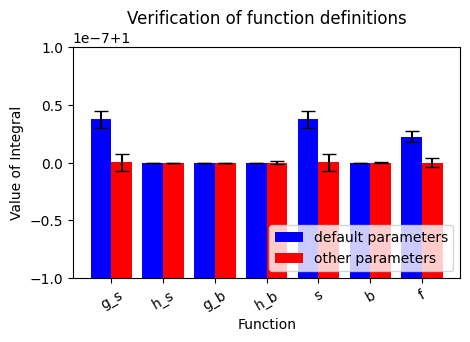

In [5]:
# we make a bar plot with errors to visualize integration results

functions_list = [g_s, h_s, g_b, h_b, s, b, f]

# Create the bar positions
indices = np.arange(len(functions_list))

# Create labels for x-axis
labels = ['g_s', 'h_s', 'g_b', 'h_b', 's', 'b','f']  # Text labels for x-axis

plt.figure(figsize=(5, 3))
# Plot the bars
plt.bar(indices - 0.2, results, width=0.4, label='default parameters', color='b', yerr=abs_errors, ecolor='black', capsize=5)
plt.bar(indices + 0.2, results1, width=0.4, label='other parameters', color='r', yerr=abs_errors1, ecolor='black', capsize=5)

# 
plt.xlabel("Function")
plt.ylabel("Value of Integral")
plt.title("Verification of function definitions")
plt.xticks(indices, labels, rotation=30)
plt.legend(loc='lower right')
plt.ylim([0.9999999, 1.0000001])

# Show plot
plt.show()

## Plots

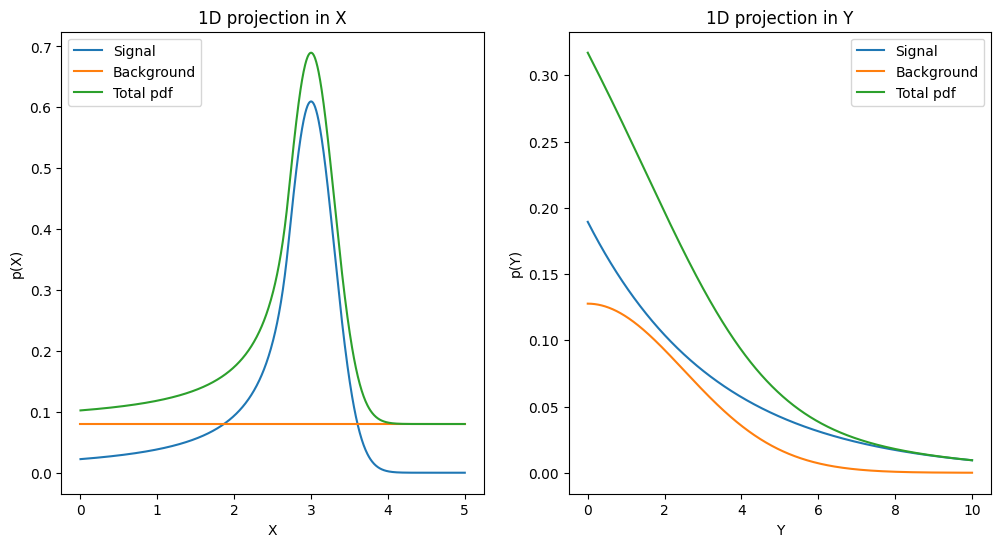

In [6]:
fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].plot(X, fraction*g_s(X, beta, m, mu, sigma, x_left, x_right), label="Signal")
ax[0].plot(X, (1-fraction)*g_b(X, x_left, x_right), label="Background")
ax[0].plot(X, (fraction*g_s(X, beta, m, mu, sigma, x_left, x_right) + (1-fraction)*g_b(X, x_left, x_right)), label="Total pdf")
ax[0].set_xlabel('X')
ax[0].set_ylabel('p(X)')
ax[0].set_title('1D projection in X')
ax[0].legend(loc="upper left")

ax[1].plot(Y, fraction*h_s(Y, a, y_left, y_right), label="Signal")
ax[1].plot(Y, (1-fraction)*h_b(Y, mu_b, sigma_b, y_left, y_right), label="Background")
ax[1].plot(Y, (fraction*h_s(Y, a, y_left, y_right) + (1-fraction)*h_b(Y, mu_b, sigma_b, y_left, y_right)), label="Total pdf")
ax[1].set_xlabel('Y')
ax[1].set_ylabel('p(Y)')
ax[1].set_title('1D projection in Y')
ax[1].legend(loc="upper right")

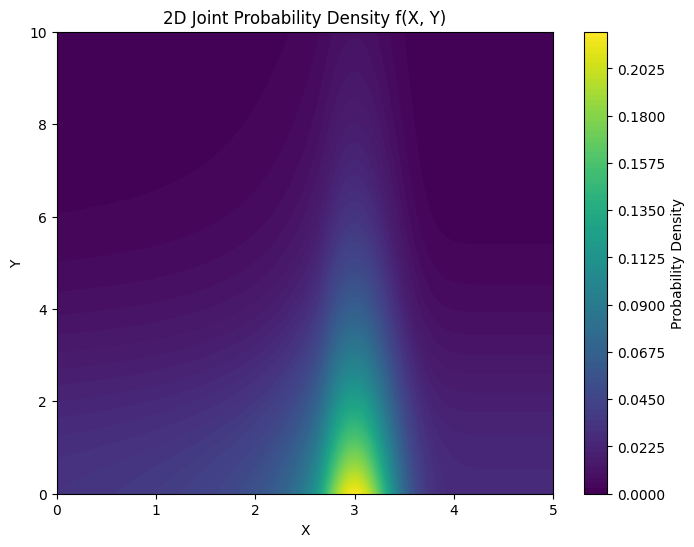

In [7]:
X_grid, Y_grid = np.meshgrid(X, Y)

# Plot the 2D joint probability density
plt.figure(figsize=(8, 6))
plt.contourf(X_grid, Y_grid, f(X_grid, Y_grid, fraction, beta, m, mu, sigma, x_left, x_right, a, y_left, y_right, mu_b, sigma_b), 100, cmap='viridis')
plt.colorbar(label='Probability Density')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Joint Probability Density f(X, Y)')
plt.show()

## High-Statistics Sample Generation

### The call which generates the sample of 100,000 random normals

In [8]:
import timeit

# Set the random seed for reproducibility
np.random.seed(24)

num = 100 # setting the number of times to generate

# define a callable function so it can be used by timeit.timeit module
def random_normal_gen():
    np.random.normal(size=100000)

avg_gen_time_rand_normals = timeit.timeit(random_normal_gen, number = num) / num
print(f"Average generation time: {avg_gen_time_rand_normals} seconds")

Average generation time: 0.0011235599988140166 seconds


### The call which generates our sample of 100,000 events

#### Redefining the function so it can be used by iMinuit module

In [9]:
def func(XY, fraction, beta, m, mu, sigma, x_left, x_right, a, y_left, y_right, mu_b, sigma_b):
    
    # If XY is 1D, extract X and Y directly
    if XY.ndim == 1:
        X = XY[0]
        Y = XY[1]
    # If XY is 2D (e.g., from np.column_stack), split columns
    elif XY.ndim == 2:
        X = XY[:, 0]
        Y = XY[:, 1]
    else:
        raise ValueError("Unexpected shape for XY. Expected 1D or 2D array.")

    # putting the functions in here to reduce the number of calls (hence, time taken)
    g_s = crystalball.pdf(X, beta=beta, m=m, loc=mu, scale=sigma) / (crystalball.cdf(x_right, beta=beta, m=m, loc=mu, scale=sigma) - crystalball.cdf(x_left, beta=beta, m=m, loc=mu, scale=sigma))
    h_s = expon.pdf(Y, scale=1/a) / (expon.cdf(y_right, scale=1/a) - expon.cdf(y_left, scale=1/a))
    g_b = uniform.pdf(X, loc=x_left, scale=(x_right-x_left))
    h_b = norm.pdf(Y, loc=mu_b, scale=sigma_b) / (norm.cdf(y_right, loc=mu_b, scale=sigma_b) - norm.cdf(y_left, loc=mu_b,scale=sigma_b))

    return fraction*(g_s*h_s) + (1-fraction)*(g_b*h_b)

#### Accept/Reject generation in 2D

In [10]:
# Set the random seed for reproducibility
np.random.seed(24)

# finding max value of function
x_vals = np.linspace(x_left, x_right, 100)
y_vals = np.linspace(y_left, y_right, 100)
xrange = (x_left, x_right)
yrange = (y_left, y_right)
res = []
for i in range(100):
    for j in range(100):
        XY = np.array([x_vals[i], y_vals[j]])
        res.append(func(XY, fraction, beta, m, mu, sigma, x_left, x_right, a, y_left, y_right, mu_b, sigma_b))

fmax = (np.array(res)).max()
print(f'fmax: {fmax}')

# from Prof Kenzie's function
# f_to_min = lambda xy: -func(xy, fraction, beta, m, mu, sigma, x_left, x_right, a, y_left, y_right, mu_b, sigma_b)
# x0 = brute(f_to_min, (xrange, yrange), Ns=20)
# # local
# x0 = minimize(f_to_min, x0=x0, bounds=[xrange, yrange]).x
# fmax = func(x0, fraction, beta, m, mu, sigma, x_left, x_right, a, y_left, y_right, mu_b, sigma_b)
# print(f'fmax: {fmax}')


def accept_reject_2d(func, xrange, yrange, size=1, params={}, fmax=None):
    # define the array to store the result
    result = []

    # defining batch size to use batches to speed up the process
    batch_size = size//100

    # defining the number of rejections
    nrej = 0

    # while we haven't reached the desired number of samples
    while len(result)<size:
        # generate uniform randoms in xrange and yrange
        x = np.random.uniform(xrange[0], xrange[1], batch_size)
        y = np.random.uniform(yrange[0], yrange[1], batch_size)
        points = np.column_stack((x, y))

        # compute the value of the func at these (x,y)
        fvals = func(points, **params)

        # check it's not negative
        if np.any(fvals < 0):
            raise RuntimeError(f'Accept-reject found a negative function value. p.d.f.s cannot be negative. Bailing out')

        # check it's not bigger than fmax
        for val in fvals:
            if round(val, 3) > round(fmax, 3):
                raise RuntimeError(f'Accept-reject found a larger function value than was provided {val}. Updating fmax and bailing out')

        # now generate random between [0, fmax]
        ftests = np.random.uniform(0, fmax, batch_size)

        # if ftest larger than fval reject, otherwise accept (performed on arrays)
        accepted = points[ftests <= fvals]

        # Append accepted points to the result
        result.extend(accepted.tolist())

        # Count rejections
        nrej += batch_size - len(accepted)

    return result[:size]  # to avoid returning more accidentally


fmax: 0.21761124621171438


In [11]:
# Set the random seed for reproducibility
np.random.seed(24)

xrange = (x_left, x_right)
yrange = (y_left, y_right)

params = { "fraction": fraction, "beta": beta, "m": m, "mu": mu, "sigma": sigma, "x_left": x_left,
    "x_right": x_right, "a": a, "y_left": y_left, "y_right": y_right, "mu_b": mu_b, "sigma_b": sigma_b}

# generate 100,000 events
num_events = 100000
sample = accept_reject_2d(func=func, xrange=xrange, yrange=yrange, size=num_events, params=params, fmax=fmax)

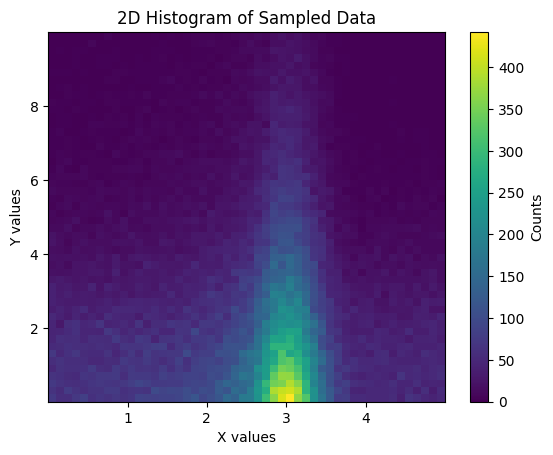

In [12]:
# make sample list into a NumPy array
sample = np.array(sample)

# Define the number of bins
num_bins_x = 50
num_bins_y = 50

# Create the 2D histogram
hist, x_edges, y_edges, im = plt.hist2d(sample[:, 0], sample[:, 1], bins=[num_bins_x, num_bins_y], cmap='viridis')

# Add a color bar
plt.colorbar(im, label='Counts')

# Add labels and title
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('2D Histogram of Sampled Data')

# Display the plot
plt.show()

#### Timing the sample generation

In [13]:
# Set the random seed for reproducibility
np.random.seed(24)

num = 100 # setting the number of times to generate

# define a callable function so it can be used by timeit.timeit module
def generating_our_sample():
    return accept_reject_2d(func=func, xrange=xrange, yrange=yrange, size=num_events, params=params, fmax=fmax)

avg_gen_time_sample = timeit.timeit(generating_our_sample, number = num) / num
print(f"Average generation time: {avg_gen_time_sample} seconds")

Average generation time: 3.678703353330493 seconds


### Performing the fit to the sample to estimate the parameters

In [14]:
from iminuit import Minuit, cost
import random

In [15]:
# once again...
# redefining the function as our x and y ranges need to be fixed for the iMinuit
# and specific return type is required for iminuit
def func_extended(XY, N, fraction, beta, m, mu, sigma, a, mu_b, sigma_b):
    X,Y=XY
    # putting the functions in here to reduce the number of calls (hence, time taken)
    g_s = crystalball.pdf(X, beta=beta, m=m, loc=mu, scale=sigma) / (crystalball.cdf(5, beta=beta, m=m, loc=mu, scale=sigma) - crystalball.cdf(0, beta=beta, m=m, loc=mu, scale=sigma))
    h_s = expon.pdf(Y, scale=1/a) / (expon.cdf(10, scale=1/a) - expon.cdf(0, scale=1/a))
    g_b = uniform.pdf(X, loc=0, scale=(5))
    h_b = norm.pdf(Y, loc=mu_b, scale=sigma_b) / (norm.cdf(10, loc=mu_b, scale=sigma_b) - norm.cdf(0, loc=mu_b,scale=sigma_b))

    return N, N*(fraction*(g_s*h_s) + (1-fraction)*(g_b*h_b))

In [16]:
# Set the random seed for reproducibility
random.seed(24)
np.random.seed(24)

sample = np.array(sample)
X = sample[:, 0]
Y = sample[:, 1]
n2ll = cost.ExtendedUnbinnedNLL((X,Y), func_extended)
mi = Minuit(n2ll, N=100000, fraction=0.5, beta=2.0, m=1.5, mu=4.0, sigma=0.2, a=0.5, mu_b=0.0, sigma_b=3.0)
# Set parameter limits and fix/unfix parameters as needed
mi.limits["fraction"] = (0, 1)  # Fraction must be between 0 and 1
mi.limits["sigma"] = (0, None) 
mi.limits["sigma_b"] = (0, None)
mi.limits["a"] = (0, None)  # Avoid negative values for a
mi.limits["beta"] = (0, None)
mi.limits["m"] = (1, None) # m > 1

mi.migrad()
mi.hesse()
display(mi)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.461e+06                 │              Nfcn = 870              │
│ EDM = 7.71e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name     │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N        │ 100.00e3  │  0.32e3   │            │            │         │         │       │
│ 1 │ fraction │  0.6012   │  0.0035   │            │            │    0    │    1    │       │
│ 2 │ beta     │   0.972   │   0.022   │            │            │    0    │         │       │
│ 3 │ m        │   1.40    │   0.06    │            │            │    1    │         │       │
│ 4 │ mu       │  3.0083   │  0.0026   │            │            │         │         │       │
│ 5 │ sigma    │  0.2920   │  0.0024   │            │            │    0    │         │       │
│ 6 │ a        │  0.2983   │  0.0020   │            │            │    0    │         │       │
│ 7 │ mu_b     │   0.01    │   0.08    │            │            │         │         │       │
│ 8 │ sigma_b  │   2.48    │   0.04    │            │            │    0    │         │       │
└───┴──────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────────────────────────────────────────────────────────────────────────┐
│          │         N  fraction      beta         m        mu     sigma         a      mu_b   sigma_b │
├──────────┼───────────────────────────────────────────────────────────────────────────────────────────┤
│        N │     1e+05         0         0    -0.000      0e-6      0e-6      0e-6     0.000   -0.0000 │
│ fraction │         0  1.24e-05  0.009e-3 -0.080e-3     -0e-6      2e-6      2e-6  0.049e-3 -0.029e-3 │
│     beta │         0  0.009e-3   0.00048   -1.2e-3    -30e-6     24e-6      1e-6    0.1e-3   -0.1e-3 │
│        m │    -0.000 -0.080e-3   -1.2e-3   0.00377     55e-6    -49e-6    -11e-6    -0.001    0.0003 │
│       mu │      0e-6     -0e-6    -30e-6     55e-6   6.7e-06     -4e-6     -0e-6     -3e-6      2e-6 │
│    sigma │      0e-6      2e-6     24e-6    -49e-6     -4e-6  5.77e-06      0e-6     15e-6     -9e-6 │
│        a │      0e-6      2e-6      1e-6    -11e-6     -0e-6      0e-6  4.21e-06      9e-6      4e-6 │
│     mu_b │     0.000  0.049e-3    0.1e-3    -0.001     -3e-6     15e-6      9e-6   0.00612   -0.0027 │
│  sigma_b │   -0.0000 -0.029e-3   -0.1e-3    0.0003      2e-6     -9e-6      4e-6   -0.0027   0.00134 │
└──────────┴───────────────────────────────────────────────────────────────────────────────────────────┘

In [17]:
# define a wrapper function that passes the initial function to iMinuit
def f_extended(dset, n, fraction, beta, m, mu, sigma, a, mu_b, sigma_b):
    x, y = dset
    return n, n * f(x, y, fraction=fraction, beta=beta, m=m, mu=mu, sigma=sigma, x_left=0, x_right=5, a=a, y_left=0, y_right=10, mu_b=mu_b, sigma_b=sigma_b)

In [18]:
f_extended((sample[:,0],sample[:,1]), 100000, fraction, beta, m, mu, sigma, a, mu_b, sigma_b)

(100000,
 array([2817.24656192, 6030.87511665, 5838.91387532, ..., 2617.05756934,
        3969.51325447, 5949.6267399 ], shape=(100000,)))

In [19]:
# Set the random seed for reproducibility
random.seed(24)
np.random.seed(24)

X = sample[:,0]
Y = sample[:,1]
nll = cost.ExtendedUnbinnedNLL((X, Y), f_extended)

mi = Minuit(nll, n=100_000, beta=2.0, m=1.5, mu=4.0, sigma=0.2,
            a=0.5, fraction=0.5, mu_b=0.0, sigma_b=3.0)

mi.limits["fraction"] = (0, 1)  # Fraction must be between 0 and 1
mi.limits["sigma"] = (0, None) 
mi.limits["sigma_b"] = (0, None)
mi.limits["a"] = (0, None)  # Avoid negative values for a
mi.limits["beta"] = (0, None)
mi.limits["m"] = (1, None) # m > 1

mi.migrad()
mi.hesse()
display(mi)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.461e+06                 │              Nfcn = 870              │
│ EDM = 7.71e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name     │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ n        │ 100.00e3  │  0.32e3   │            │            │         │         │       │
│ 1 │ fraction │  0.6012   │  0.0035   │            │            │    0    │    1    │       │
│ 2 │ beta     │   0.972   │   0.022   │            │            │    0    │         │       │
│ 3 │ m        │   1.40    │   0.06    │            │            │    1    │         │       │
│ 4 │ mu       │  3.0083   │  0.0026   │            │            │         │         │       │
│ 5 │ sigma    │  0.2920   │  0.0024   │            │            │    0    │         │       │
│ 6 │ a        │  0.2983   │  0.0020   │            │            │    0    │         │       │
│ 7 │ mu_b     │   0.01    │   0.08    │            │            │         │         │       │
│ 8 │ sigma_b  │   2.48    │   0.04    │            │            │    0    │         │       │
└───┴──────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────────────────────────────────────────────────────────────────────────┐
│          │         n  fraction      beta         m        mu     sigma         a      mu_b   sigma_b │
├──────────┼───────────────────────────────────────────────────────────────────────────────────────────┤
│        n │     1e+05         0         0    -0.000      0e-6      0e-6      0e-6     0.000   -0.0000 │
│ fraction │         0  1.24e-05  0.009e-3 -0.080e-3     -0e-6      2e-6      2e-6  0.049e-3 -0.029e-3 │
│     beta │         0  0.009e-3   0.00048   -1.2e-3    -30e-6     24e-6      1e-6    0.1e-3   -0.1e-3 │
│        m │    -0.000 -0.080e-3   -1.2e-3   0.00377     55e-6    -49e-6    -11e-6    -0.001    0.0003 │
│       mu │      0e-6     -0e-6    -30e-6     55e-6   6.7e-06     -4e-6     -0e-6     -3e-6      2e-6 │
│    sigma │      0e-6      2e-6     24e-6    -49e-6     -4e-6  5.77e-06      0e-6     15e-6     -9e-6 │
│        a │      0e-6      2e-6      1e-6    -11e-6     -0e-6      0e-6  4.21e-06      9e-6      4e-6 │
│     mu_b │     0.000  0.049e-3    0.1e-3    -0.001     -3e-6     15e-6      9e-6   0.00612   -0.0027 │
│  sigma_b │   -0.0000 -0.029e-3   -0.1e-3    0.0003      2e-6     -9e-6      4e-6   -0.0027   0.00134 │
└──────────┴───────────────────────────────────────────────────────────────────────────────────────────┘

#### Timing the fit

In [20]:
# Set the random seed for reproducibility
np.random.seed(24)

num = 100 # setting the number of times to generate

# define a callable function so it can be used by timeit.timeit module
def fitting_sample():
    X = sample[:, 0]
    Y = sample[:, 1]
    n2ll = cost.ExtendedUnbinnedNLL((X,Y), func_extended)
    mi = Minuit(n2ll, N=100000, fraction=0.5, beta=2.0, m=1.5, mu=4.0, sigma=0.2, a=0.5, mu_b=0.0, sigma_b=3.0)
    # Set parameter limits and fix/unfix parameters as needed
    mi.limits["fraction"] = (0, 1)  # Fraction must be between 0 and 1
    mi.limits["sigma"] = (0, None) 
    mi.limits["sigma_b"] = (0, None)
    mi.limits["a"] = (0, None)  # Avoid negative values for a
    mi.limits["beta"] = (0, None)
    mi.limits["m"] = (1, None) # m > 1

    mi.migrad()
    mi.hesse()
    return mi

avg_fit_time = timeit.timeit(fitting_sample, number = num) / num
print(f"Average generation time: {avg_fit_time} seconds")

Average generation time: 8.831191644167994 seconds


#### Relative times

In [21]:
print(f"Average generation time of 100,000 random normals (np.random.normal(size=100000)): {avg_gen_time_rand_normals} seconds")
print(f"Compared to above, it takes {avg_gen_time_sample / avg_gen_time_rand_normals}, on average, times longer to generate our sample of size 100,000 using accept-reject")
print(f"And it takes {avg_fit_time / avg_gen_time_rand_normals} times longer, on average, to fit to our sample of size 100,000 to estimate the parameters, using iminuit")
print(f"So our fit takes {avg_fit_time / avg_gen_time_sample} times longer than our sample generation.")

Average generation time of 100,000 random normals (np.random.normal(size=100000)): 0.0011235599988140166 seconds
Compared to above, it takes 3274.1494510427387, on average, times longer to generate our sample of size 100,000 using accept-reject
And it takes 7860.008947888706 times longer, on average, to fit to our sample of size 100,000 to estimate the parameters, using iminuit
So our fit takes 2.4006261978620063 times longer than our sample generation.


### Simulation study using parametric bootstrapping

In [22]:
from resample import bootstrap

In [23]:
# function to fit parameters using iMinuit
def btstrp_fit(data, size):
    X = data[:,0]
    Y = data[:,1]
    nll = cost.ExtendedUnbinnedNLL((X, Y), f_extended)  
    mi = Minuit(nll, n=size, beta=2.0, m=1.5, mu=4.0, sigma=0.2,
            a=0.5, fraction=0.5, mu_b=0.0, sigma_b=3.0)
    
    mi.limits["fraction"] = (0, 1)
    mi.limits["sigma"] = (0, None)
    mi.limits["sigma_b"] = (0, None)
    mi.limits["a"] = (0, None)
    mi.limits["n"] = (0, None)
    mi.limits["beta"] = (0, None)
    mi.limits["m"] = (1, None)
    
    mi.migrad()
    mi.hesse()
    return mi

#alt_mi = btstrp_fit(sample)
#display(alt_mi)

In [24]:
def plotting(estimates, errors, pulls):
    fig, axes = plt.subplots(8, 3, figsize=(12.8, 19.2))
    for(i, par), ax in zip(enumerate(['N', 'fraction', 'beta', 'm', 'mu', 'sigma', 'a', 'mu_b', 'sigma_b']), axes):
        ax[0].hist(estimates[:,i], density=True, bins='auto')
        ax[0].set_xlabel(par)
    
        ax[1].hist(errors[:,i], density=True, bins='auto')
        ax[1].set_xlabel(f"StdDev({par})")

        ax[2].hist(pulls[:,i], density=True, bins='auto')
        ax[2].set_xlabel(f"pull({par})")

        plt.tight_layout()

    return fig

In [25]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

# Professor's style for plotting
def plot(xvals , ax=None):
    ax = ax or plt.gca()

    # compute mean, stdev and their errors of distribution
    m = np.mean(xvals)
    s = np.std(xvals , ddof=1)
    me = s/len(xvals)**0.5
    se = s/(2*len(xvals)-1)**0.5

    # make a density histogram
    nh, xe = np.histogram( xvals, range=(m-3*s,m+3*s), bins='auto', density= True )

    # draw the density histogram
    ax.hist( xvals, bins=xe, density=True, alpha=0.5 )

    # also draw error bars on points
    N = np.sum(nh)/len(xvals)
    cx = 0.5*(xe[1:]+xe[:-1])
    ax.errorbar( cx, nh, N*(nh/N)**0.5, fmt='ko' )

    # draw the normal distribution with the mean and sigma
    x = np.linspace(xe[0],xe[-1],100)
    ax.plot(x, norm.pdf(x,m,s), 'r-')

    # plot the results (use uncertainties package for nice formatting)
    um = uncert.ufloat( m, me )
    us = uncert.ufloat( s, se )
    mstr = f"{um:.1u}".replace("+/-","\pm")
    sstr = f"{us:.1u}".replace("+/-","\pm")
    ax.text(0.01,0.92, f"$\hat{{\mu}} = {mstr}$", transform=ax.transAxes) 
    ax.text(0.01,0.86, f"$\hat{{\sigma}} = {sstr}$", transform=ax.transAxes)

<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\h'
<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\h'
<>:35: SyntaxWarning: invalid escape sequence '\s'
/var/folders/46/8vfr_g6d3lb8wck63lpc8f_00000gn/T/ipykernel_23199/2963228801.py:32: SyntaxWarning: invalid escape sequence '\p'
  mstr = f"{um:.1u}".replace("+/-","\pm")
/var/folders/46/8vfr_g6d3lb8wck63lpc8f_00000gn/T/ipykernel_23199/2963228801.py:33: SyntaxWarning: invalid escape sequence '\p'
  sstr = f"{us:.1u}".replace("+/-","\pm")
/var/folders/46/8vfr_g6d3lb8wck63lpc8f_00000gn/T/i

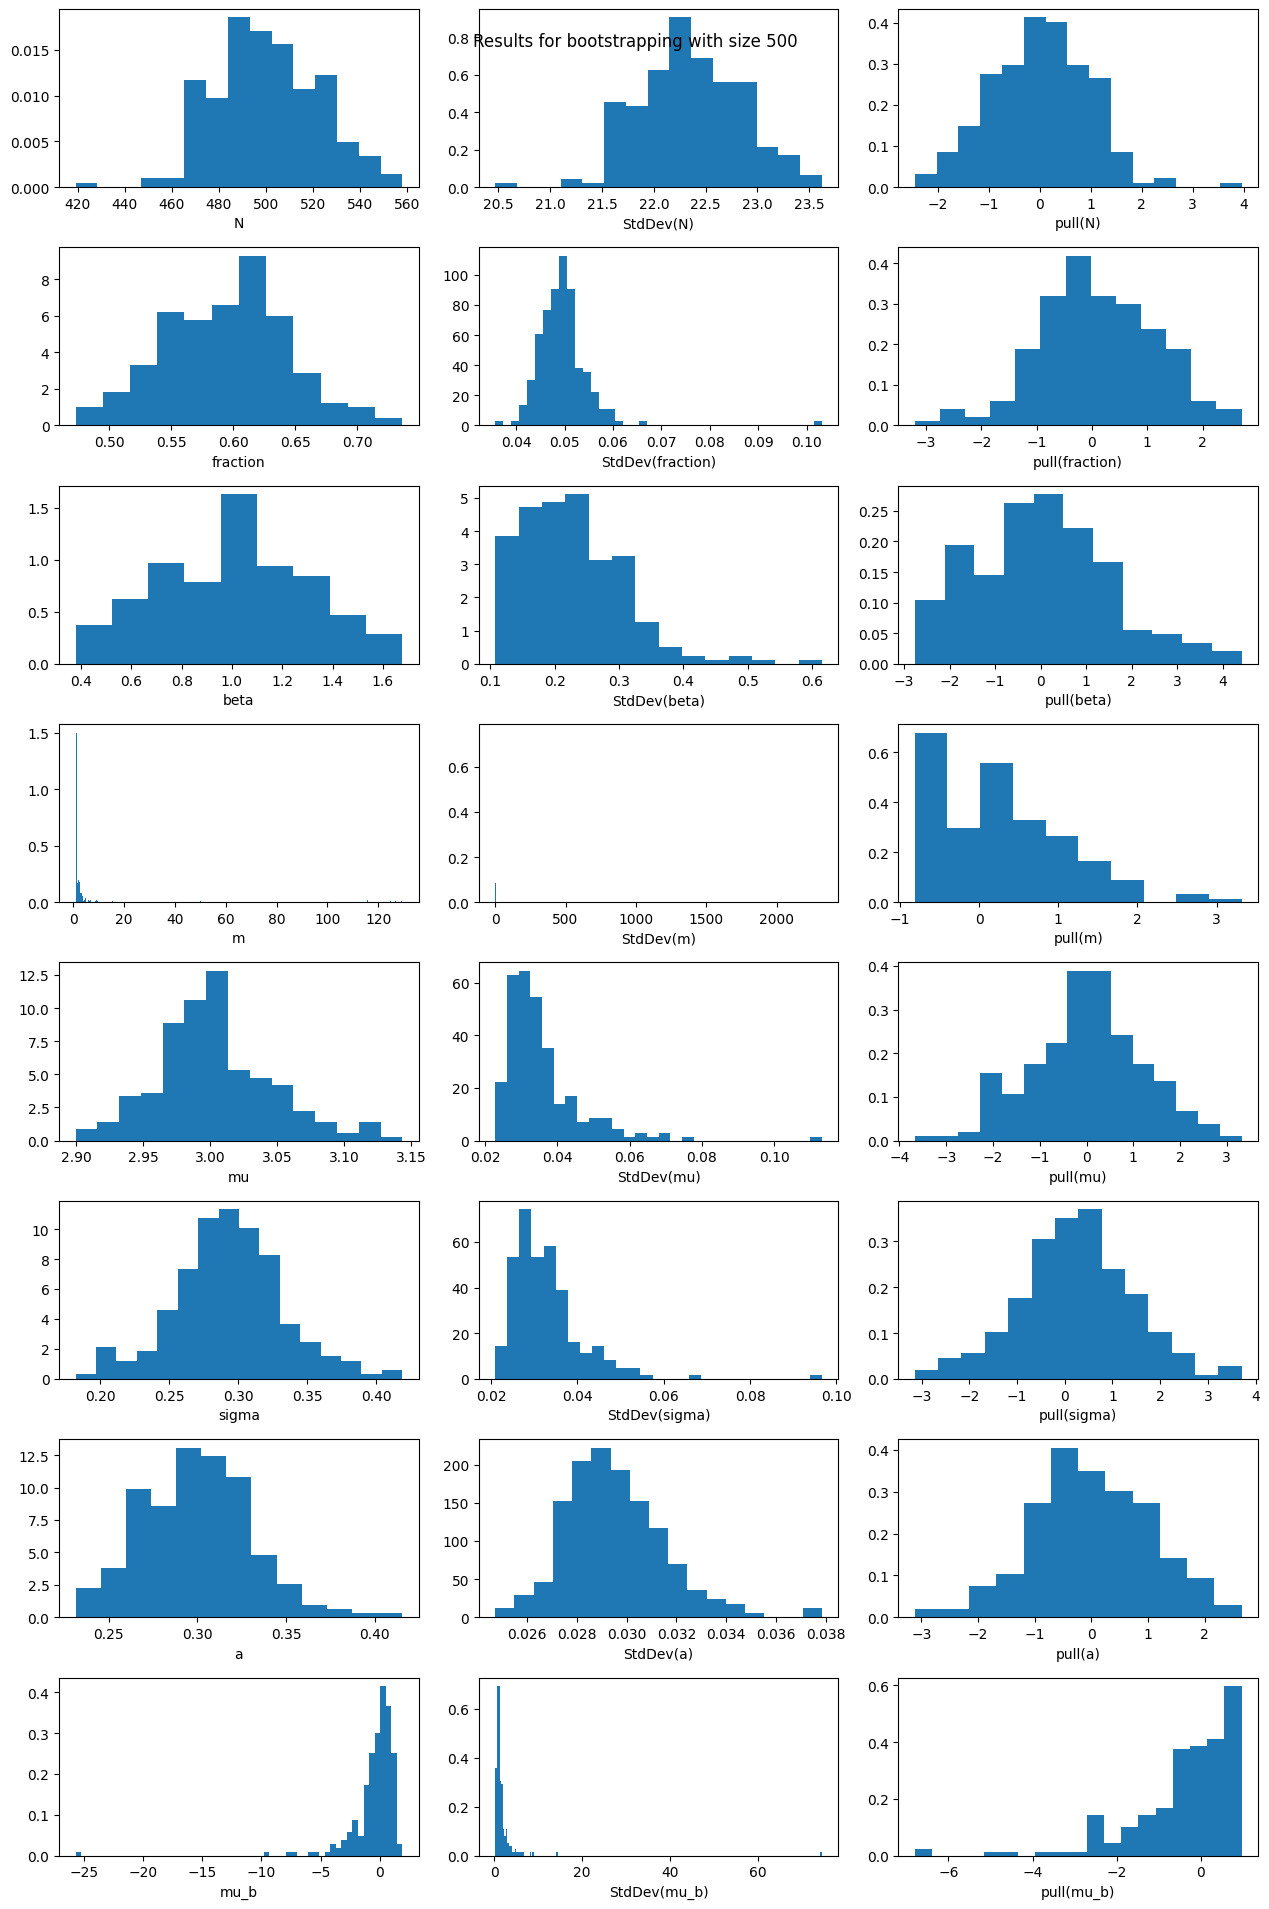

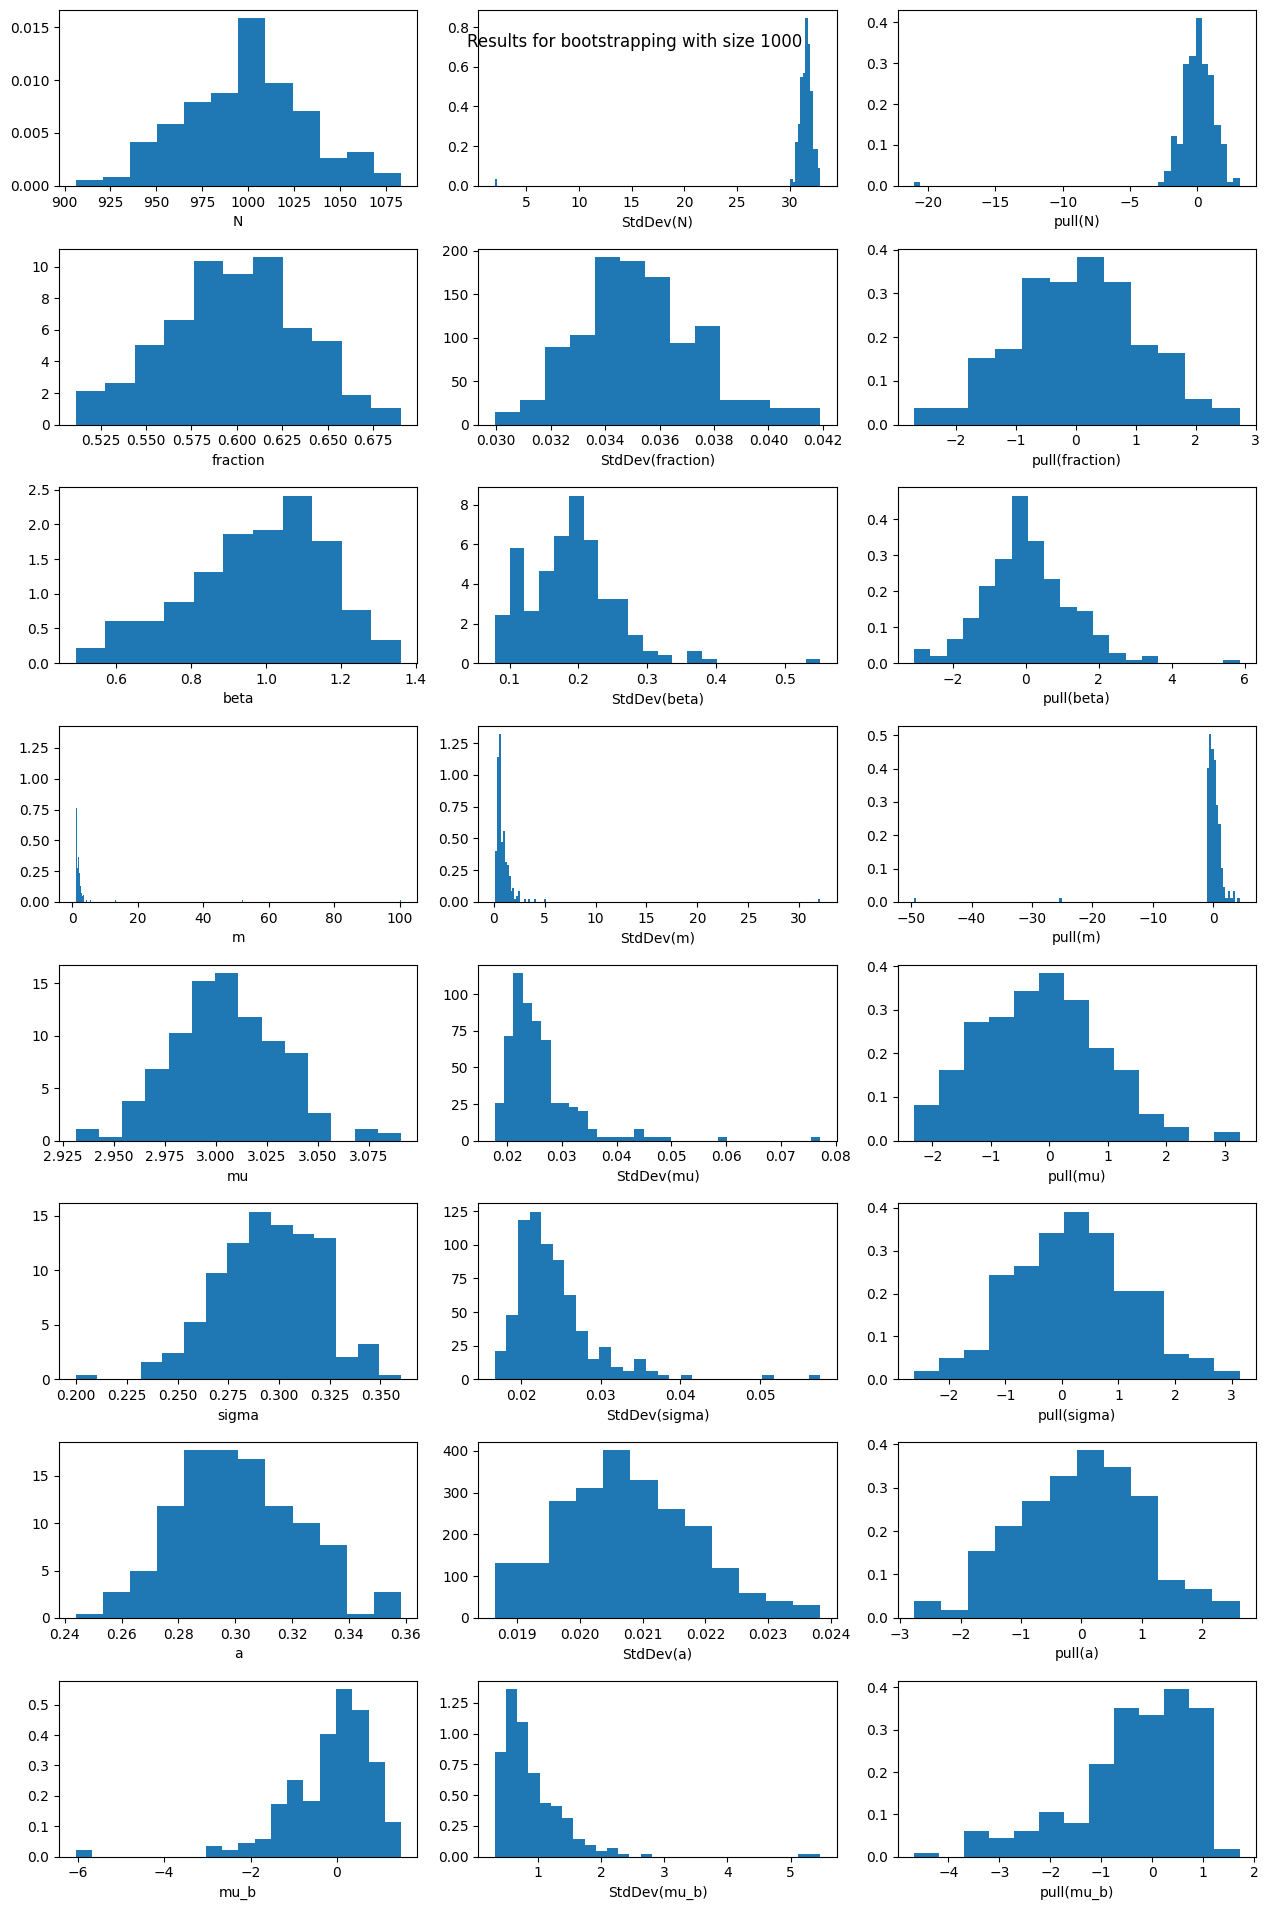

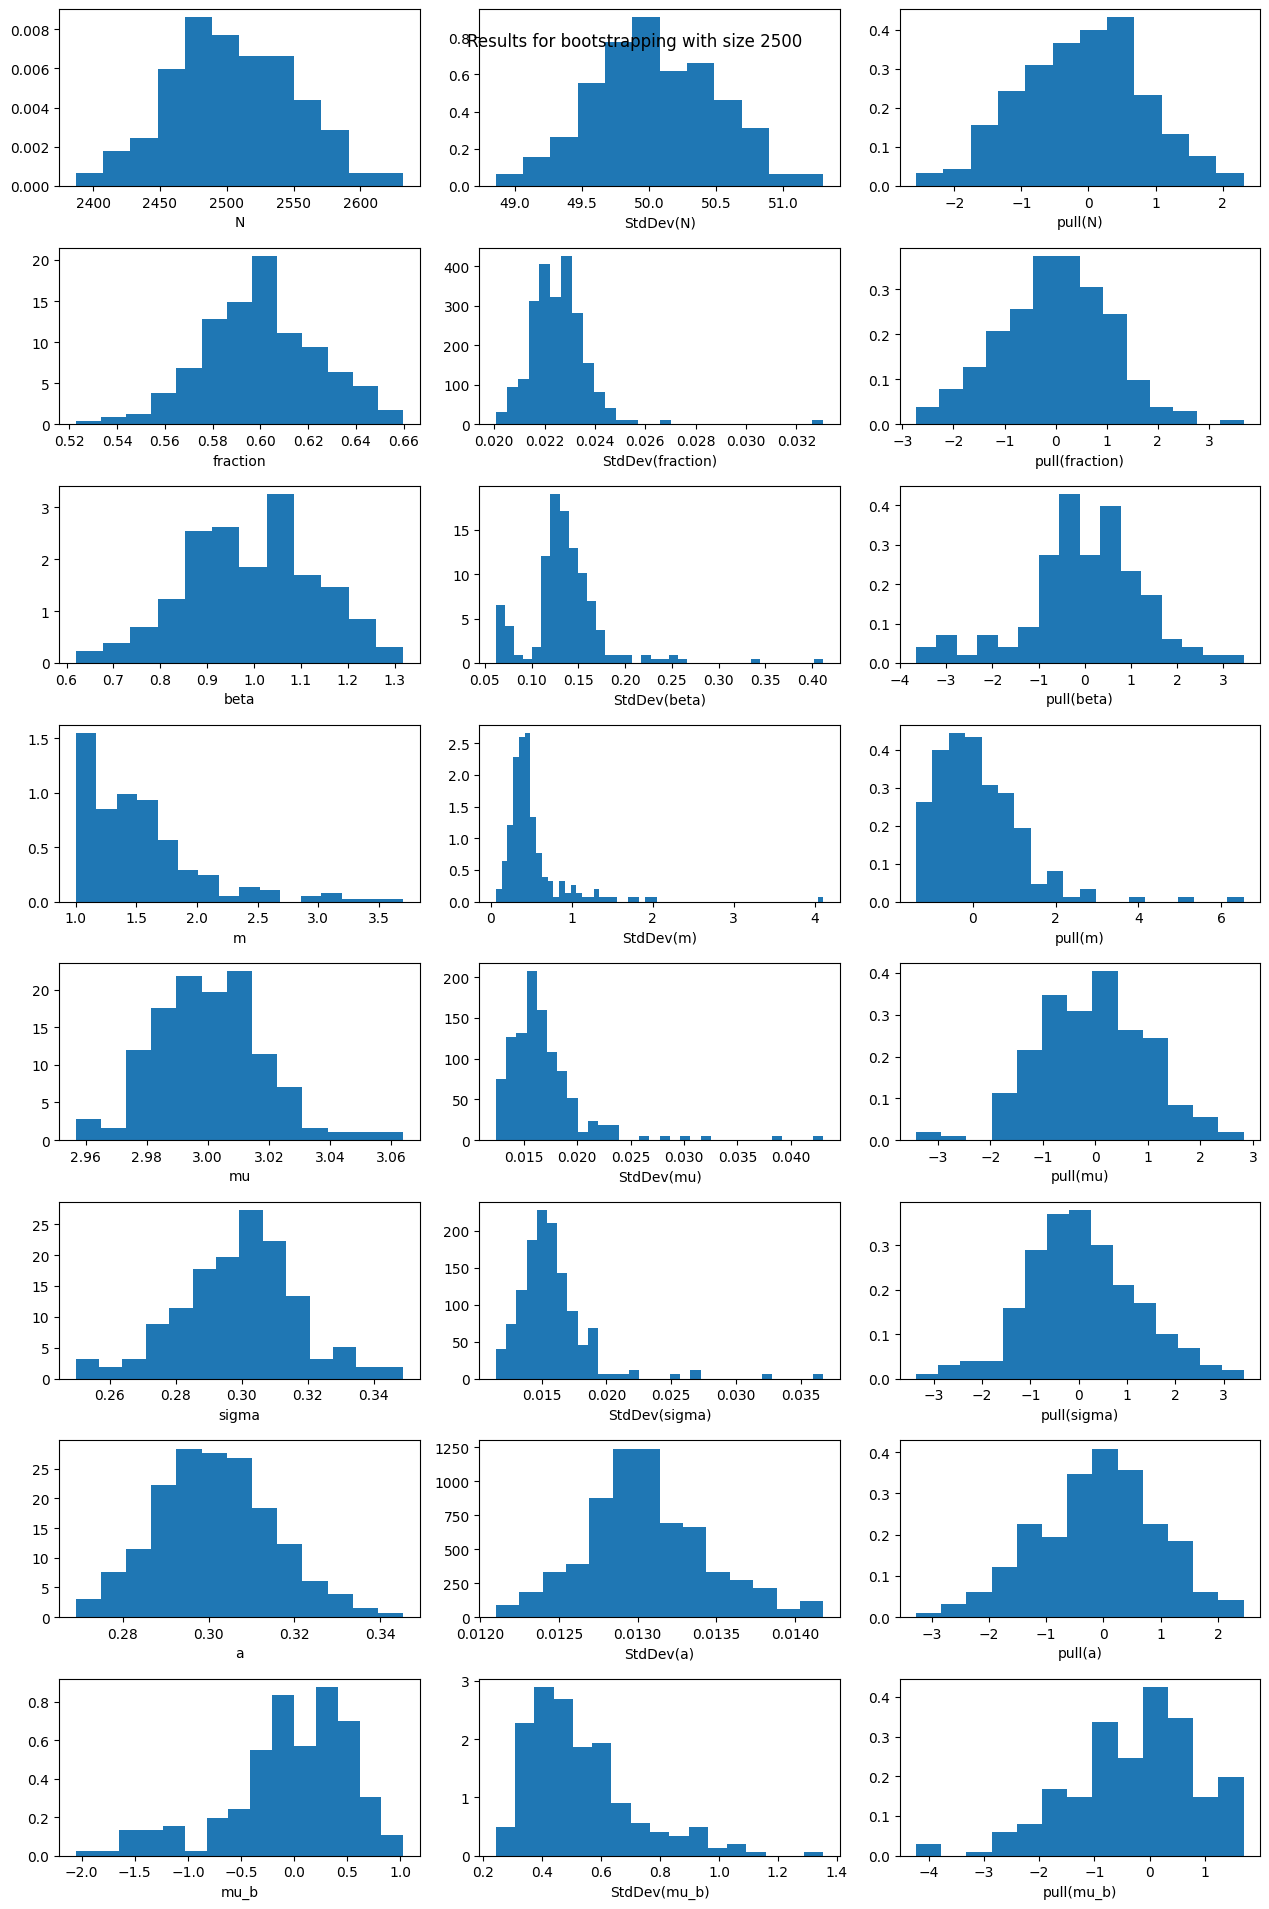

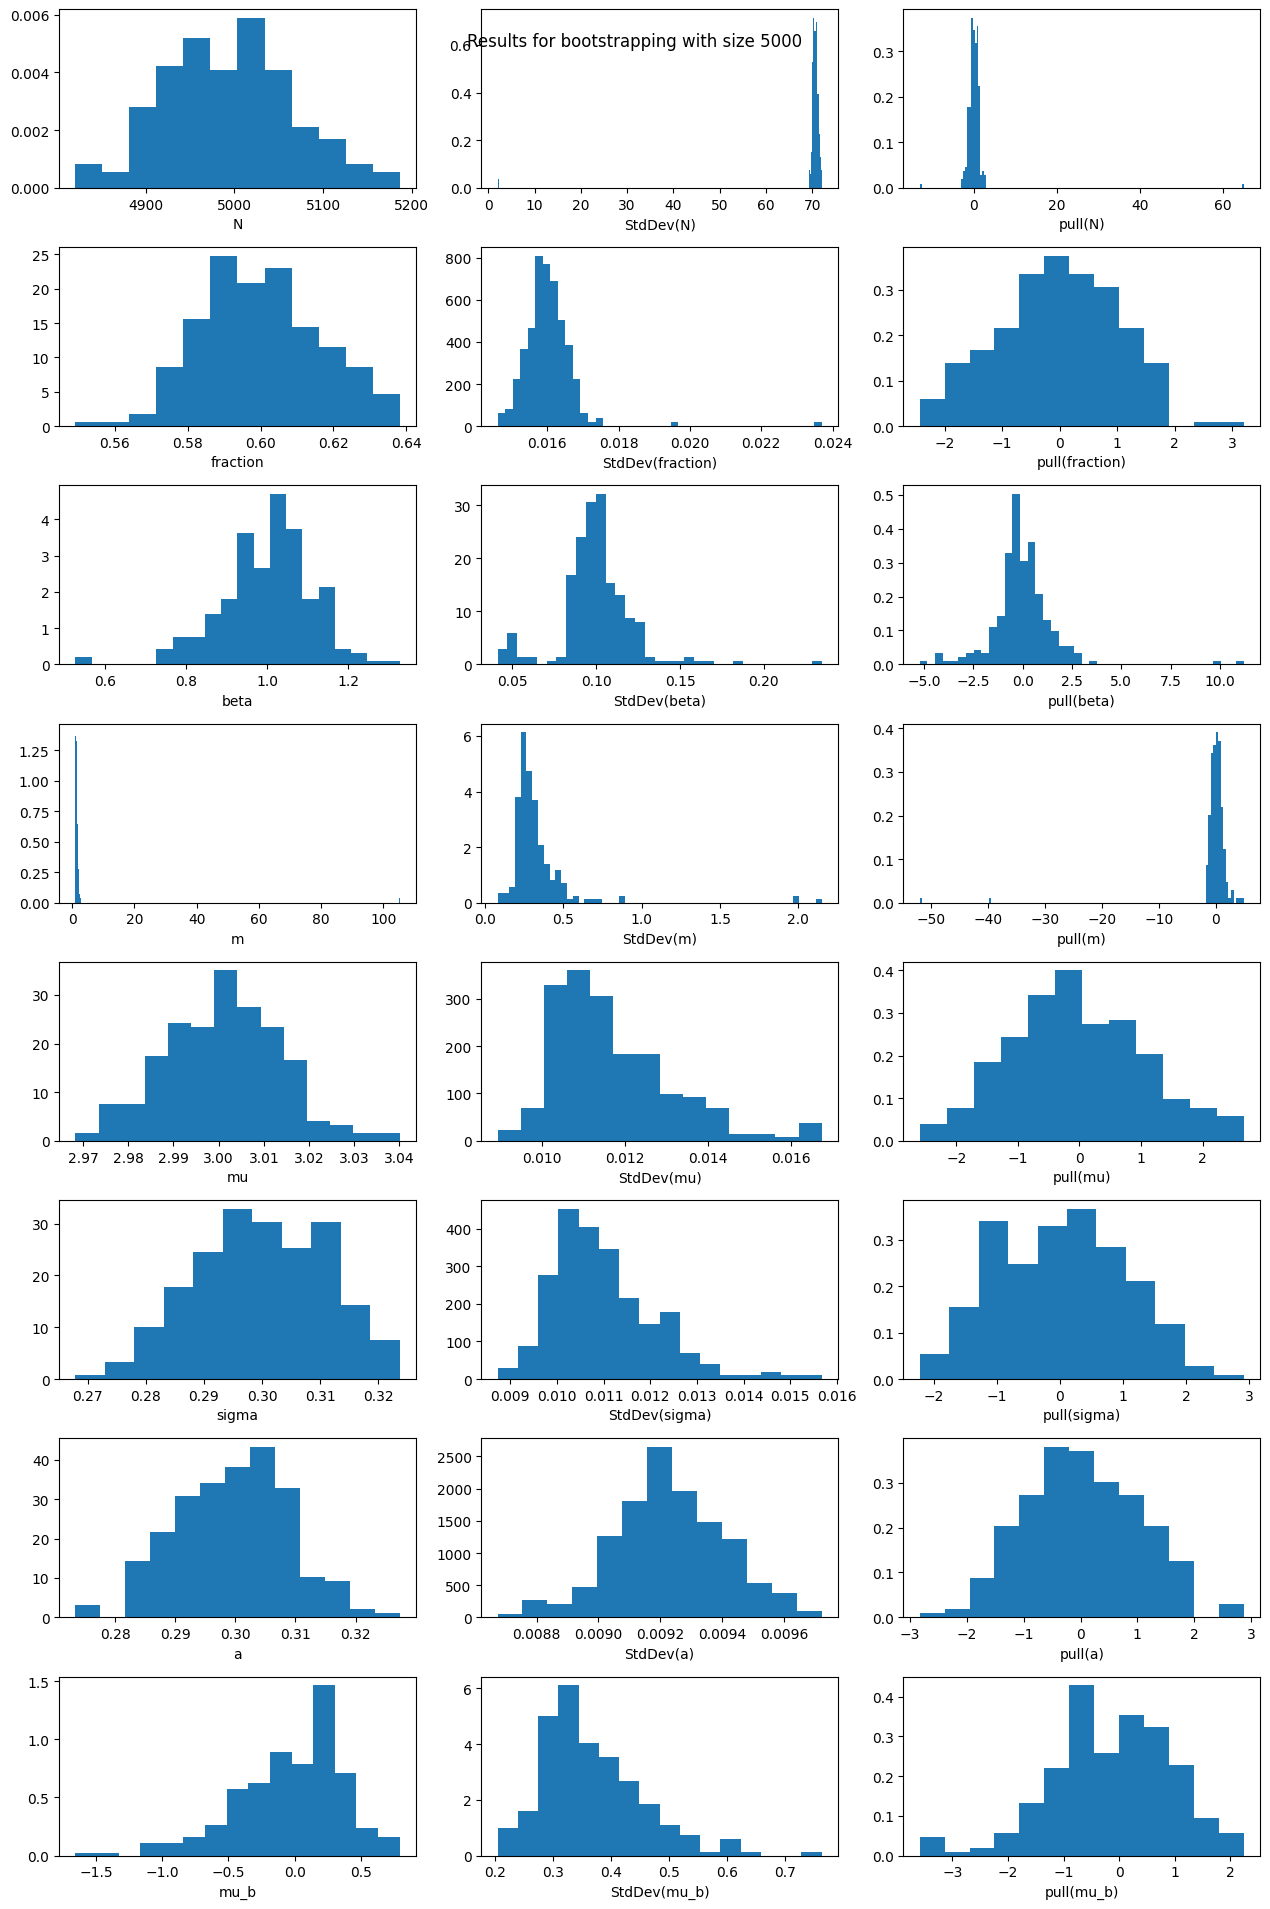

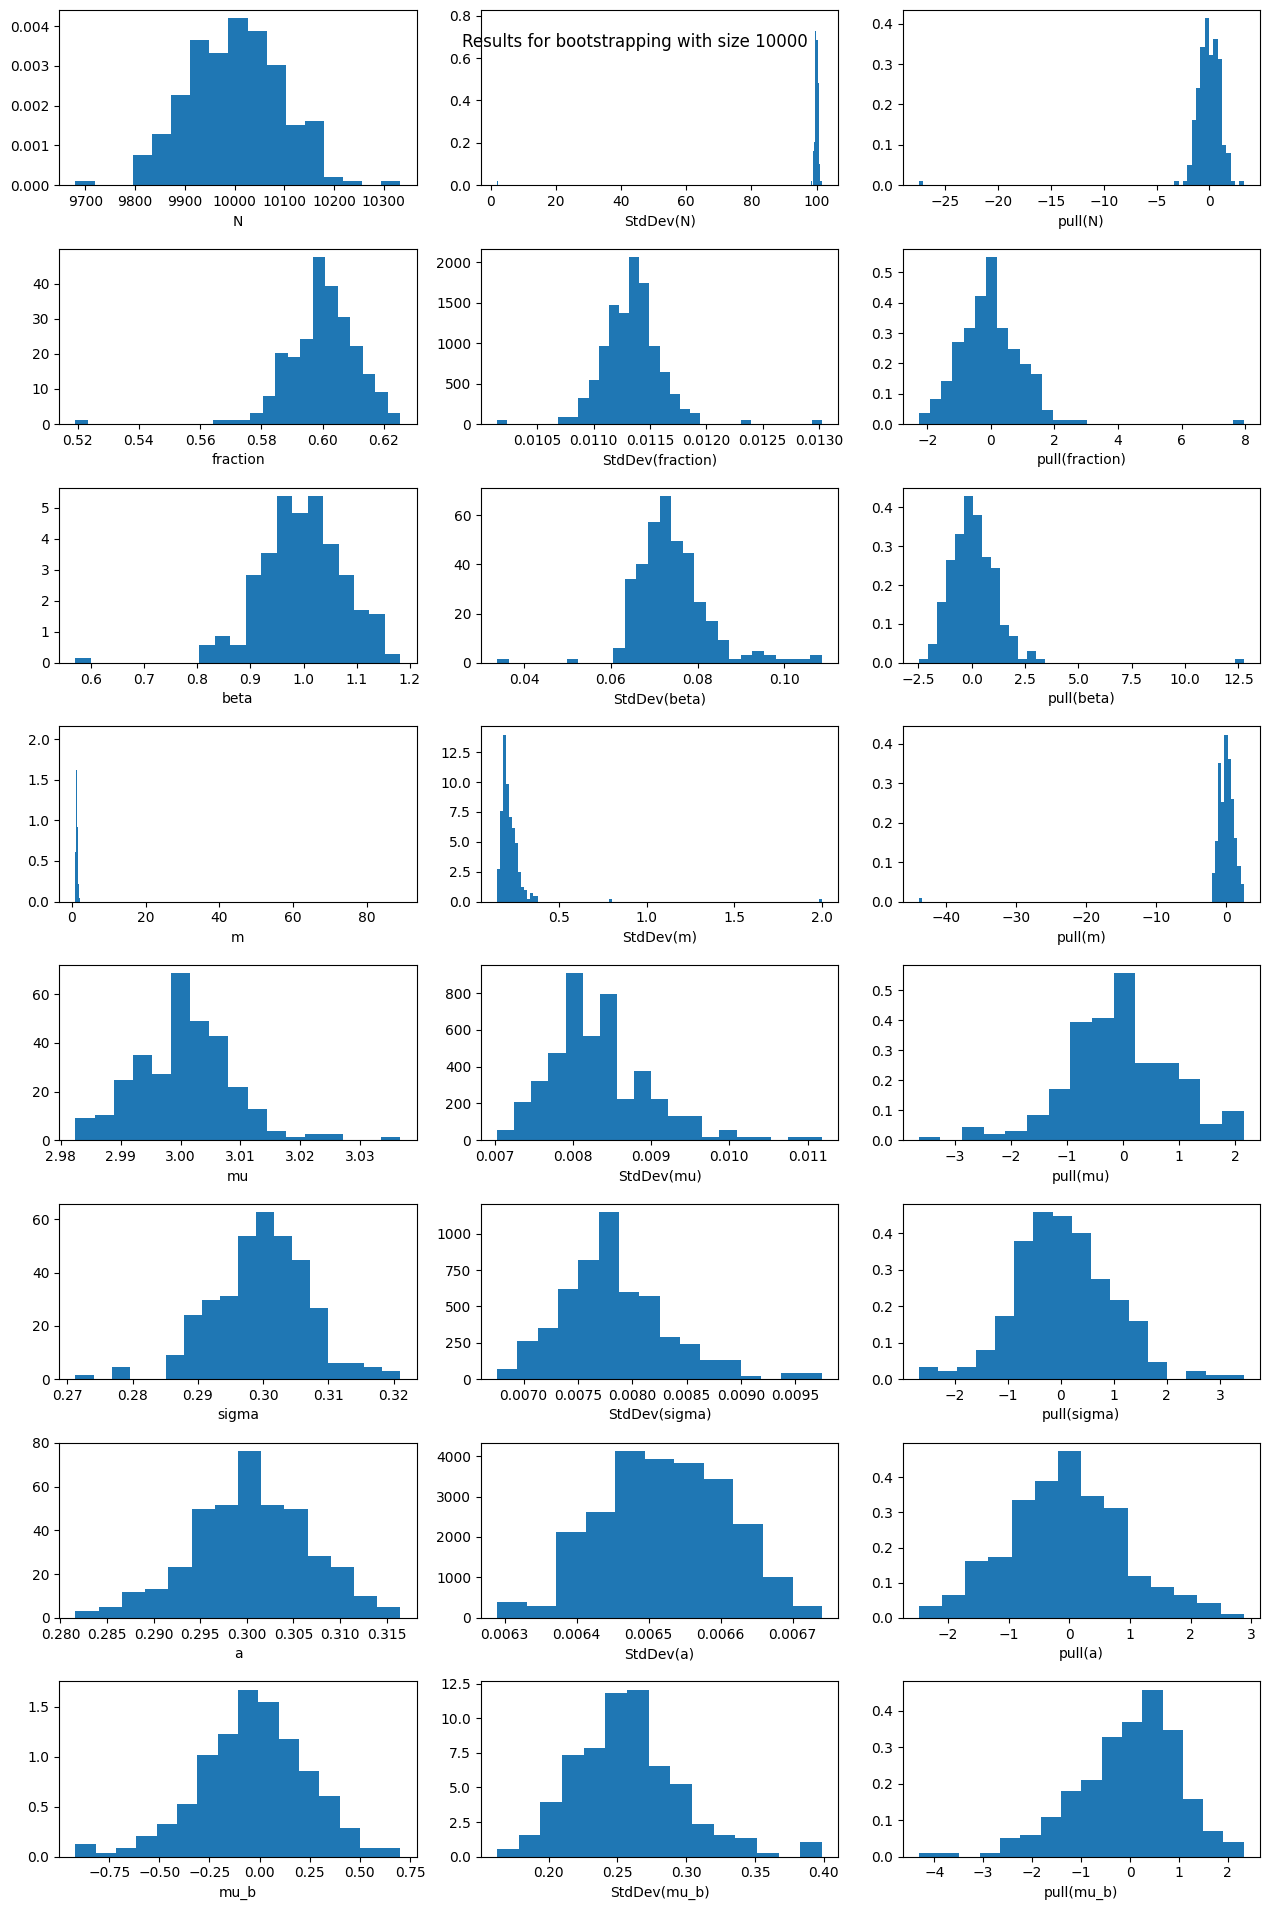

In [26]:
warnings.filterwarnings("ignore", category=RuntimeWarning)


# sample_sizes we will be generating
sample_sizes = [500, 1000, 2500, 5000, 10000]
ntoys = 250 # ensemble size
params = { "fraction": fraction, "beta": beta, "m": m, "mu": mu, "sigma": sigma, "x_left": x_left,
    "x_right": x_right, "a": a, "y_left": y_left, "y_right": y_right, "mu_b": mu_b, "sigma_b": sigma_b}

# parameters array
size = 500
params_arr = np.array([size, fraction, beta, m, mu, sigma, a, mu_b, sigma_b])

# dictionaries to store toy samples and estimated parameters,errors
storage_samples = {}
storage_params = {}

for size in sample_sizes:
    toys = [np.array(accept_reject_2d(func=func, xrange=xrange, yrange=yrange, size=np.random.poisson(size), params=params, fmax=fmax)) for i in range(ntoys)] # build array of toys
    storage_samples[size] = toys #storing for part (f)

    # adjust params_arr to have the size as the first element, reinitialize storage
    params_arr[0] = size
    estimates = []
    errors = []
    pulls = []  
    
    for toy in toys:
        alt_mi = btstrp_fit(toy, size) #get estimates and errors
        if alt_mi.valid and alt_mi.accurate: #check convergence happens and if hesse error estimates are valid
            estimates.append(np.array(alt_mi.values))
            errors.append(np.array(alt_mi.errors))
            pulls.append((params_arr-alt_mi.values)/alt_mi.errors)

    # turning into arrays for plotting
    estimates = np.array(estimates)
    errors = np.array(errors)
    pulls = np.array(pulls)

    # calling the function to plot
    fig = plotting(estimates, errors, pulls)
    fig.suptitle(f'Results for bootstrapping with size {size}')
    plt.show()

    # storing values, errors and pulls for part (f)
    storage_params[size] = {'estimates': estimates, 'errors': errors, 'pulls': pulls}

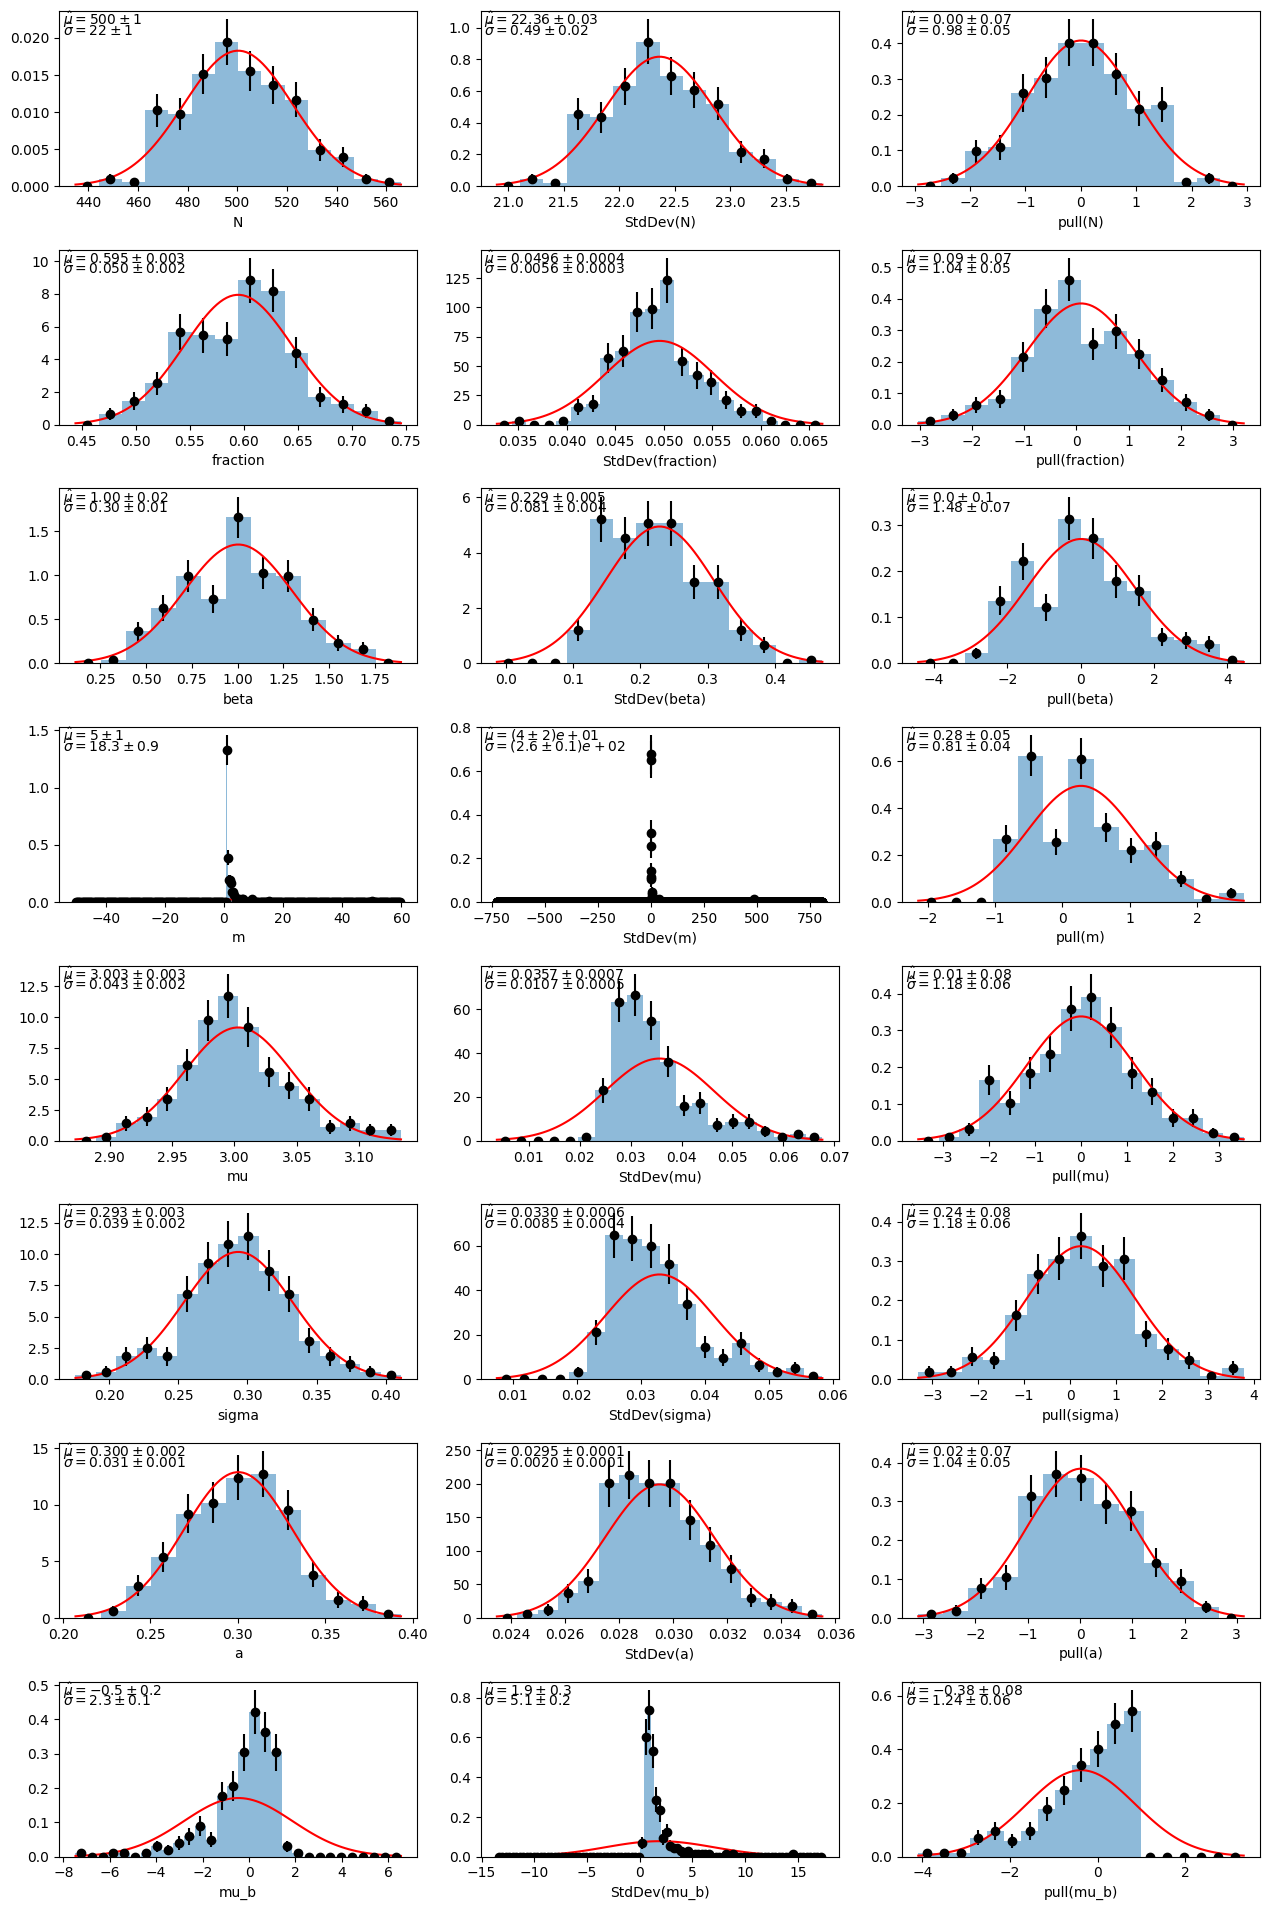

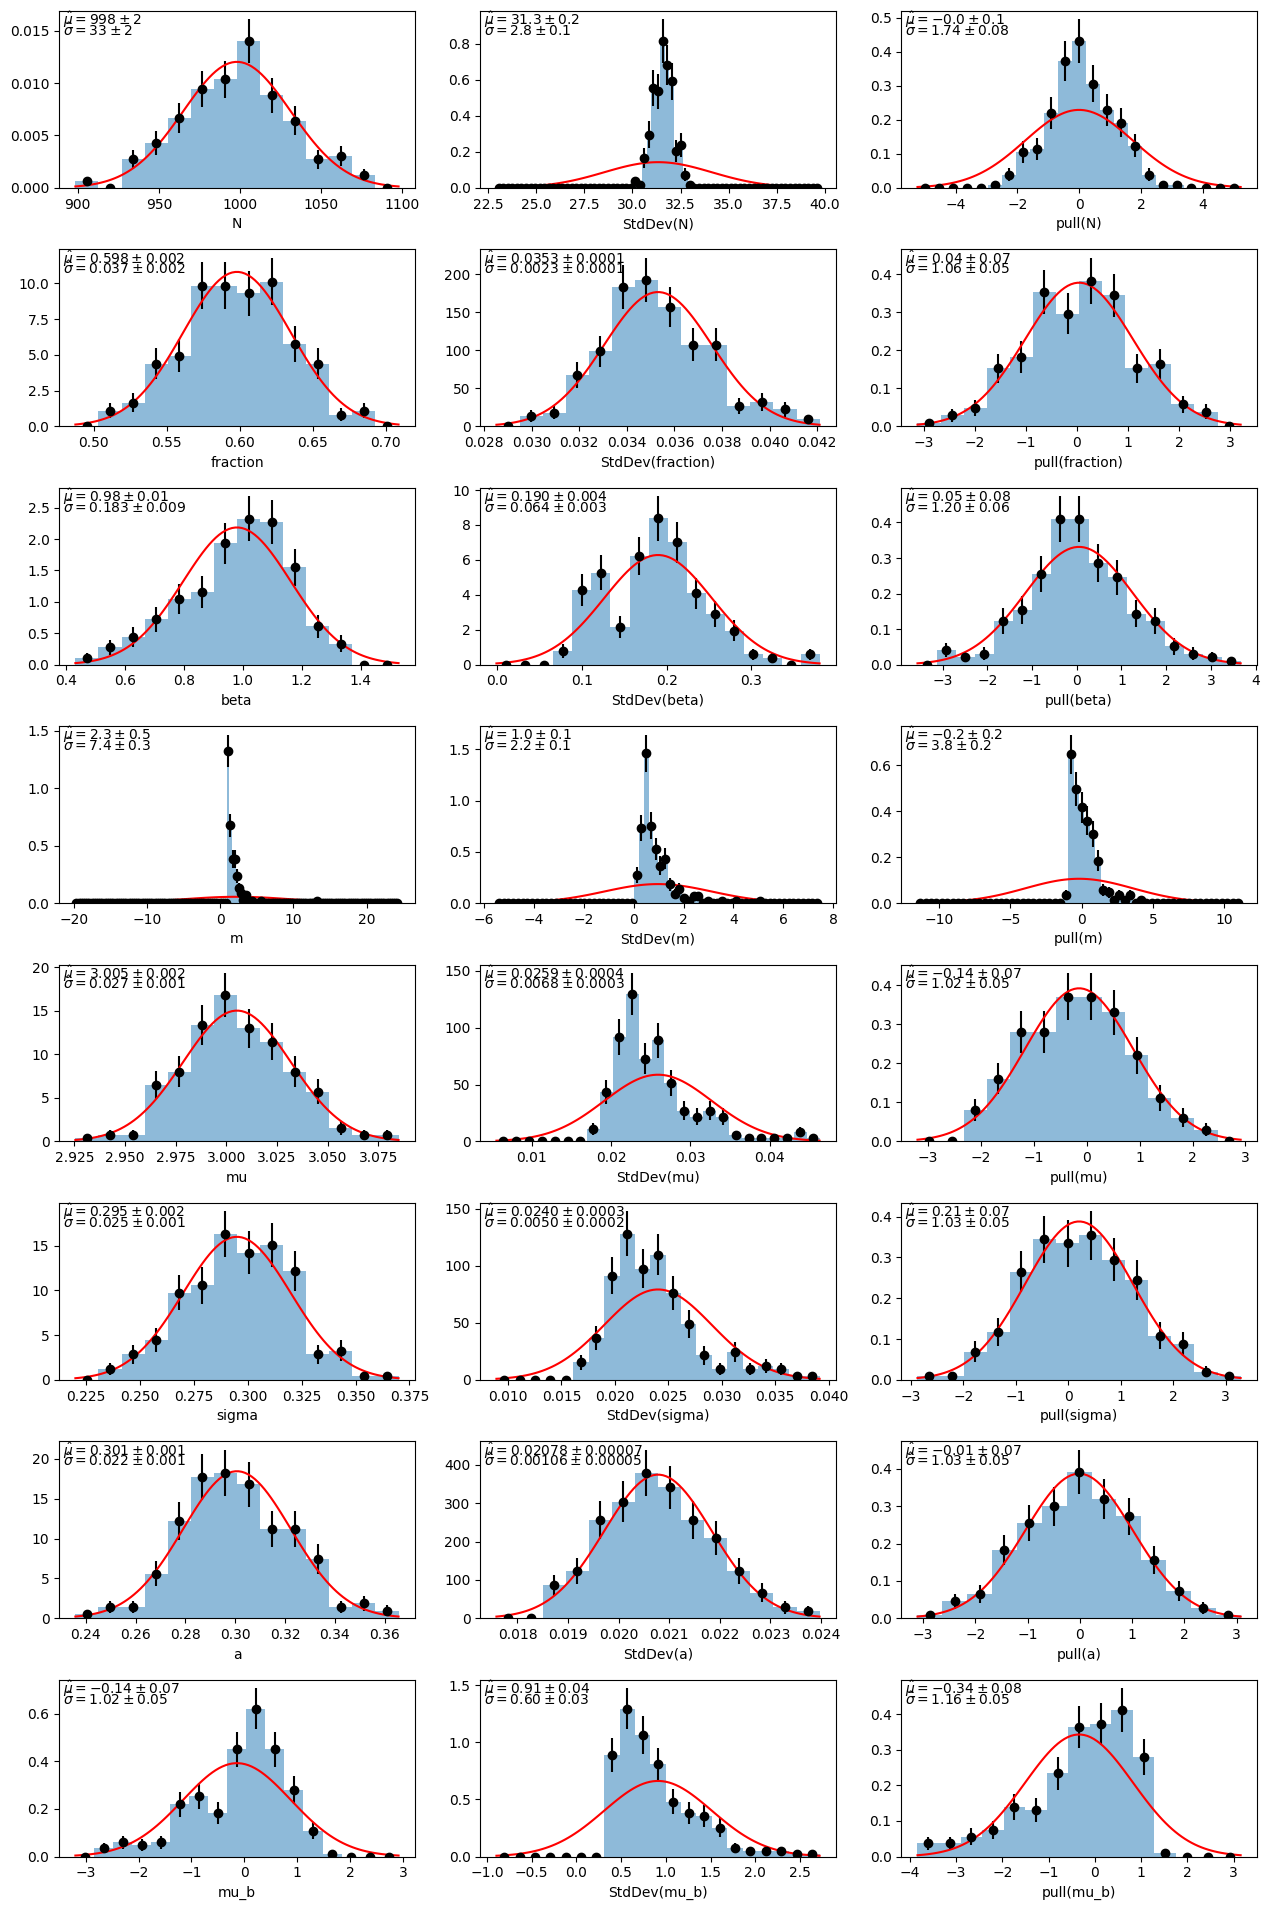

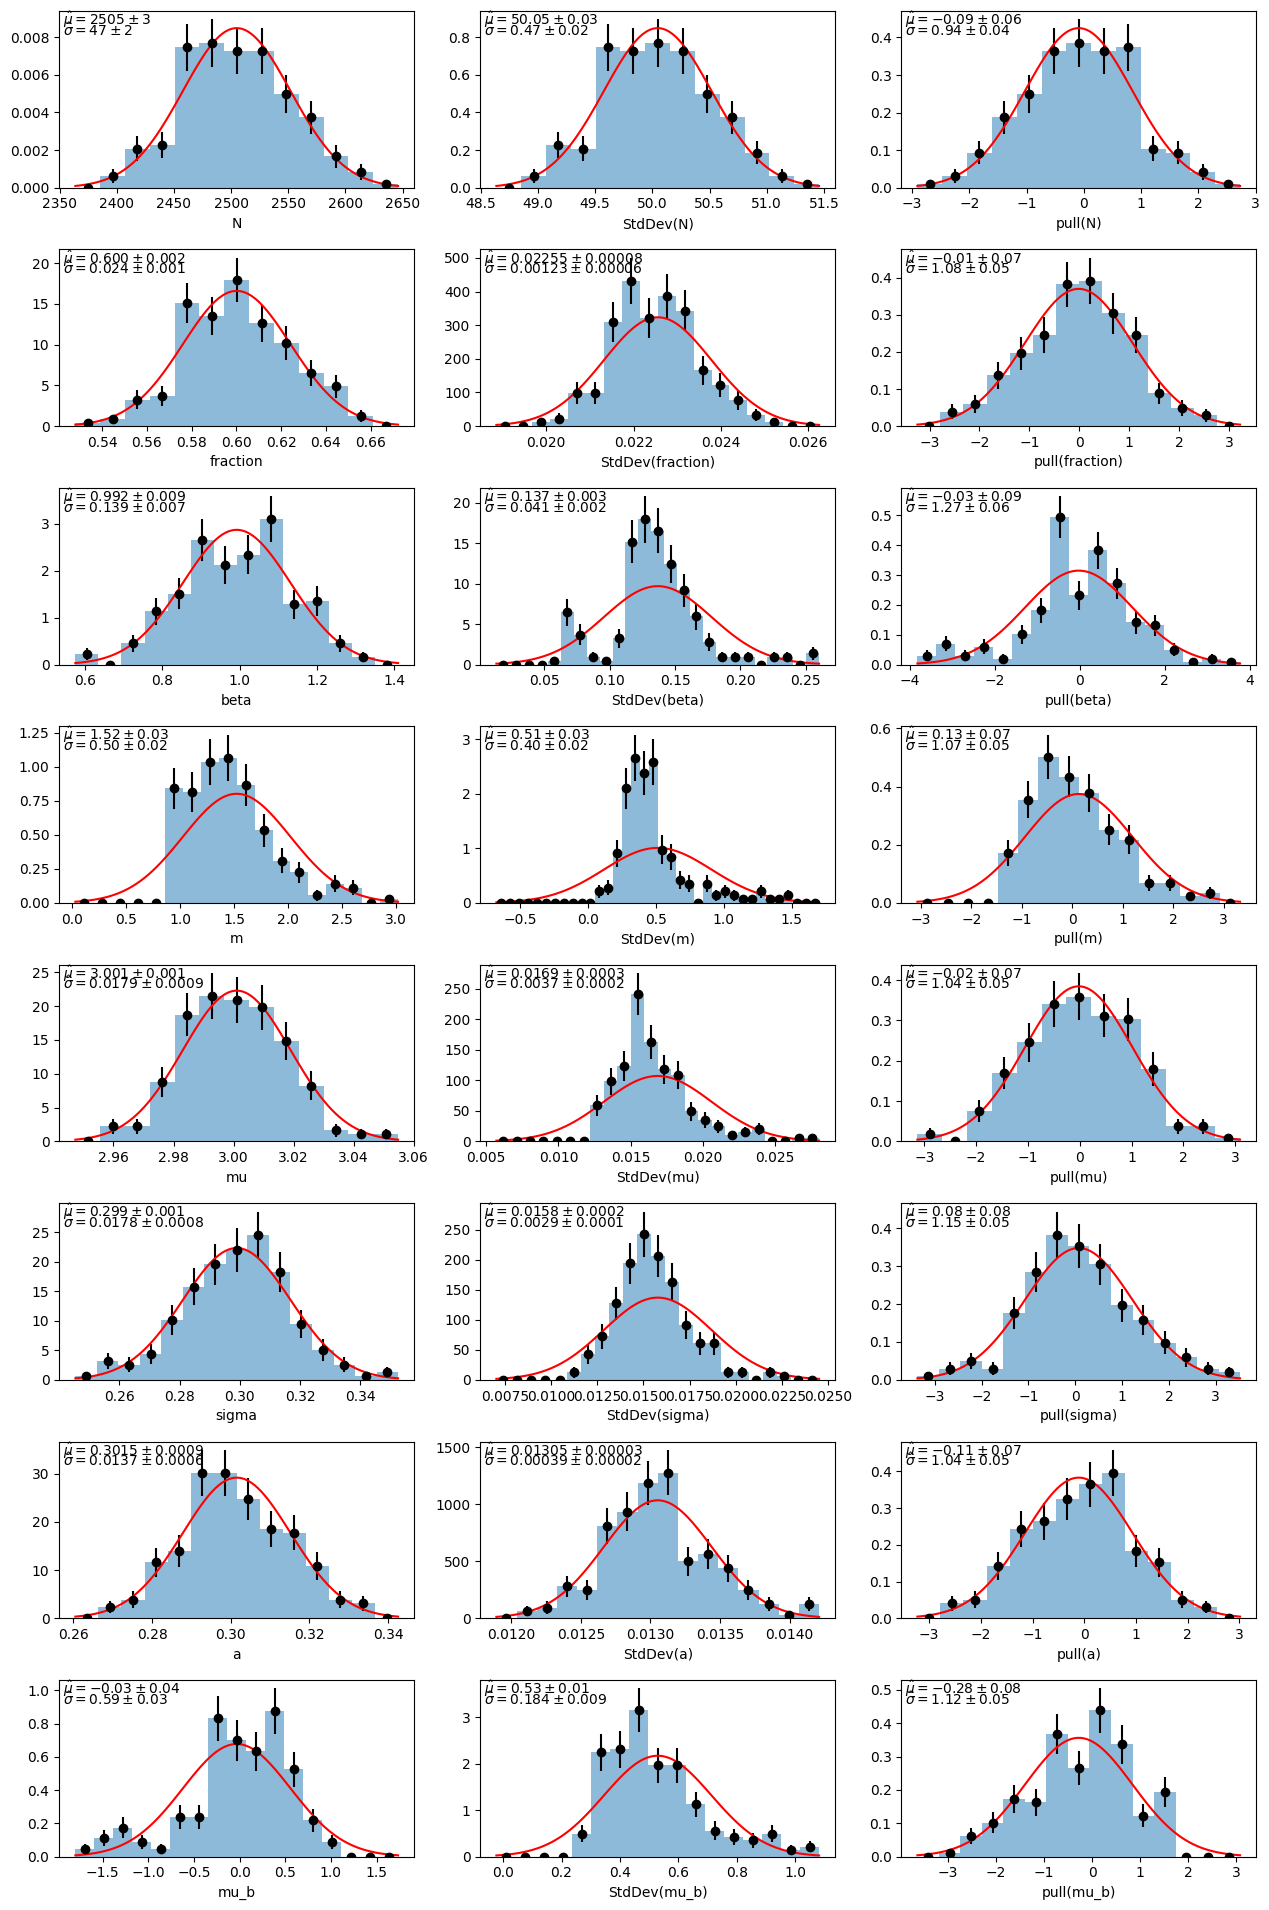

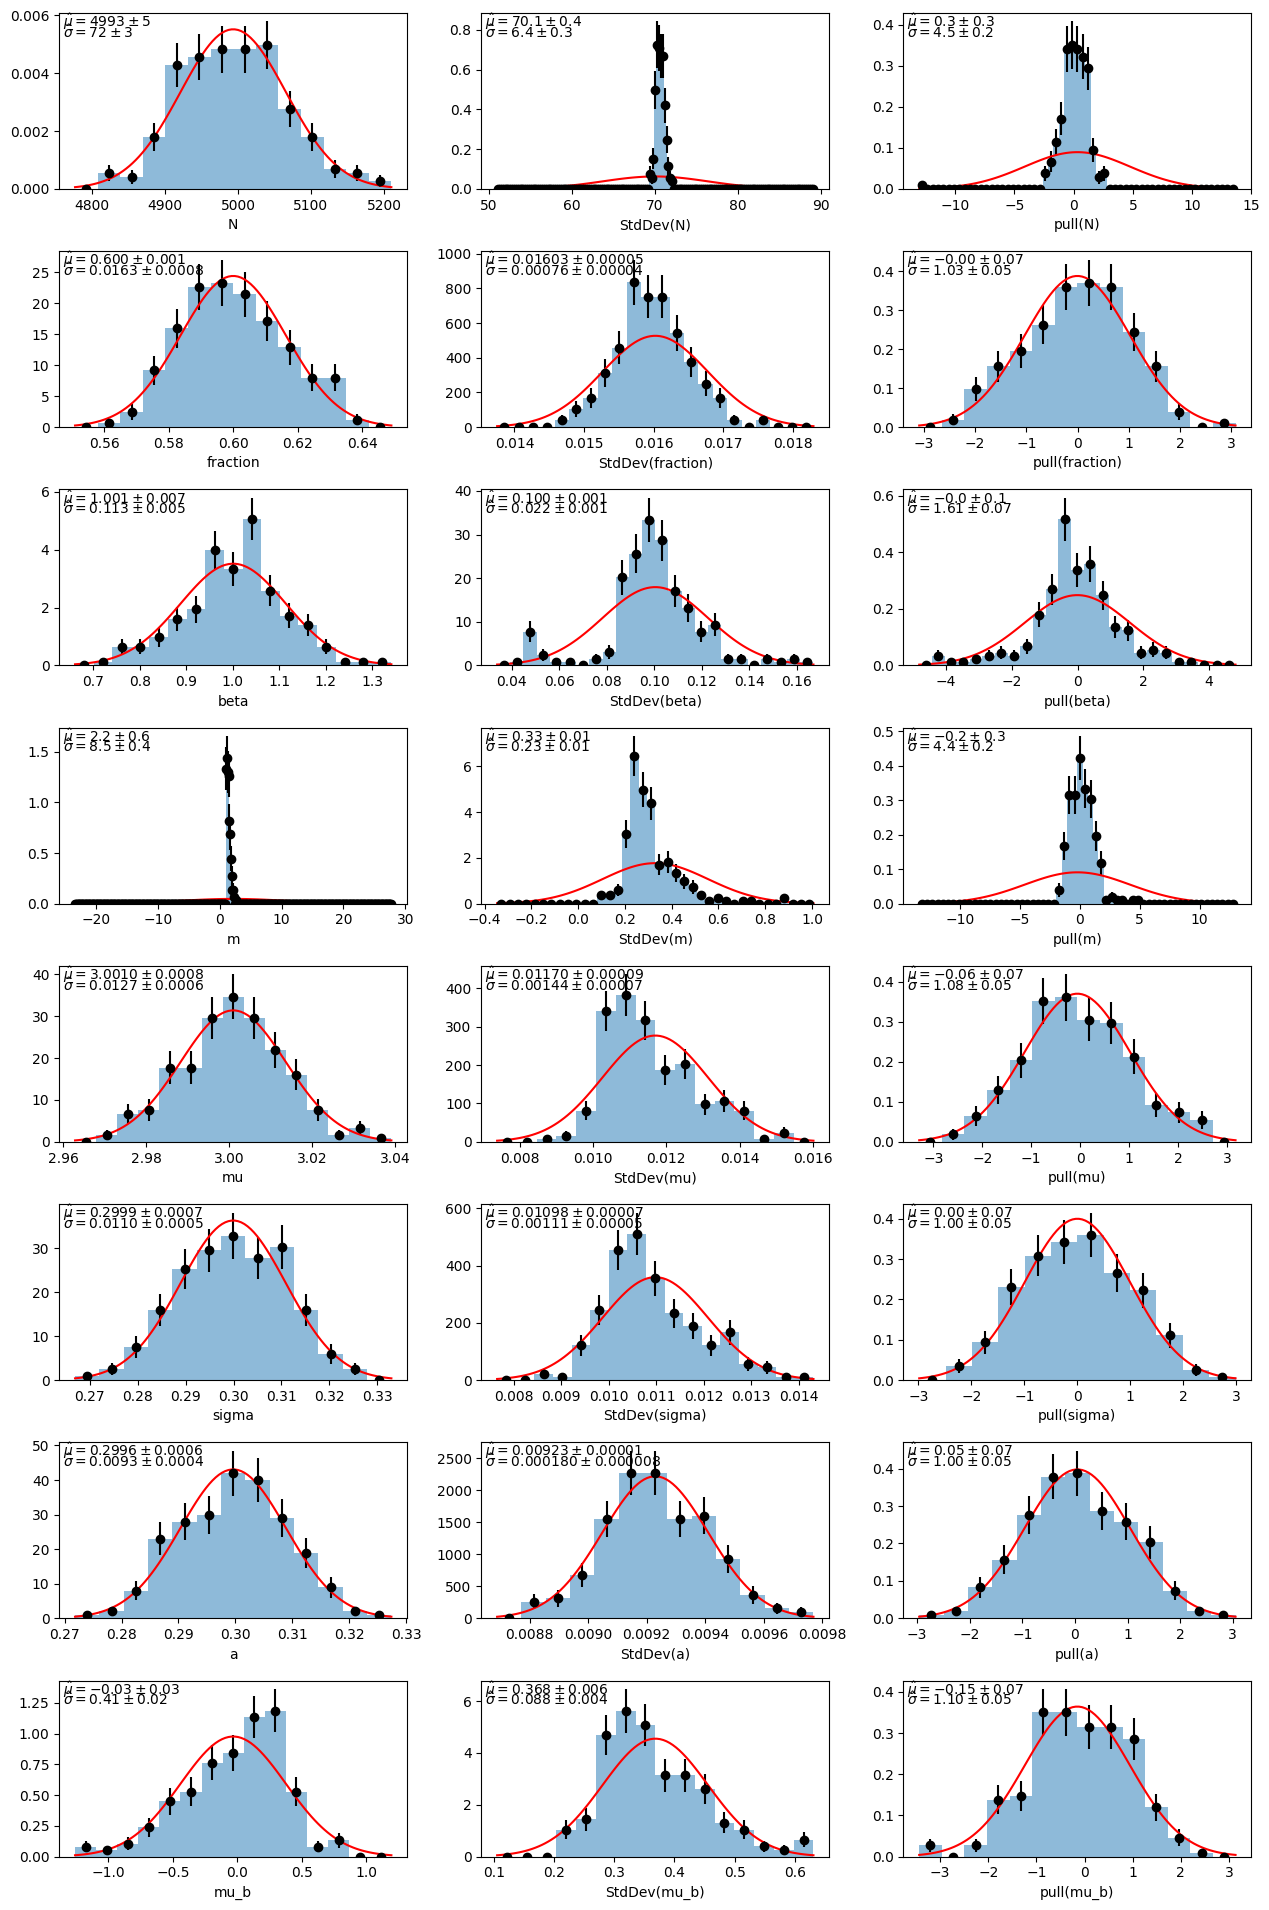

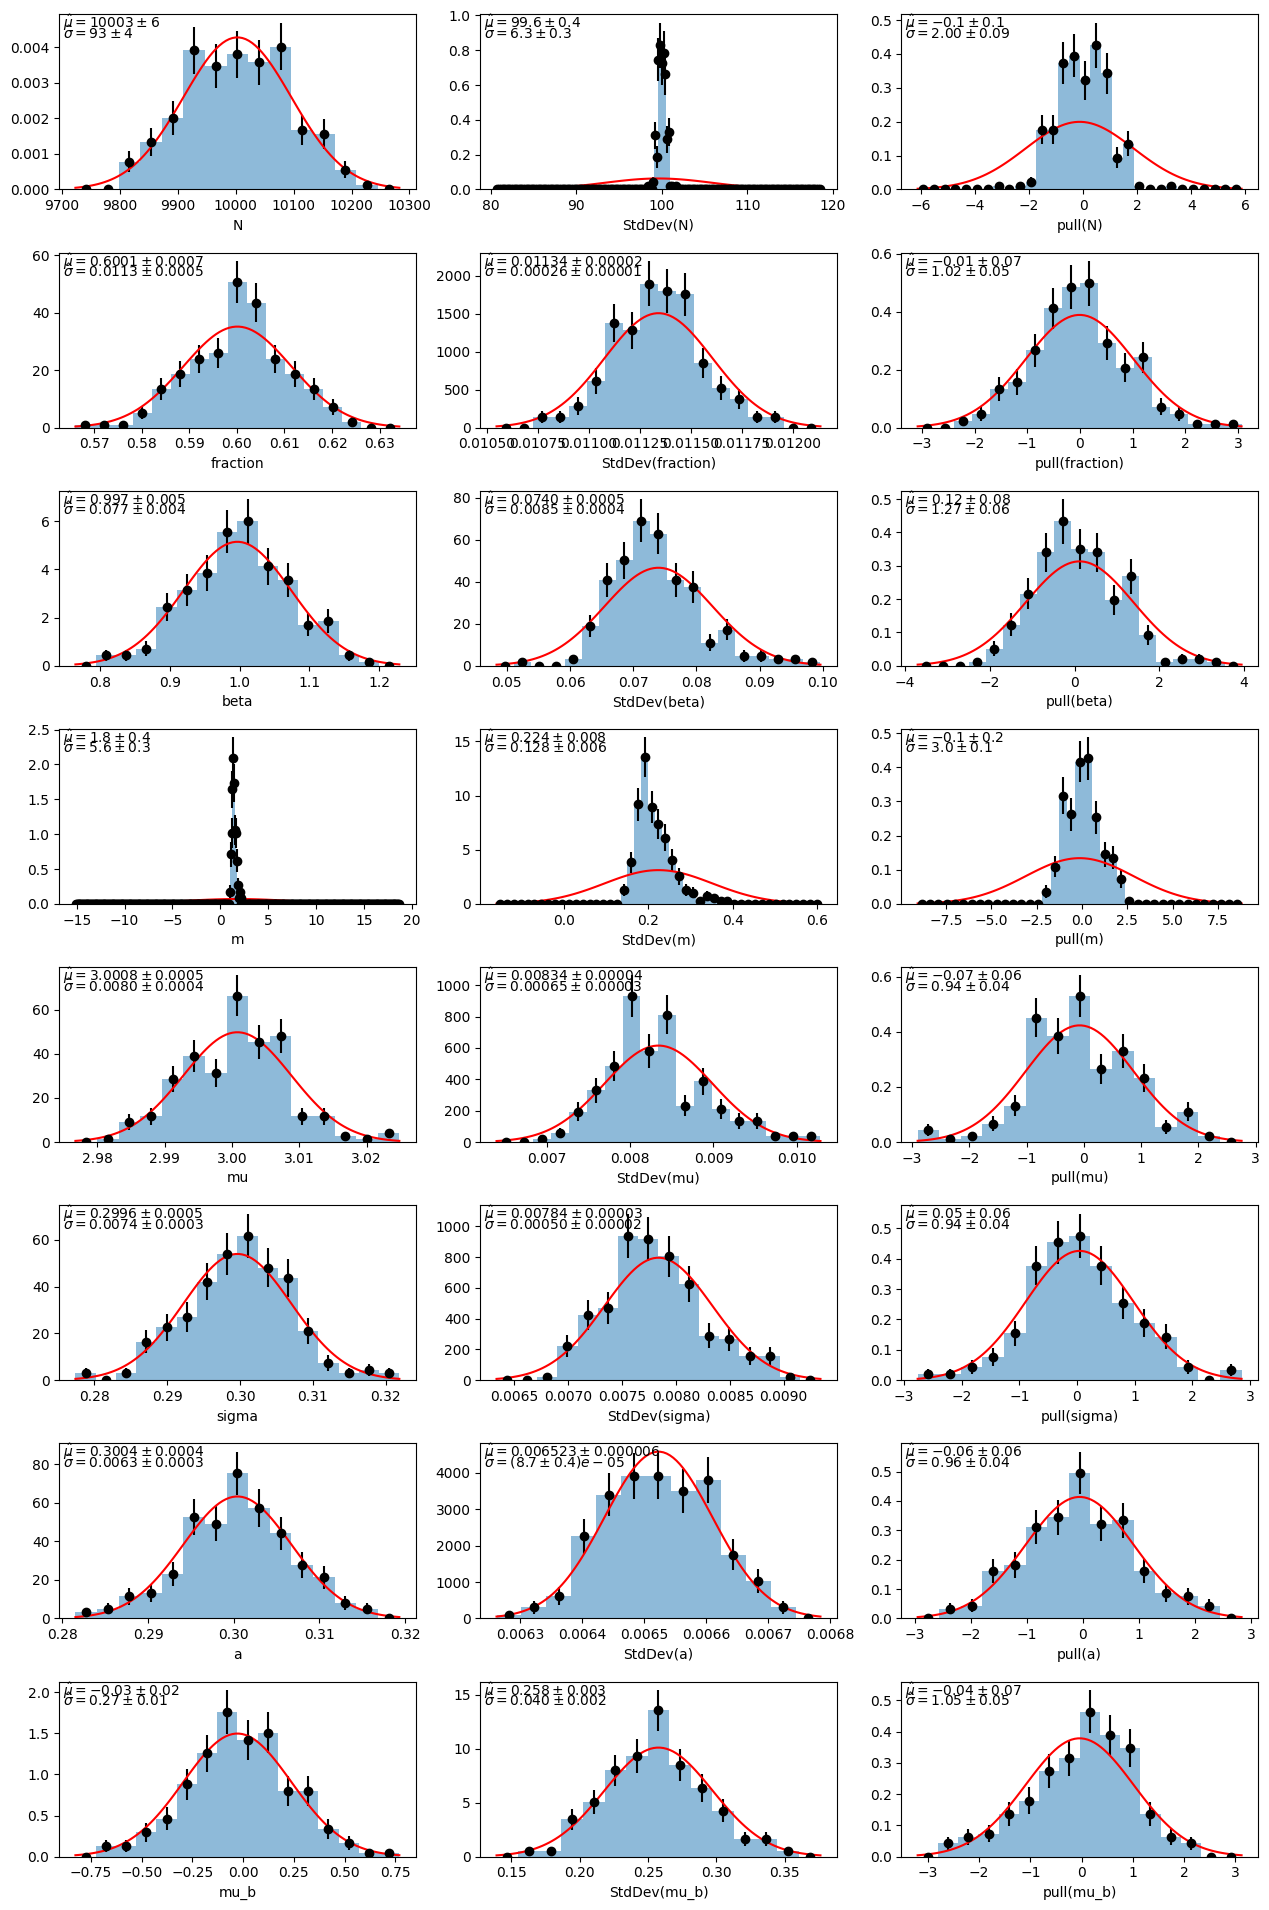

In [27]:
# we have data stored, let's figure out better plotting, using Professor Kenzie's format
from tqdm import tqdm
import uncertainties as uncert

for size in sample_sizes:
    estimates = storage_params[size]['estimates']
    errors = storage_params[size]['errors']
    pulls = storage_params[size]['pulls']

    fig, axes = plt.subplots(8, 3, figsize=(12.8, 19.2))
    for(i, par), ax in zip(enumerate(['N', 'fraction', 'beta', 'm', 'mu', 'sigma', 'a', 'mu_b', 'sigma_b']), axes):
        
        ax = axes[i,0]
        plot(estimates[:,i], ax)
        ax.set_xlabel(par)

        ax = axes[i,1]
        plot(errors[:,i], ax)
        ax.set_xlabel(f"StdDev({par})")

        ax = axes[i,2]
        plot(pulls[:,i], ax)
        ax.set_xlabel(f"pull({par})")

        plt.tight_layout()

#### Make ensembles 500 each, to be left with at least 250 valid & accurate ones

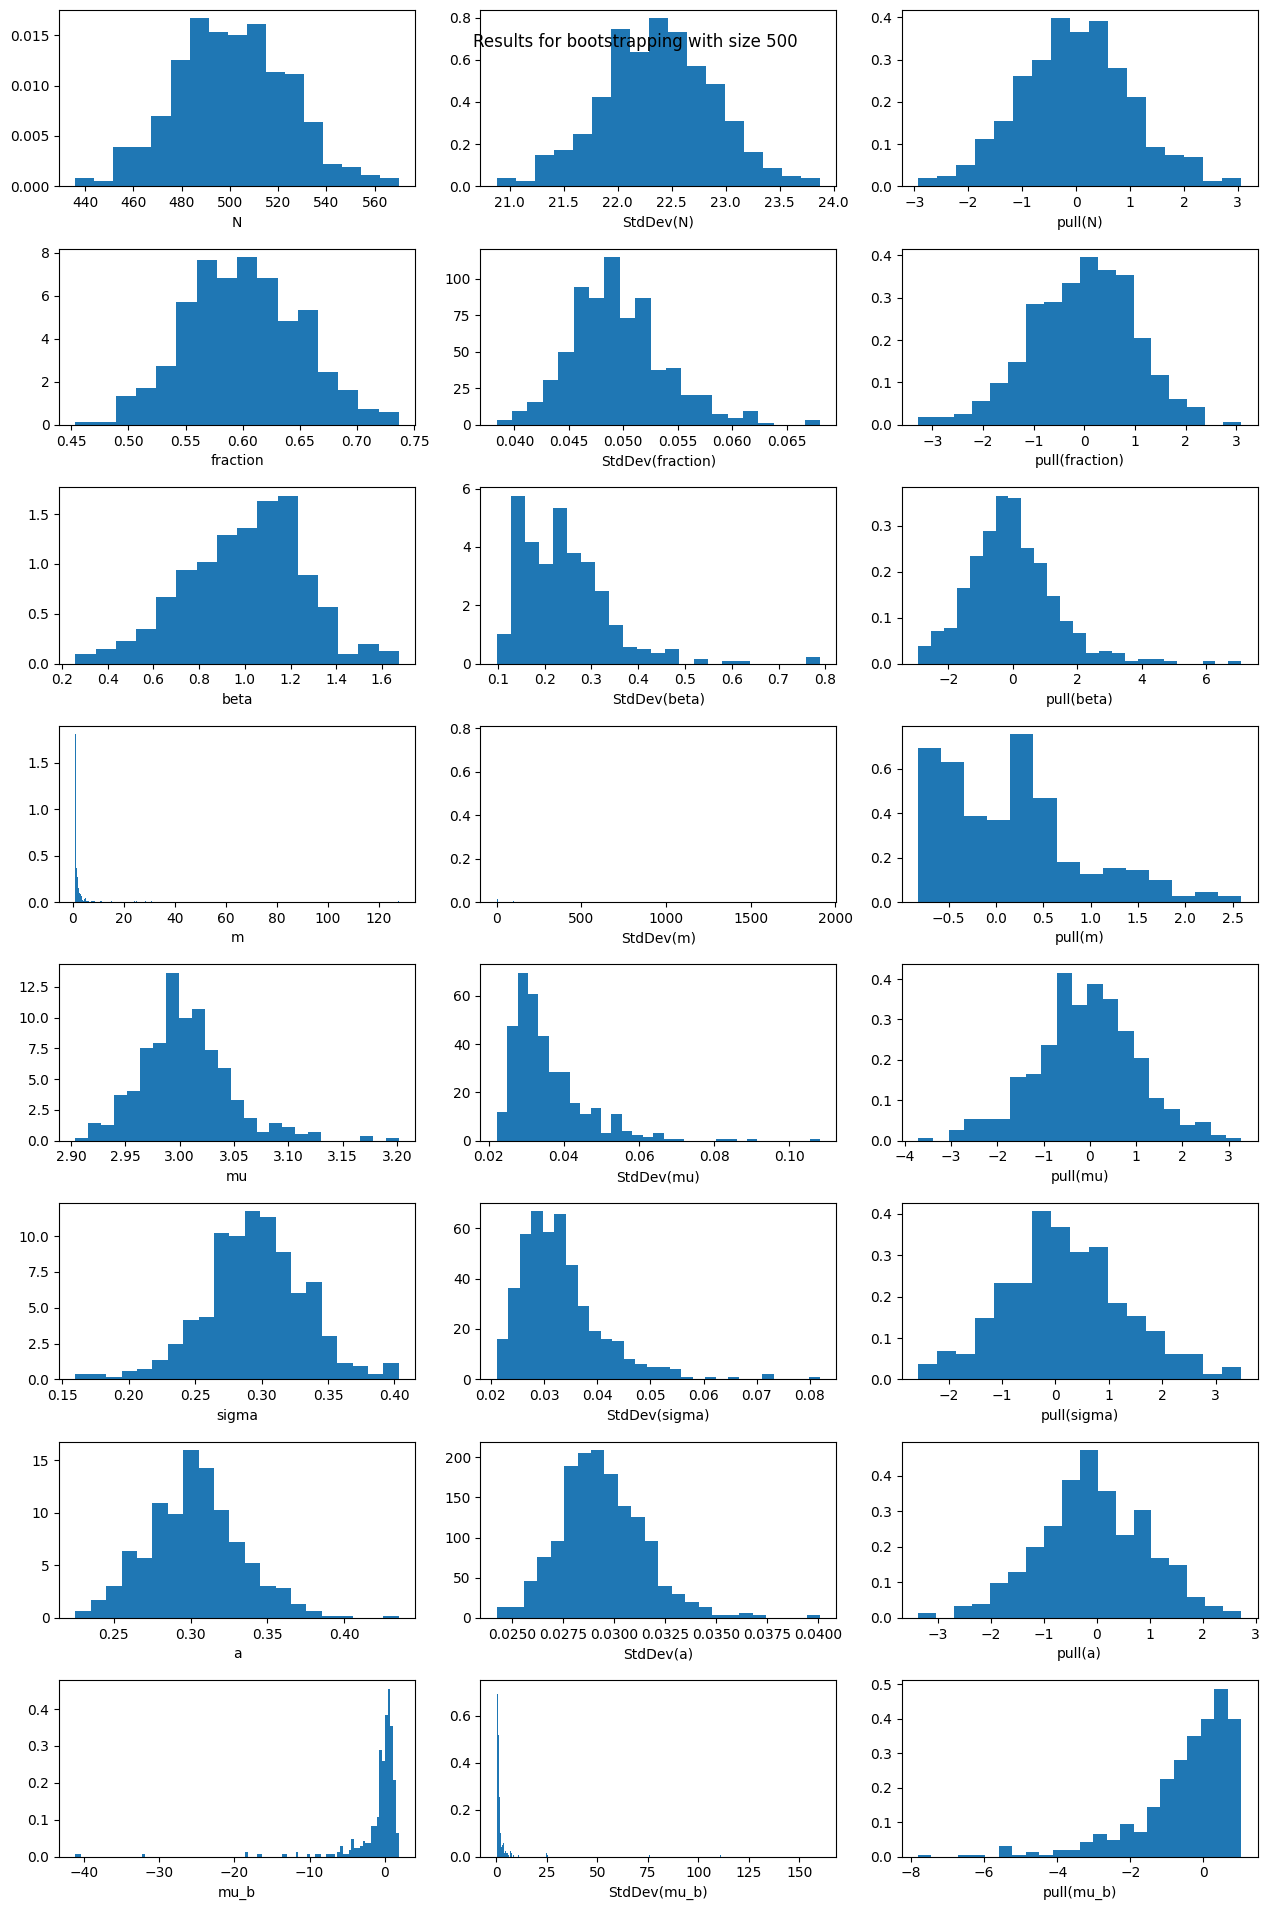

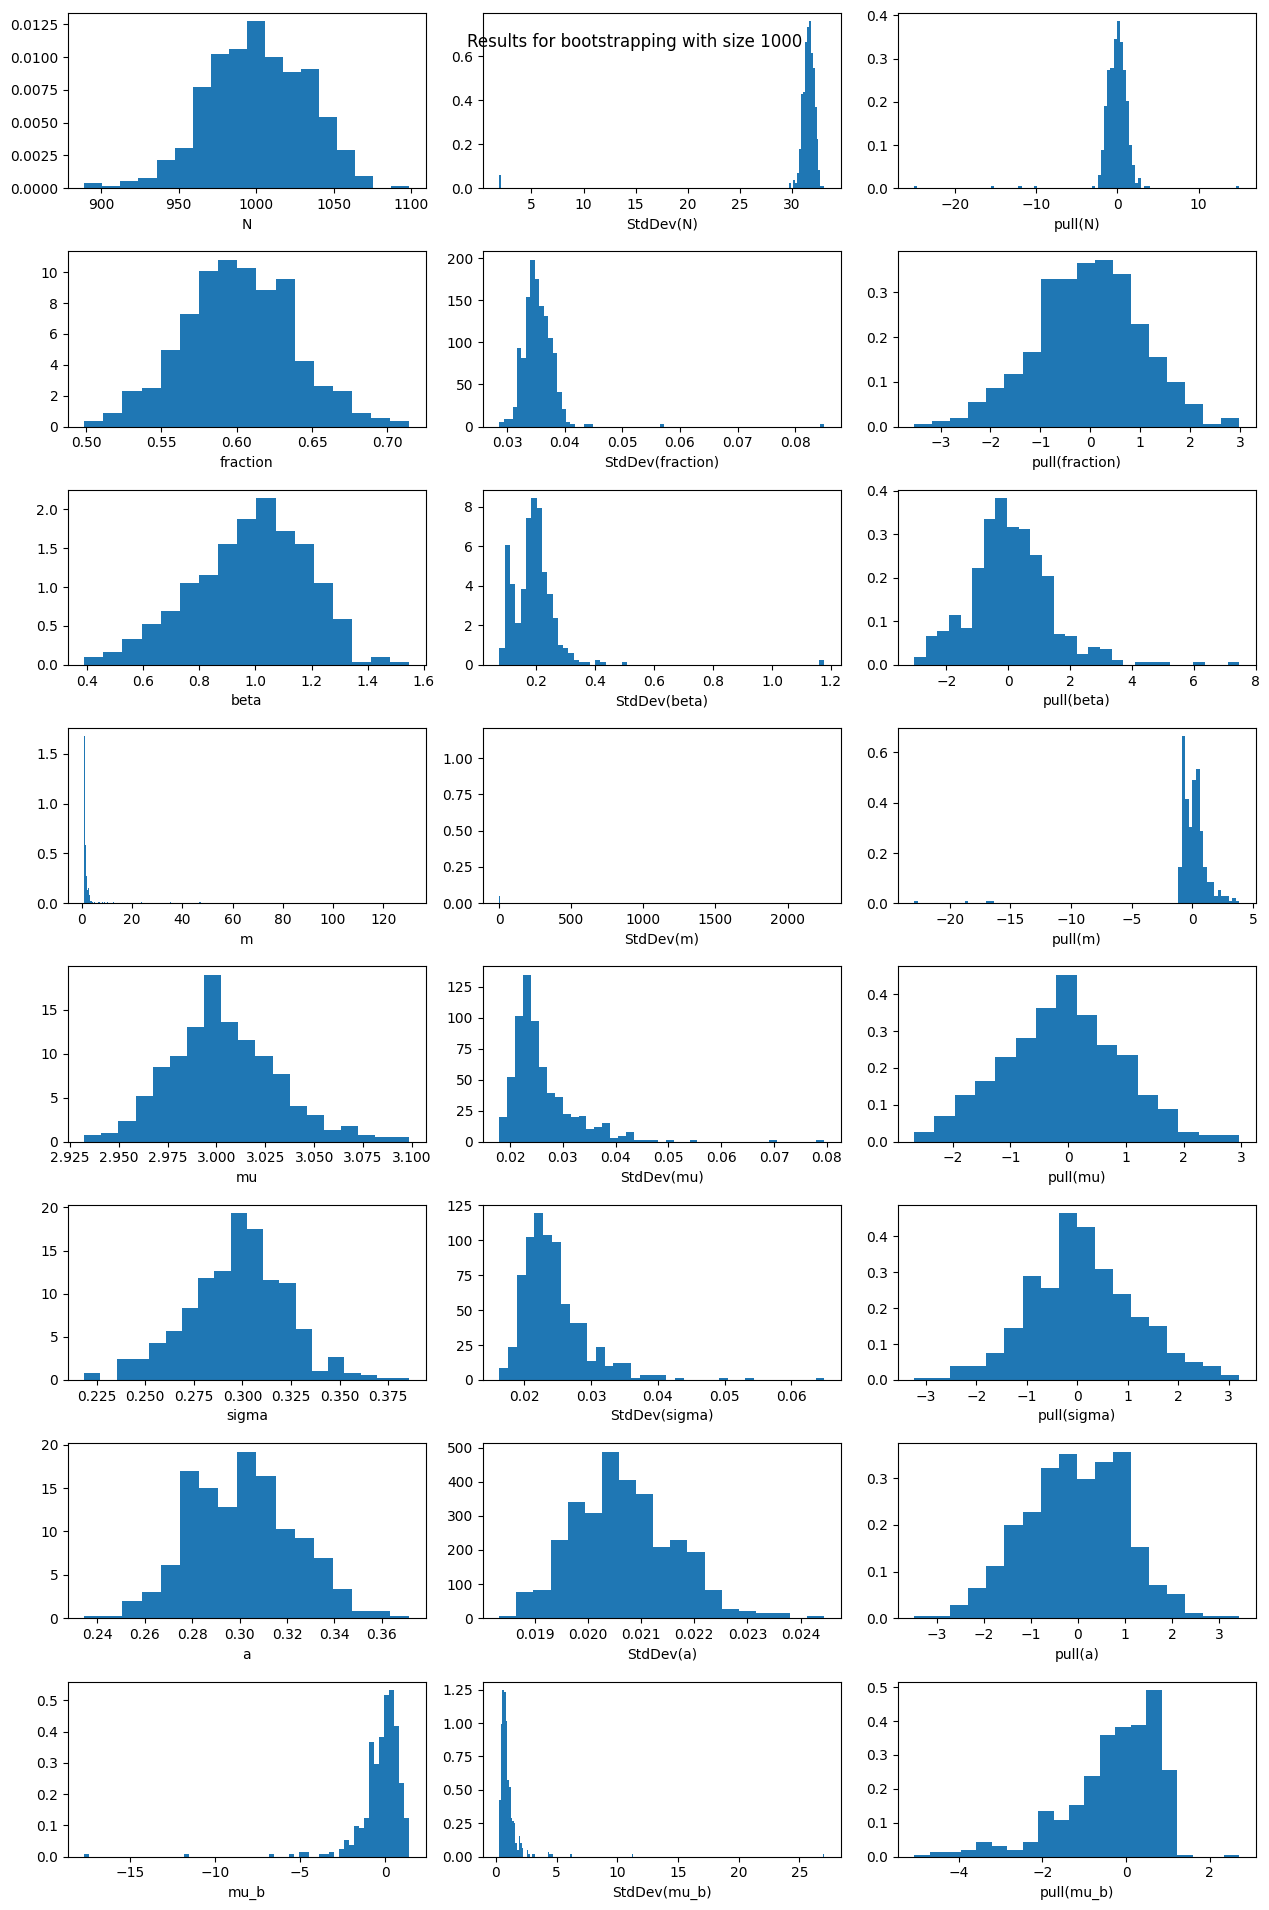

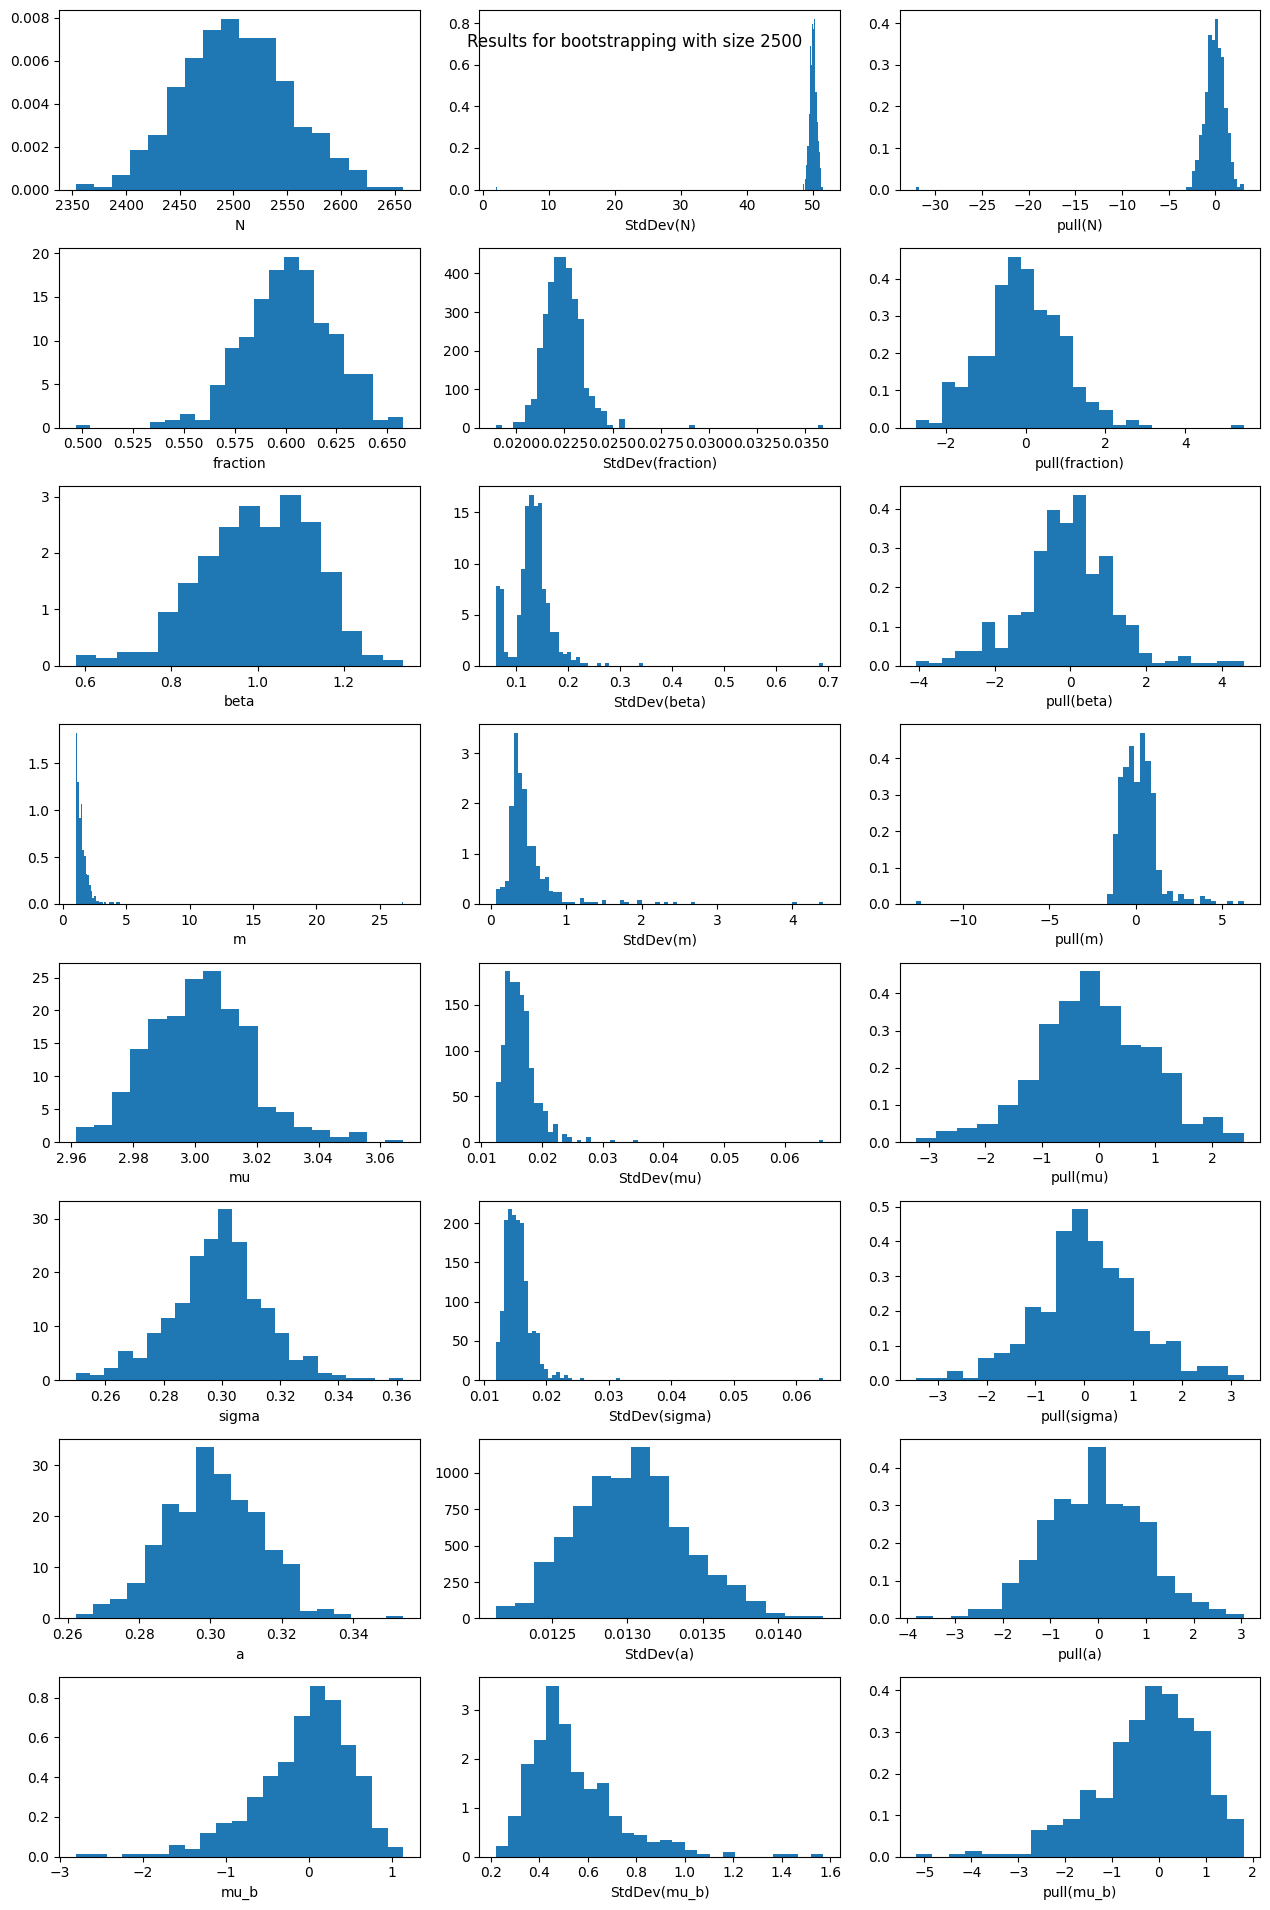

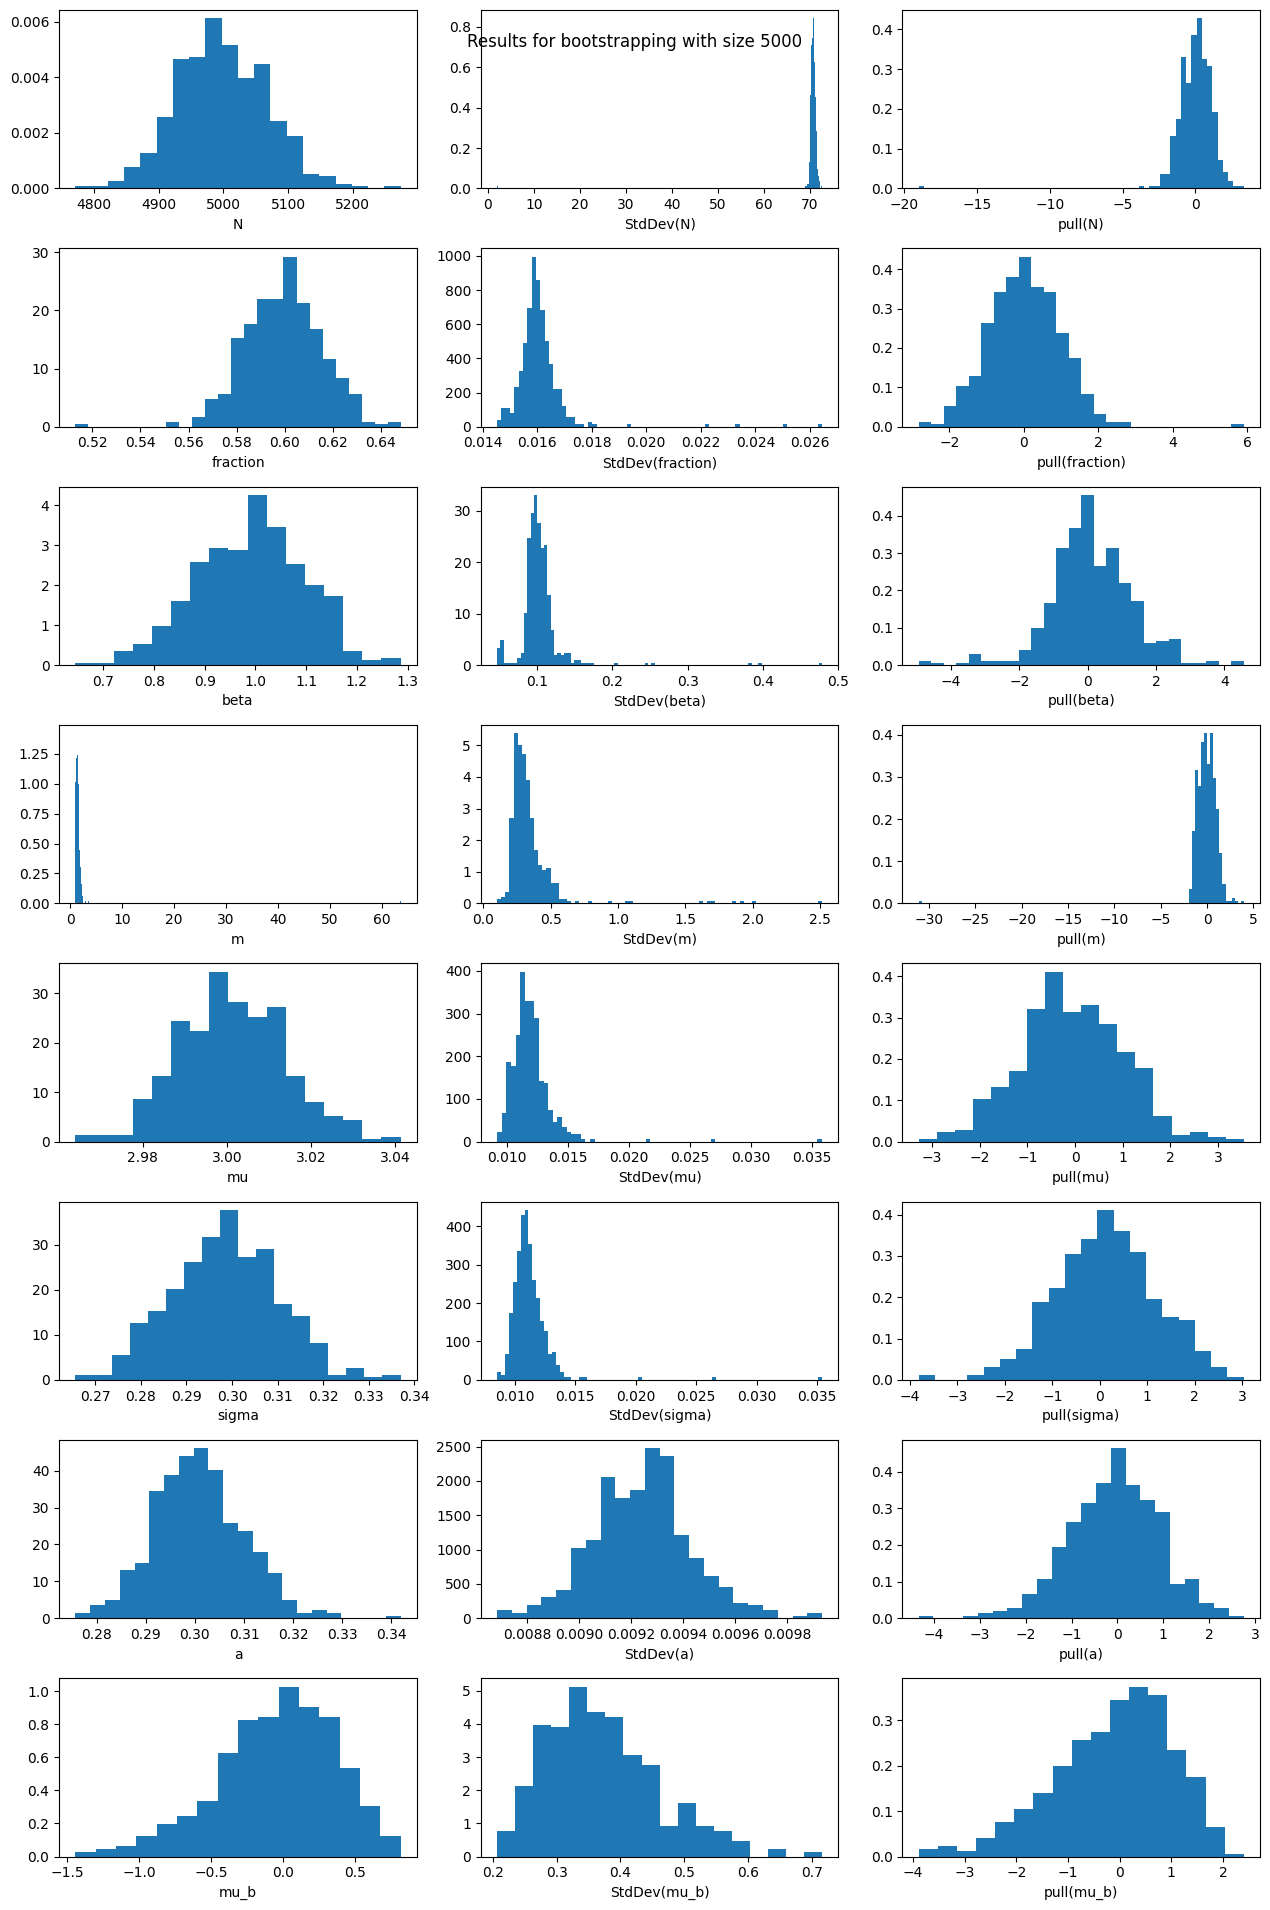

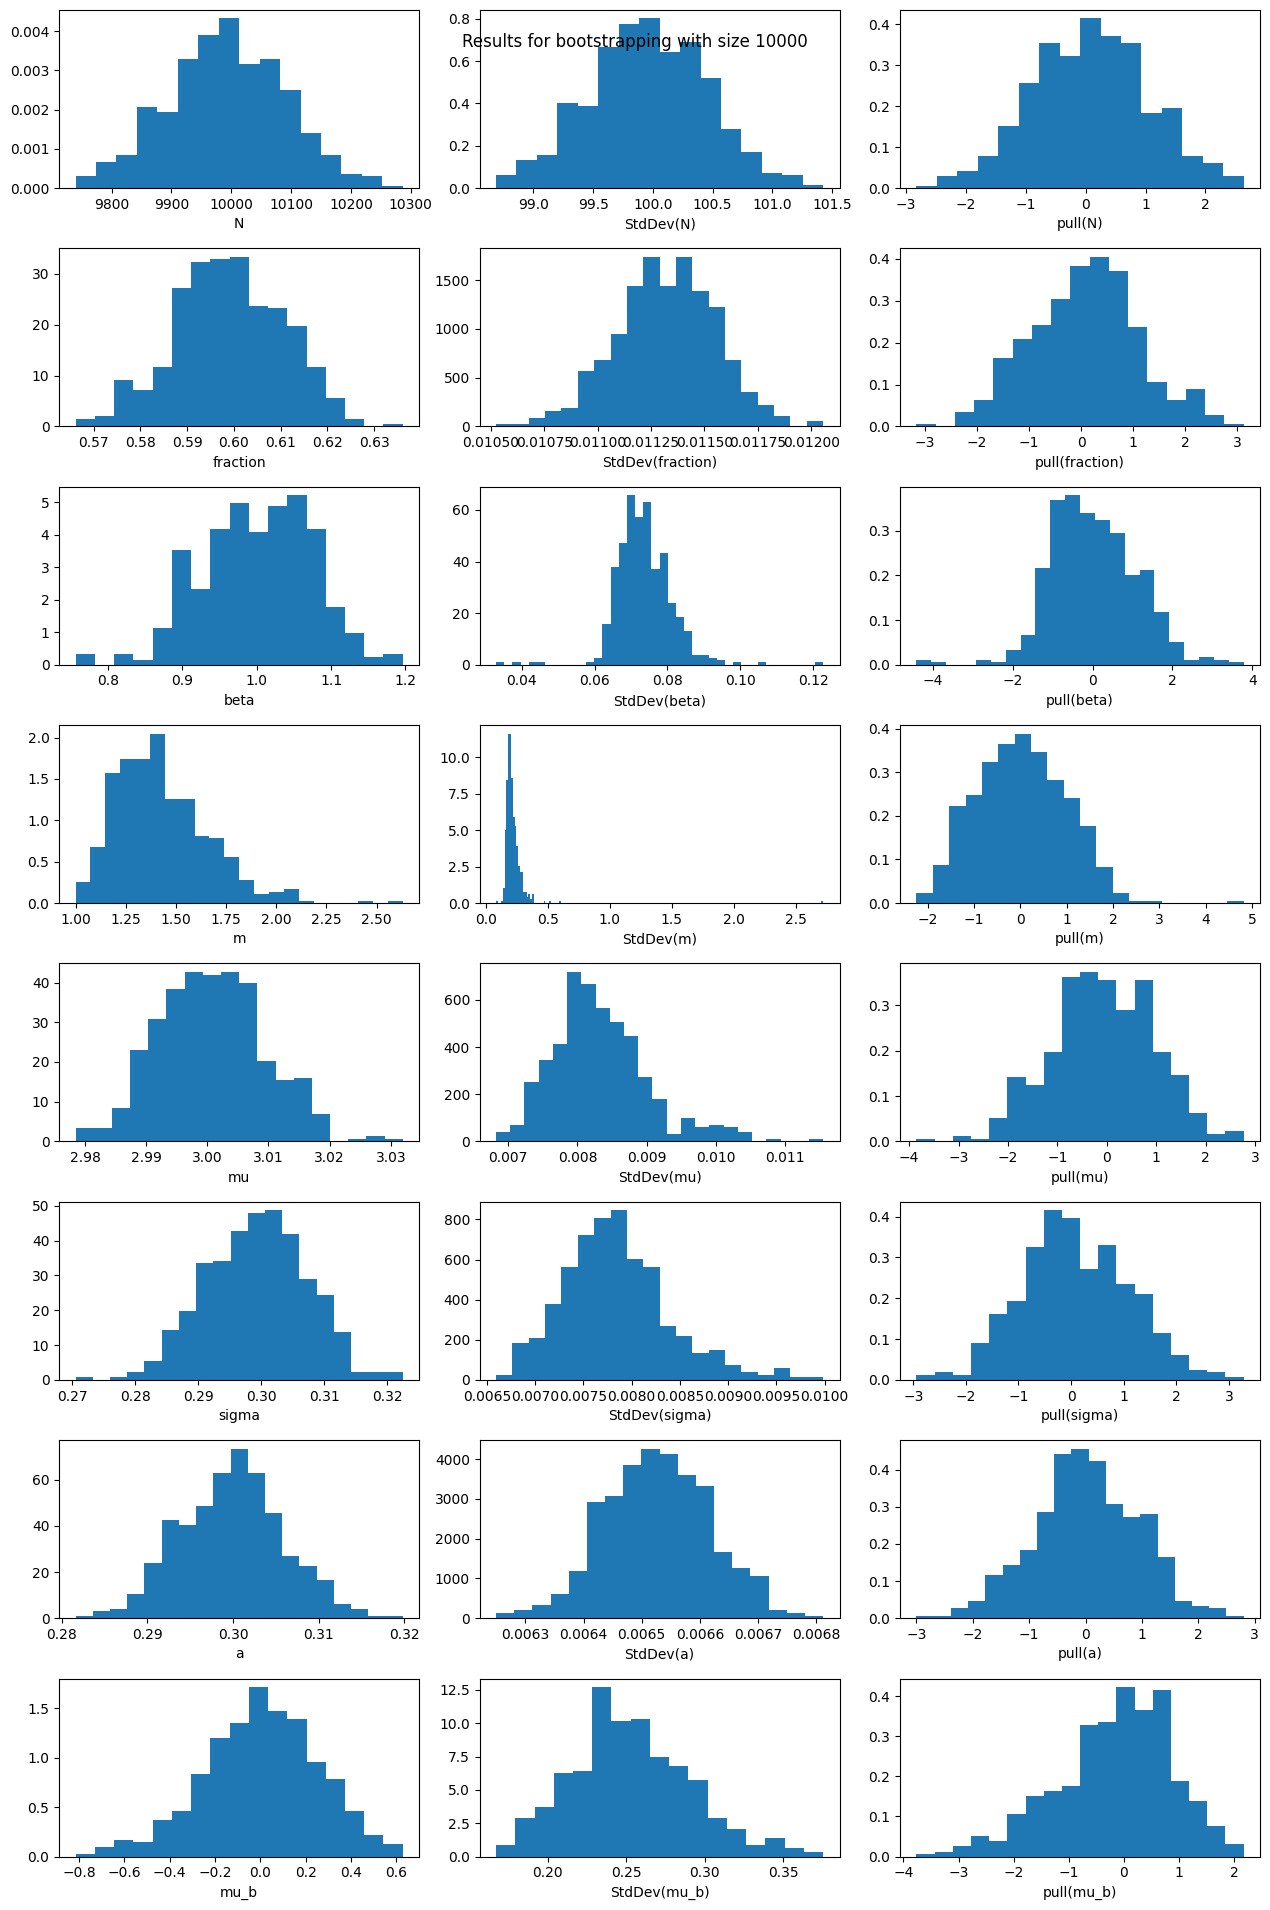

In [28]:
warnings.filterwarnings("ignore", category=RuntimeWarning)


# sample_sizes we will be generating
sample_sizes = [500, 1000, 2500, 5000, 10000]
ntoys = 500 # ensemble size
params = { "fraction": fraction, "beta": beta, "m": m, "mu": mu, "sigma": sigma, "x_left": x_left,
    "x_right": x_right, "a": a, "y_left": y_left, "y_right": y_right, "mu_b": mu_b, "sigma_b": sigma_b}

# parameters array
size = 500
params_arr = np.array([size, fraction, beta, m, mu, sigma, a, mu_b, sigma_b])

# dictionaries to store toy samples and estimated parameters,errors
storage_samples = {}
storage_params = {}

for size in sample_sizes:
    toys = [np.array(accept_reject_2d(func=func, xrange=xrange, yrange=yrange, size=np.random.poisson(size), params=params, fmax=fmax)) for i in range(ntoys)] # build array of toys
    storage_samples[size] = toys #storing for part (f)

    # adjust params_arr to have the size as the first element, reinitialize storage
    params_arr[0] = size
    estimates = []
    errors = []
    pulls = []  
    
    for toy in toys:
        alt_mi = btstrp_fit(toy, size) #get estimates and errors
        if alt_mi.valid and alt_mi.accurate: #check convergence happens and if hesse error estimates are valid
            estimates.append(np.array(alt_mi.values))
            errors.append(np.array(alt_mi.errors))
            pulls.append((params_arr-alt_mi.values)/alt_mi.errors)

    # turning into arrays for plotting
    estimates = np.array(estimates)
    errors = np.array(errors)
    pulls = np.array(pulls)

    # calling the function to plot
    fig = plotting(estimates, errors, pulls)
    fig.suptitle(f'Results for bootstrapping with size {size}')
    plt.show()

    # storing values, errors and pulls for part (f)
    storage_params[size] = {'estimates': estimates, 'errors': errors, 'pulls': pulls}

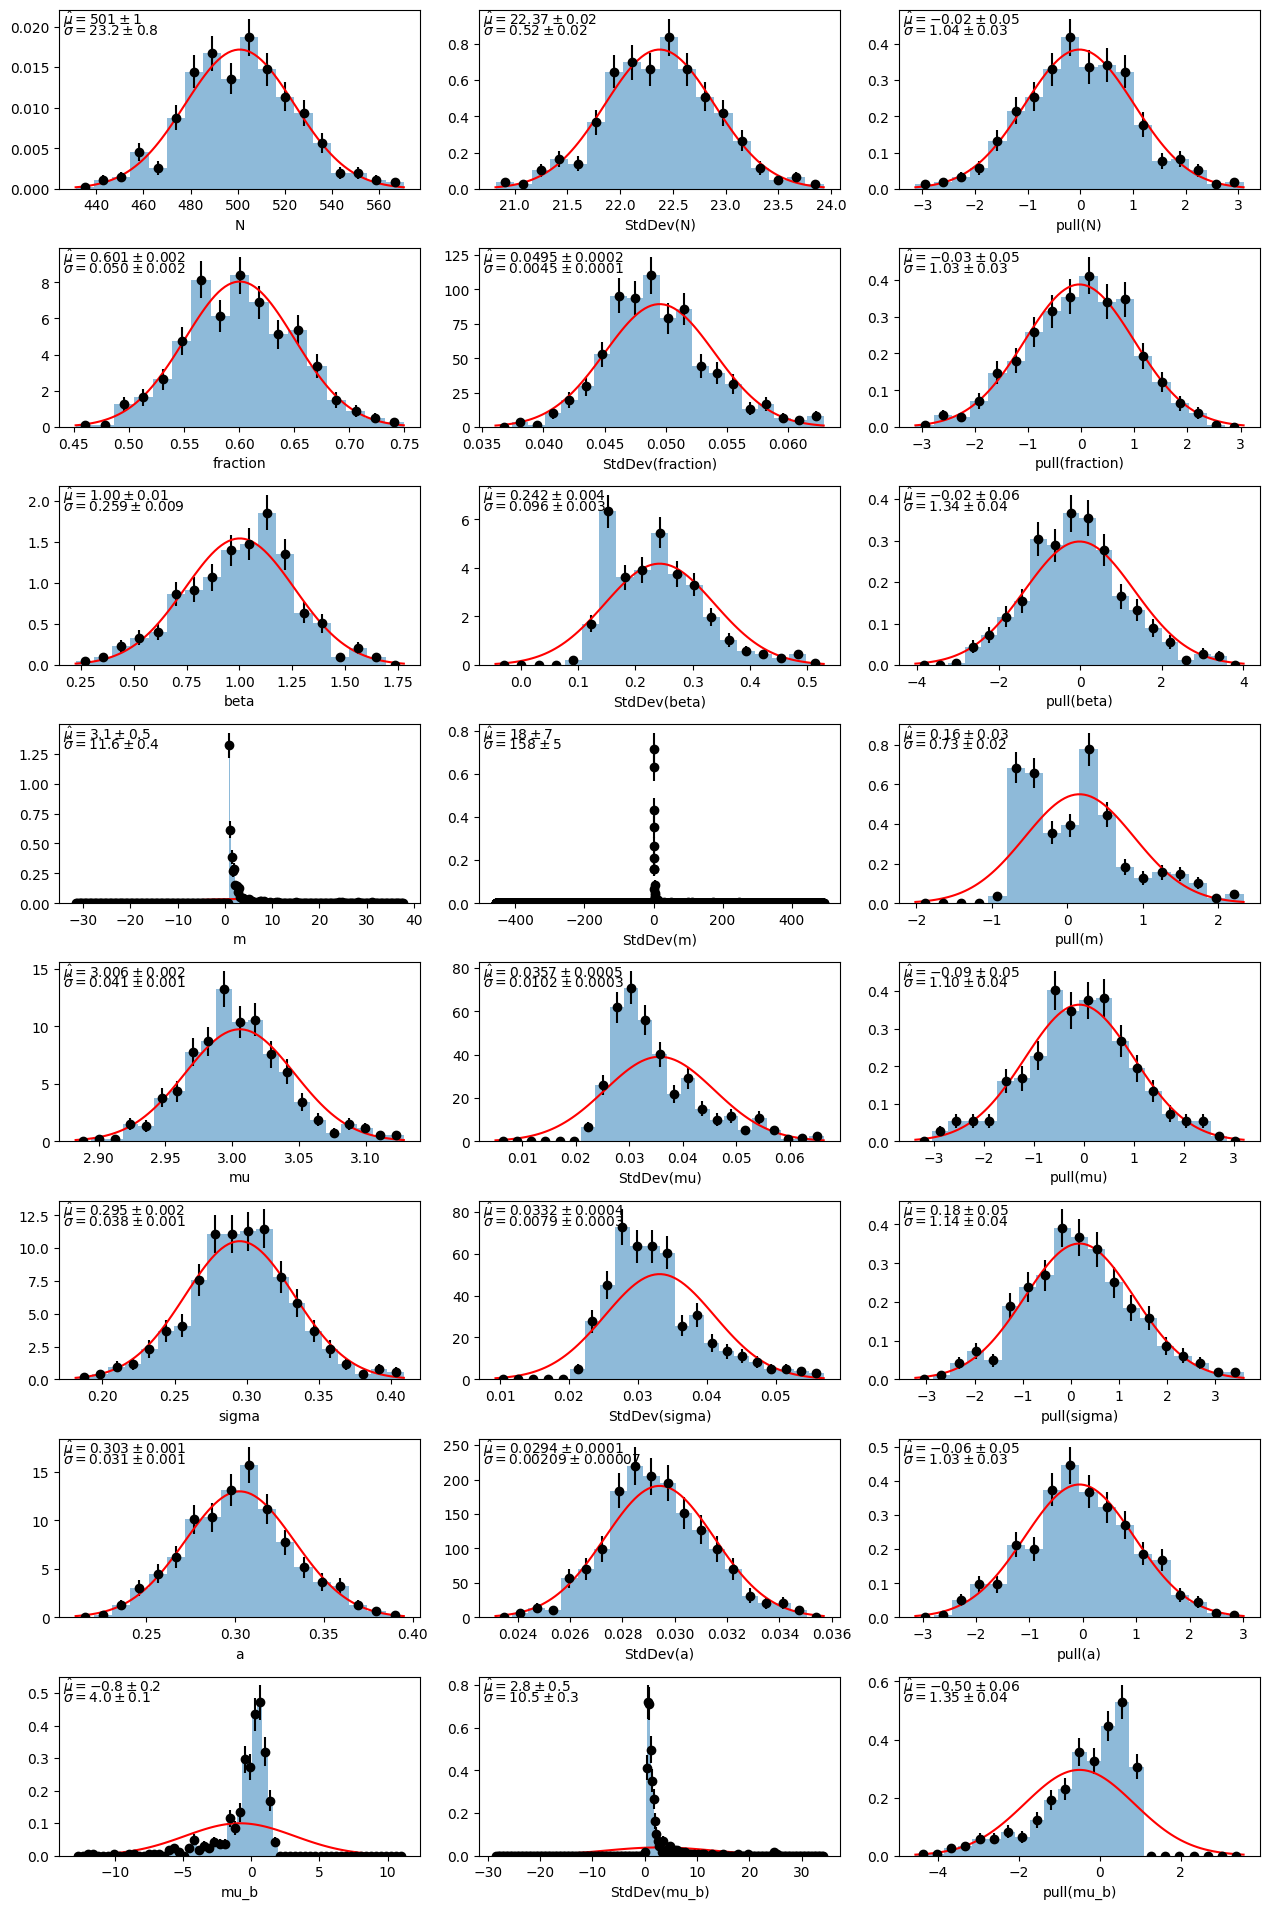

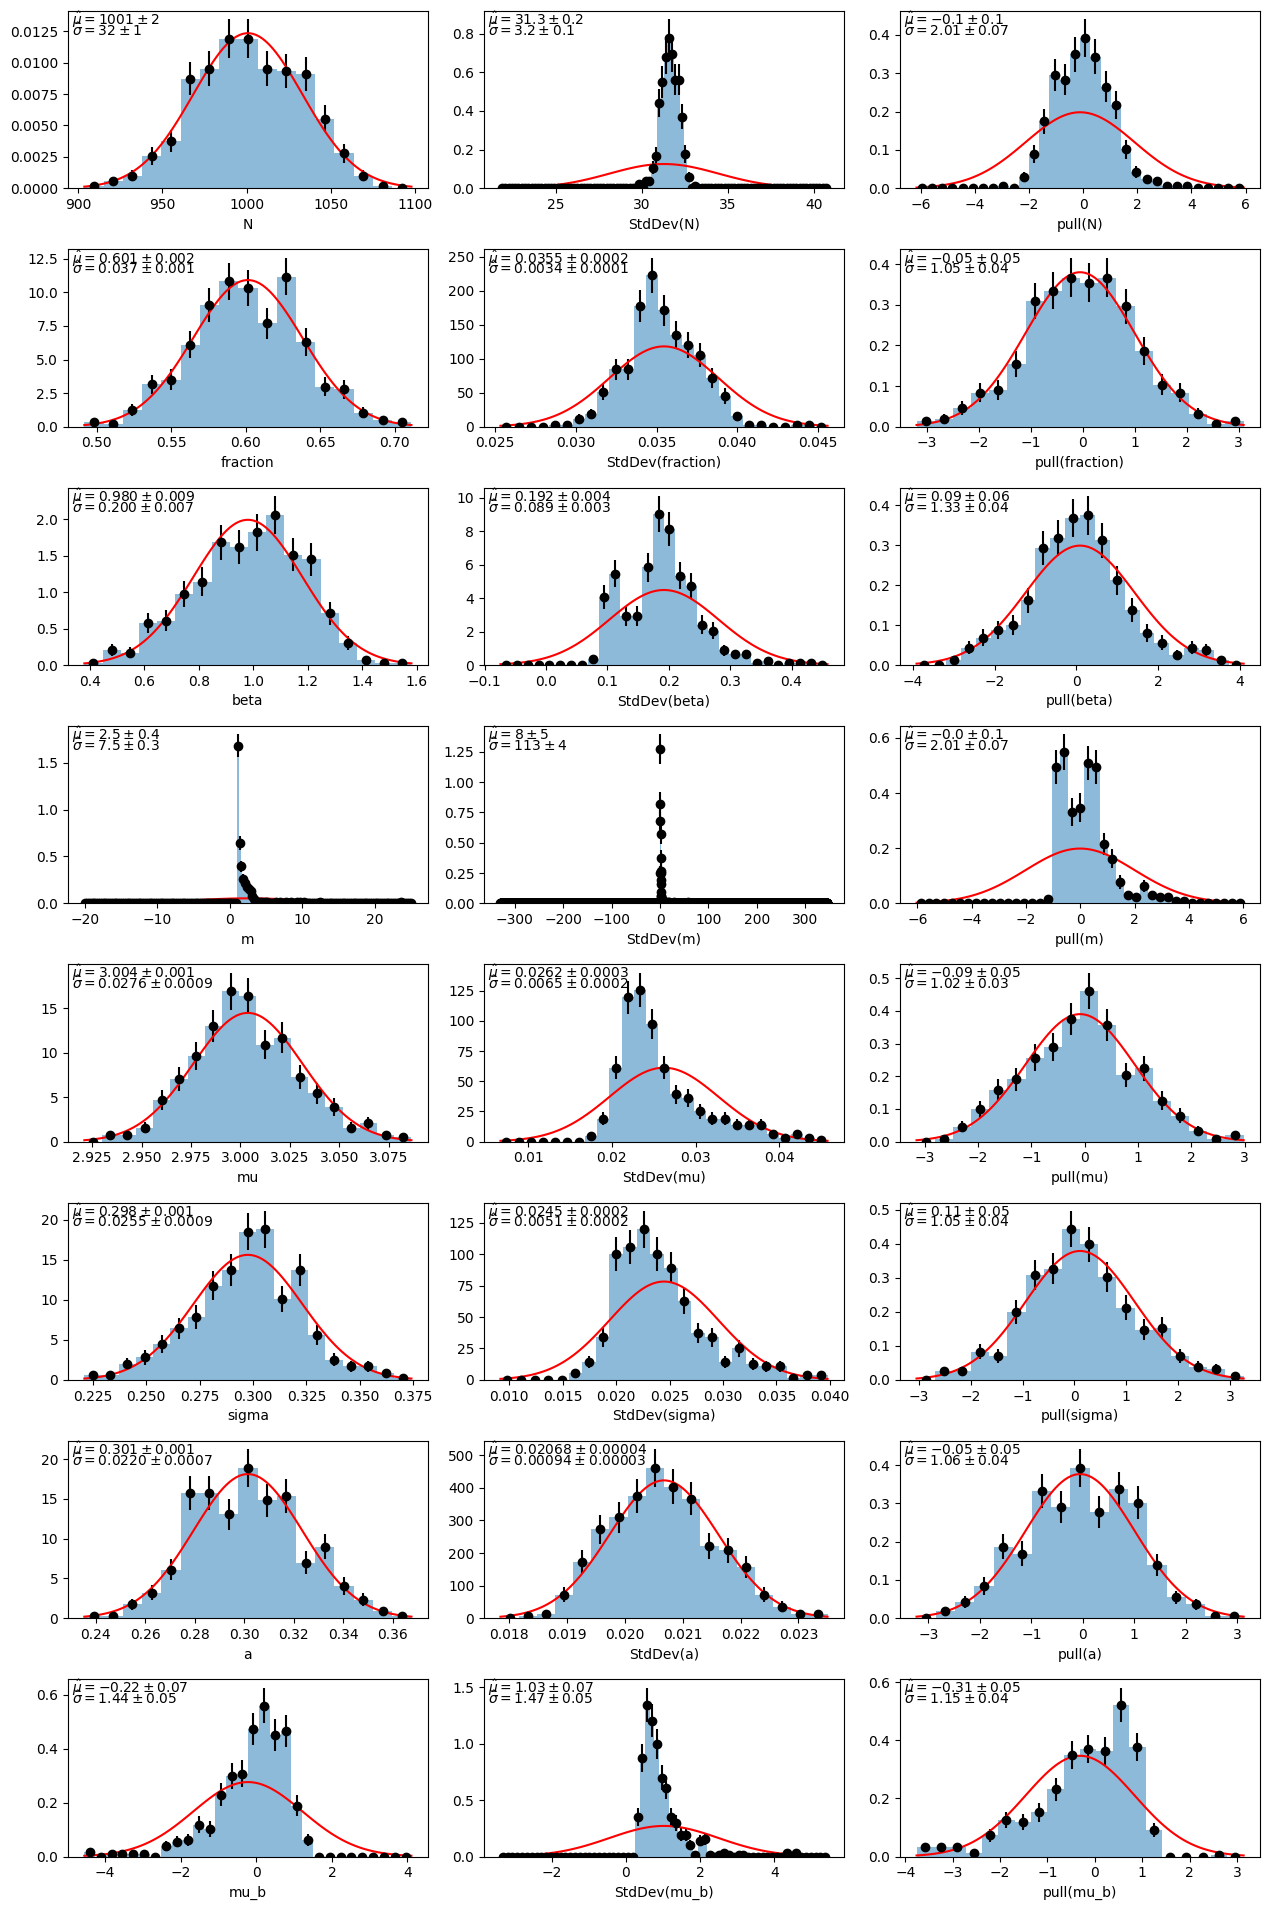

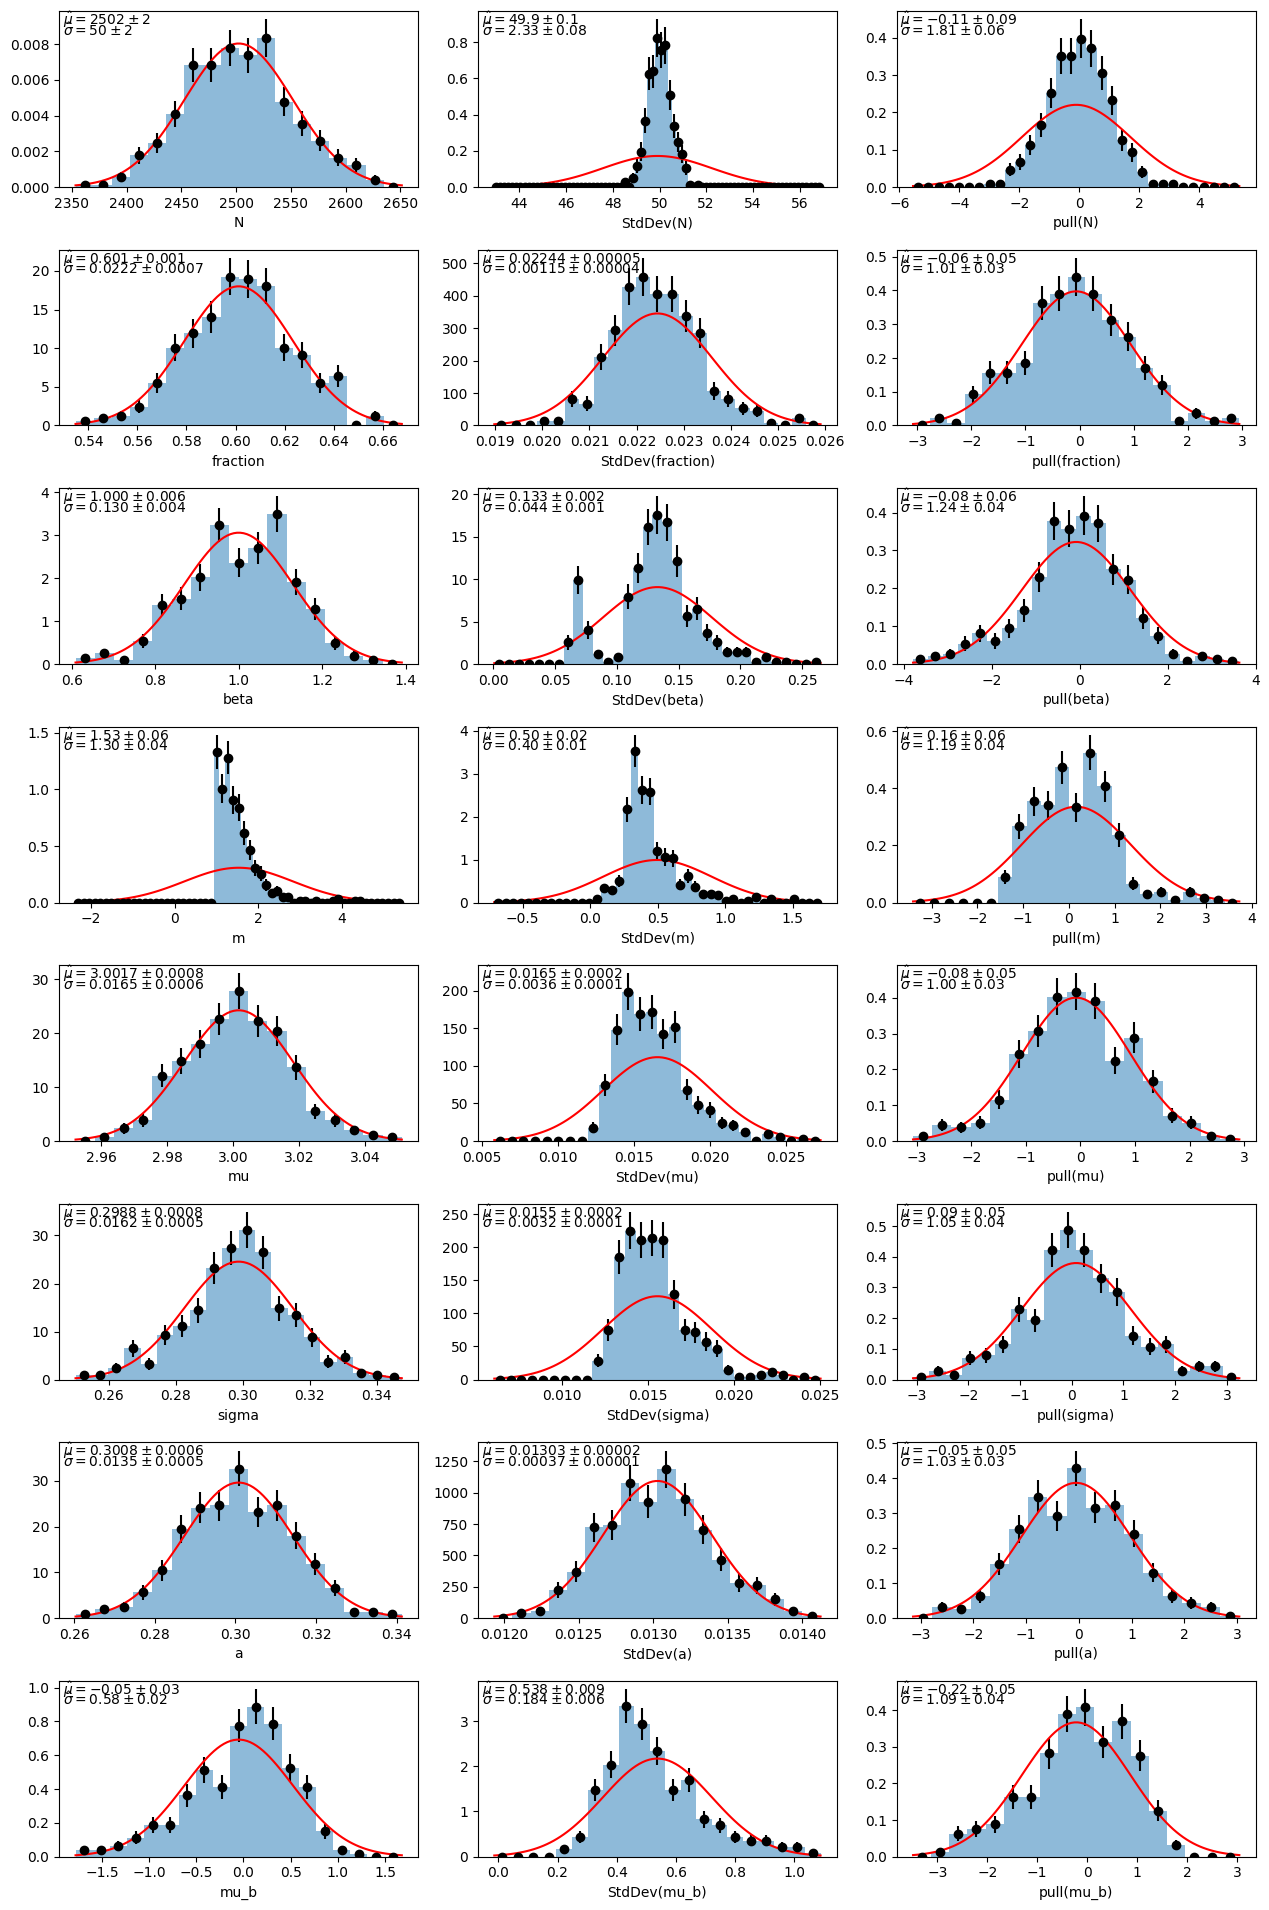

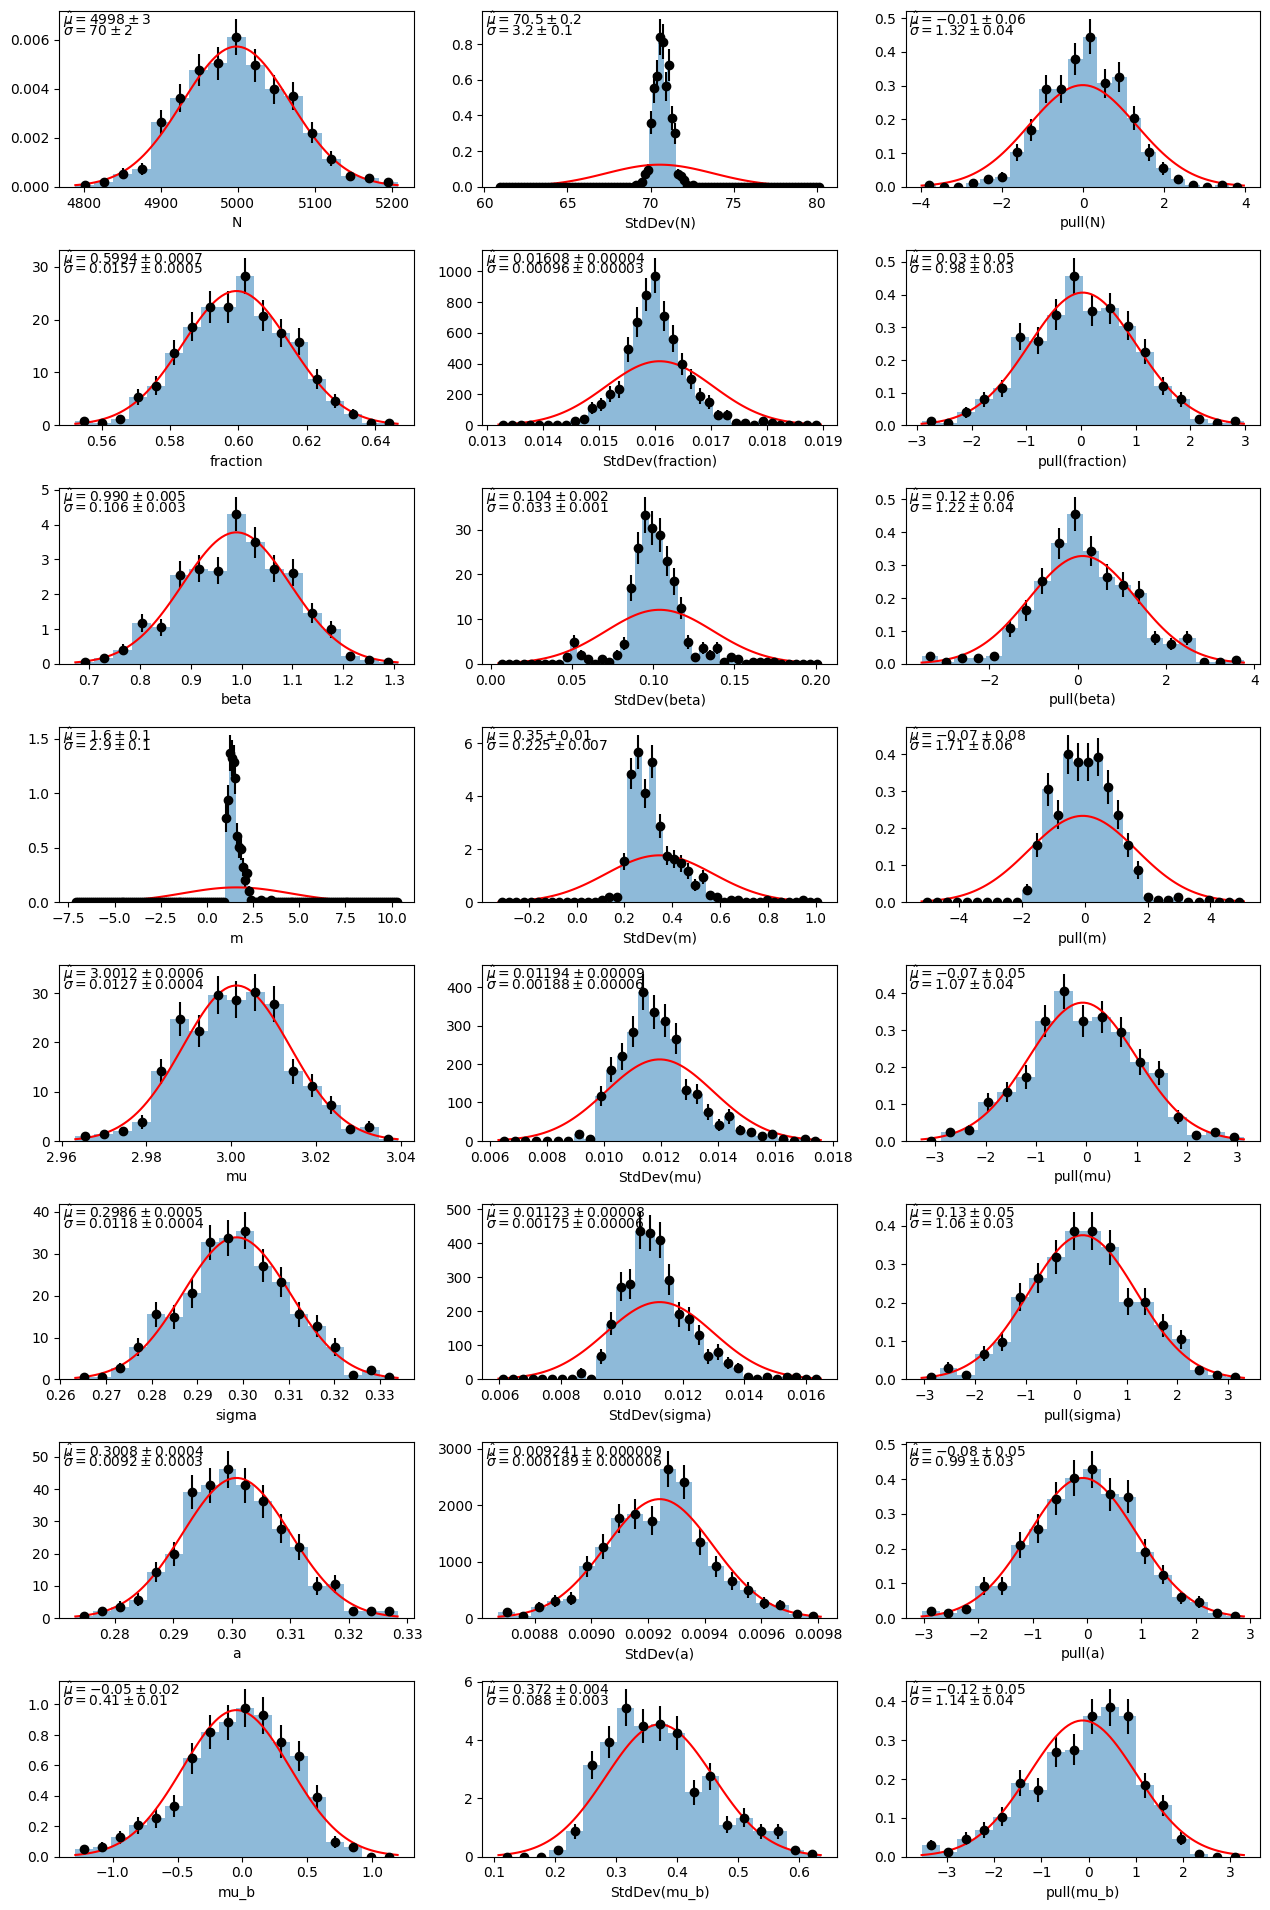

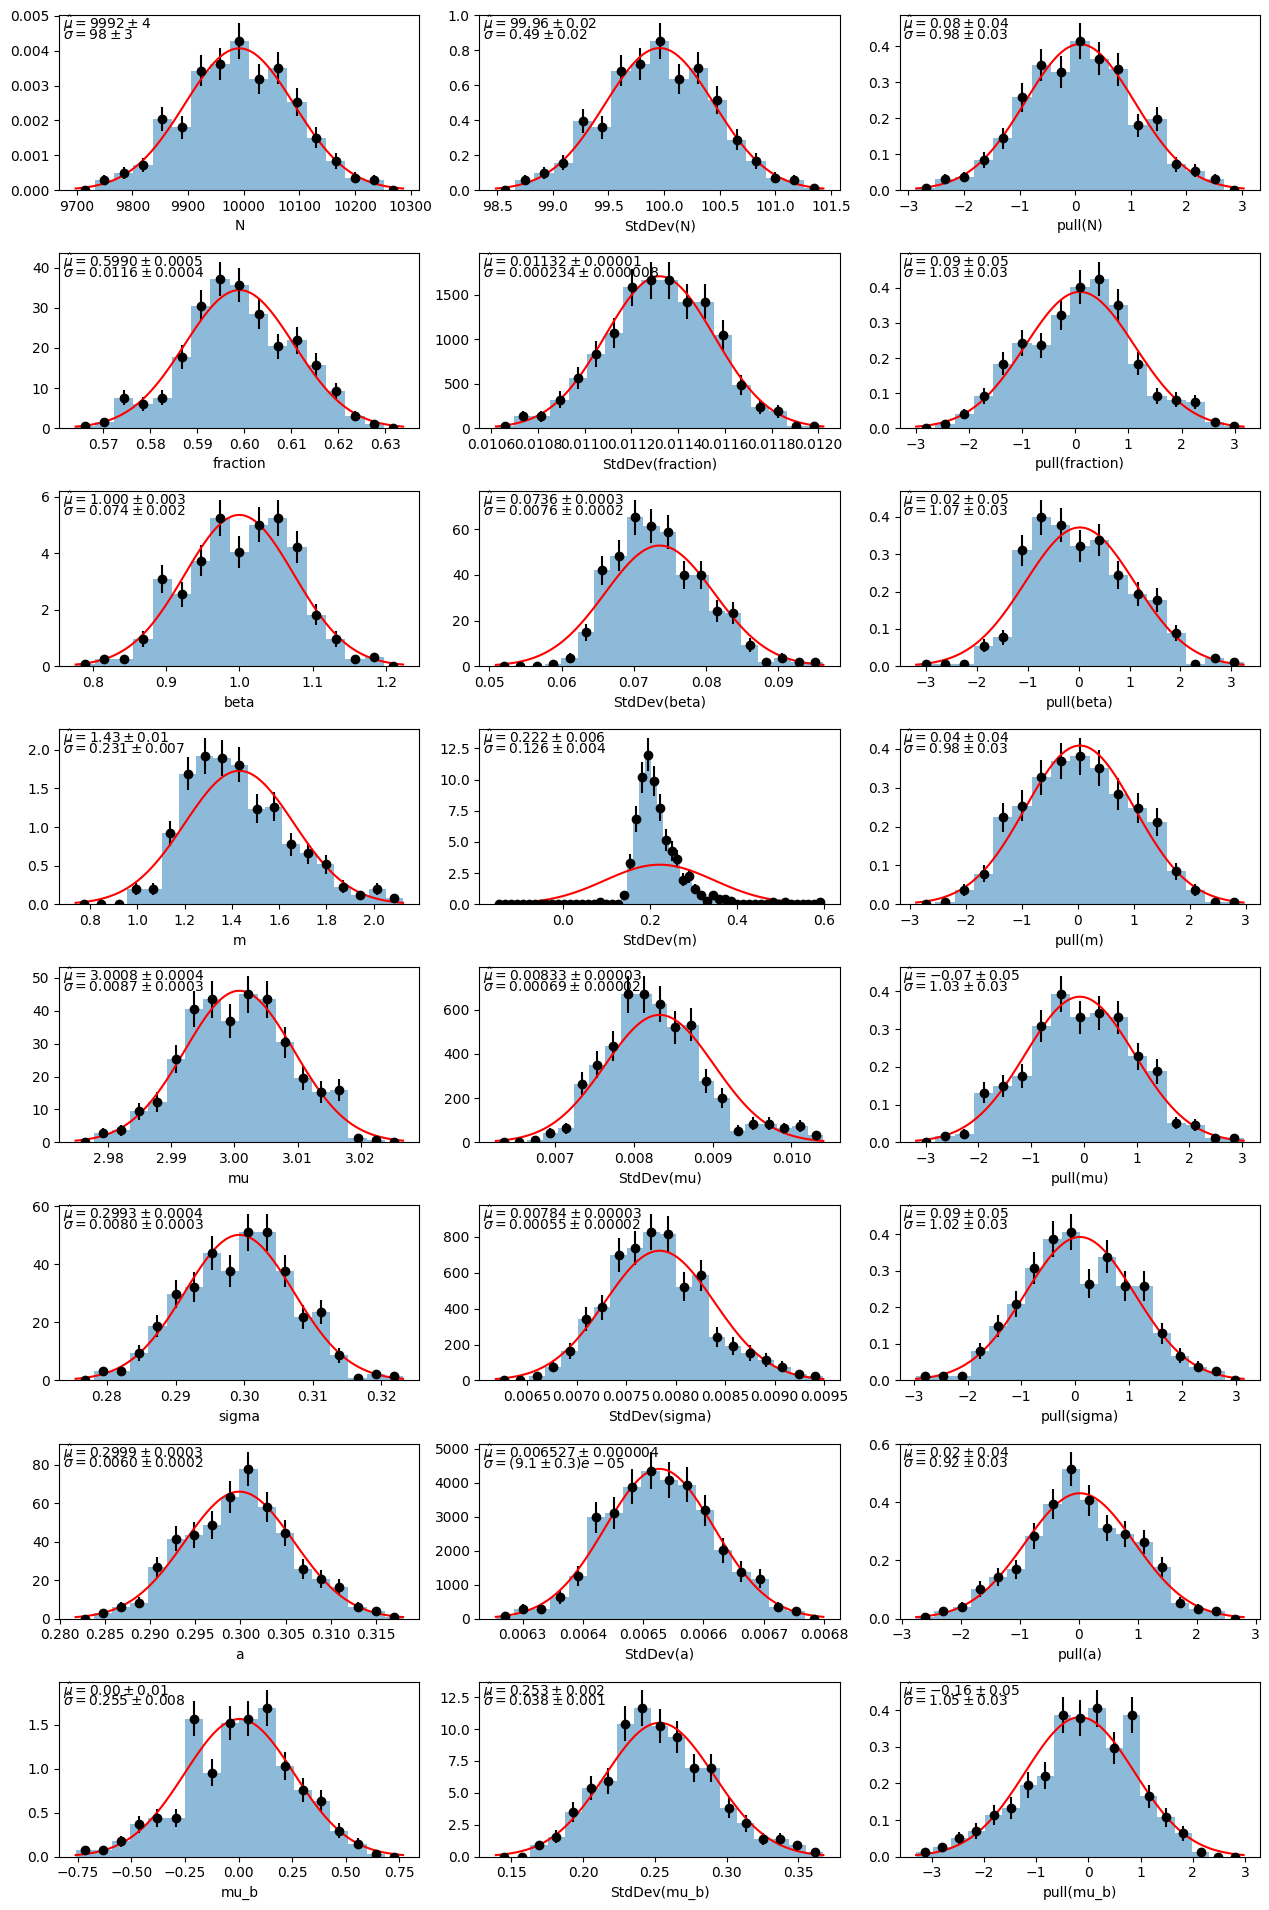

In [29]:
for size in sample_sizes:
    estimates = storage_params[size]['estimates']
    errors = storage_params[size]['errors']
    pulls = storage_params[size]['pulls']

    fig, axes = plt.subplots(8, 3, figsize=(12.8, 19.2))
    for(i, par), ax in zip(enumerate(['N', 'fraction', 'beta', 'm', 'mu', 'sigma', 'a', 'mu_b', 'sigma_b']), axes):
        
        ax = axes[i,0]
        plot(estimates[:,i], ax)
        ax.set_xlabel(par)

        ax = axes[i,1]
        plot(errors[:,i], ax)
        ax.set_xlabel(f"StdDev({par})")

        ax = axes[i,2]
        plot(pulls[:,i], ax)
        ax.set_xlabel(f"pull({par})")

        plt.tight_layout()

In [30]:
#just in case
copy_storage_params = storage_params
copystorage_samples = storage_samples

#### Bias of lambda

Text(0.5, 0, 'Sample size')

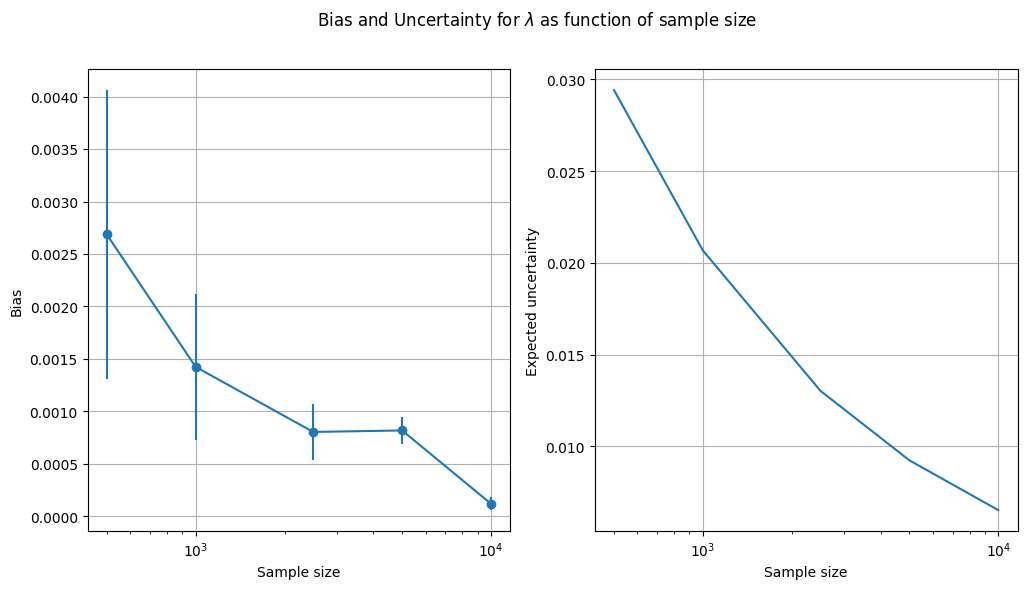

In [31]:
arr_lambda_diff = []
arr_lambda_est_errs = []
arr_lambda_est_errs_stddev = []
arr_lambda_diff_std = []
lambda_true = 0.3

for size in sample_sizes:
    # extract the data
    estimates = storage_params[size]['estimates']
    errors = storage_params[size]['errors']
    
    # extract only the lambda which was at index 6
    lambda_vals = estimates[:,6]
    lambda_errs = errors[:,6]

    # calculate the bias of estimates for each sample size
    arr_lambda_diff.append(lambda_true - np.mean(lambda_vals))
    arr_lambda_est_errs.append(lambda_errs.mean())

    # calculate standard deviation for error bars
    arr_lambda_diff_std.append(np.std(lambda_vals) / np.sqrt(size))
    arr_lambda_est_errs_stddev.append(np.std(lambda_errs) / np.sqrt(size))

fig, ax = plt.subplots(1,2, figsize=(12,6))
fig.suptitle(r"Bias and Uncertainty for $\lambda$ as function of sample size")

ax[0].errorbar(sample_sizes, np.abs(arr_lambda_diff), yerr=arr_lambda_diff_std, fmt='o-', label='Bias')
ax[0].grid(True)
ax[0].set_xscale('log')
ax[0].set_ylabel('Bias')
ax[0].set_xlabel('Sample size')

ax[1].plot(sample_sizes, np.abs(arr_lambda_est_errs))
ax[1].grid(True)
ax[1].set_xscale('log')
ax[1].set_ylabel('Expected uncertainty')
ax[1].set_xlabel('Sample size')



### sWeights

#### EMLE in x

In [32]:
from sweights import SWeight
# We define a function which performs the eMLE in x
def emle_x(data):
    X = data[:,0]
    N = len(X)
    Ns = int(fraction*N) # quantity of signal
    Nb = size - Ns # quantity of background
    Ns = np.random.poisson(Ns)
    Nb = np.random.poisson(Nb)
    
    xrange = (0,5)

    # define everything that's dependent on X
    def s_x(X, beta, m, mu, sigma):
        return g_s(X, beta, m, mu, sigma, 0, 5)

    def b_x(X):
        return g_b(X, 0, 5)

    def tmodel(X, Ns, Nb, beta, m, mu, sigma):
        return Ns*s_x(X, beta, m, mu, sigma) + Nb*b_x(X)

    def tdensity(X, Ns, Nb, beta, m, mu, sigma):
        return Ns+Nb, tmodel(X, Ns, Nb, beta, m, mu, sigma)

    # use iminuit to perform the fit
    n2ll = cost.ExtendedUnbinnedNLL(data[:,0], tdensity)
    mi = Minuit(n2ll, Ns, Nb, beta, m, mu, sigma)

    mi.limits["sigma"] = (0, None) 
    mi.limits["beta"] = (0, None)
    mi.limits["m"] = (1, None) # m > 1

    mi.migrad()
    mi.hesse()

    # evaluate signal pdf, using parameter values obtained from the fit 
    sf = lambda x: s_x(x, mi.values['beta'], mi.values['m'], mi.values['mu'], mi.values['sigma'])
    bf = lambda x: b_x(x) # background pdf
    sy = mi.values['Ns'] # estimated quantity of signal (yield)
    by = mi.values['Nb'] # yield of background 

    # discvarranges - range of the discriminating variable
    sweighter = SWeight(data[:,0], pdfs=[sf,bf], yields=[sy,by], discvarranges=(xrange,))

    return sweighter

In [33]:
# ExtendedBinnedNLL
from scipy import stats
yrange = (0,10)
sweighter_dict = {}
lambdas_sw_dict = {}
lambdas_err_sw_dict = {}

# need cdf for binned NLL
def y_sig(Y, N, a):
        return stats.truncexpon.cdf(Y, b=10, loc=0, scale=1/a) * N

for size in sample_sizes:
    sweighter_arr = []
    lambdas_sw_arr = []
    lambdas_err_sw_arr = []

    # get toy data
    toy_data = storage_samples[size]
    for toy in toy_data:
        X = toy[:,0]
        N = len(X)

        # get the sWeights
        try:
            sweighter = emle_x(toy)
        except Exception as e:
            continue
        
        sweighter_arr.append(sweighter)

        # extract the weights for signal and background
        sw = sweighter.get_weight(0, toy[:,0])
        bw = sweighter.get_weight(1, toy[:,0])

        ysw, ye = np.histogram(toy[:,1], bins=50, range=yrange, weights=sw) #ysw is array of weighted bin counts
        #ybw, ye = np.histogram(toy[:,1], bins=50, range=yrange, weights=bw) #ye is array of bin edges

        cy = 0.5*(ye[1:]+ye[:-1]) #central values of bins

        # fit a function to our data using Binned fit from iminuit
        nll = cost.ExtendedBinnedNLL(ysw, ye, y_sig)
        mi_s = Minuit(nll, N=N*fraction, a=0.3)
        mi_s.limits["a"] = (0, None)
        mi_s.migrad()
        mi_s.hesse()

        lambdas_sw_arr.append(mi_s.values['a'])
        lambdas_err_sw_arr.append(mi_s.errors['a'])

    sweighter_dict[size] = sweighter_arr
    lambdas_sw_dict[size] = lambdas_sw_arr
    lambdas_err_sw_dict[size] = lambdas_err_sw_arr

    PDF normalisations:
	 0 0.9999999997801268
	 1 1.0
    Integral of w*pdf matrix (should be close to the
                identity):
	[[ 1.00167327 -0.00191709]
	 [-0.00167366  1.00191602]]
    Check of weight sums (should match yields):
	Component  | sWeightSum |   Yield    |   Diff    |
	---------------------------------------------------
	  0        |   263.2487 |   263.2487 |     0.00% |
	  1        |   229.7510 |   229.7510 |     0.00% |
    PDF normalisations:
	 0 1.0000000007087515
	 1 1.0
    Integral of w*pdf matrix (should be close to the
                identity):
	[[ 1.00328259 -0.00580952]
	 [-0.00326369  1.00583763]]
    Check of weight sums (should match yields):
	Component  | sWeightSum |   Yield    |   Diff    |
	---------------------------------------------------
	  0        |   311.6201 |   311.6201 |     0.00% |
	  1        |   175.3907 |   175.3907 |     0.00% |
    PDF normalisations:
	 0 0.9999999997383481
	 1 1.0
    Integral of w*pdf matrix (should be close t

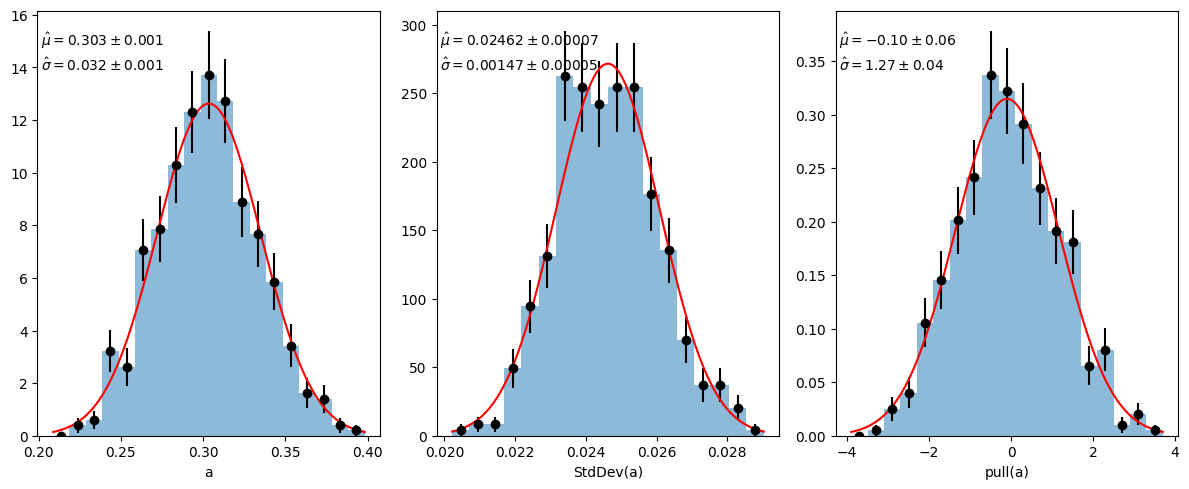

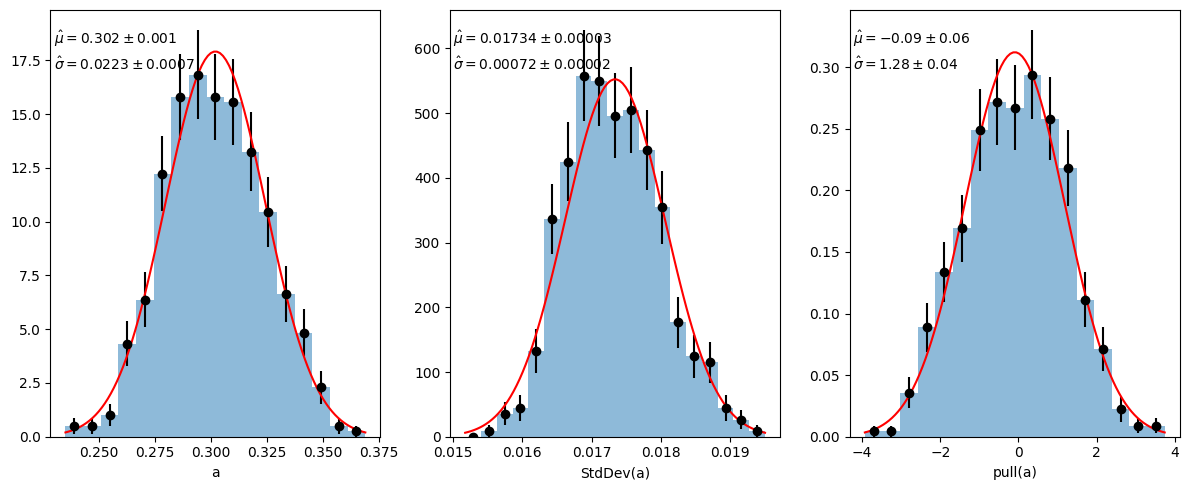

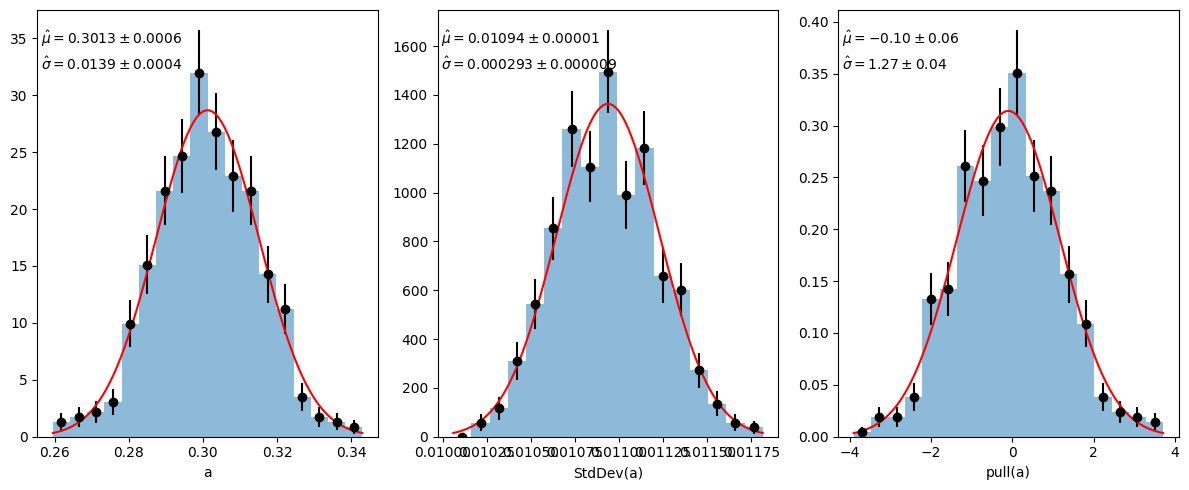

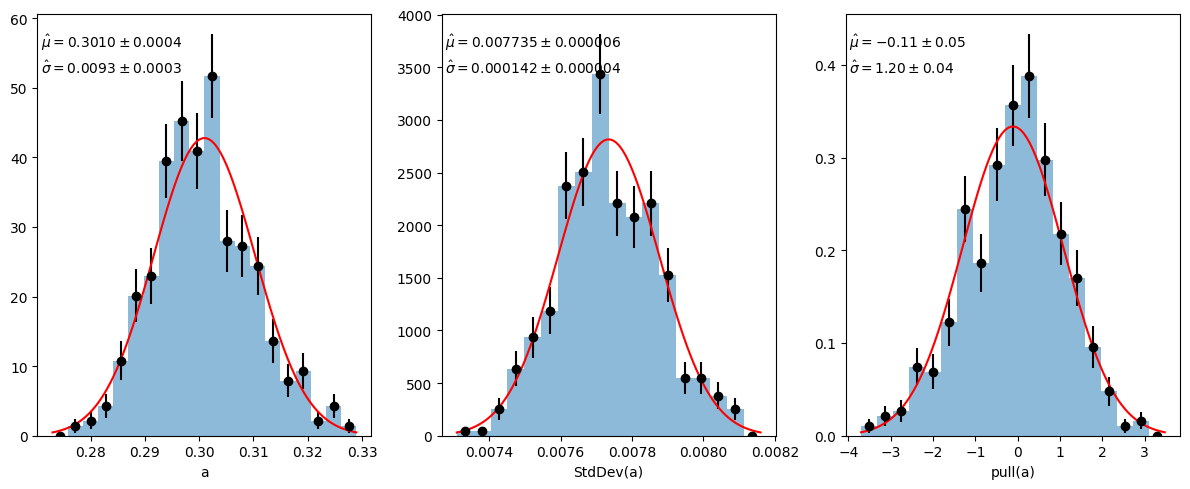

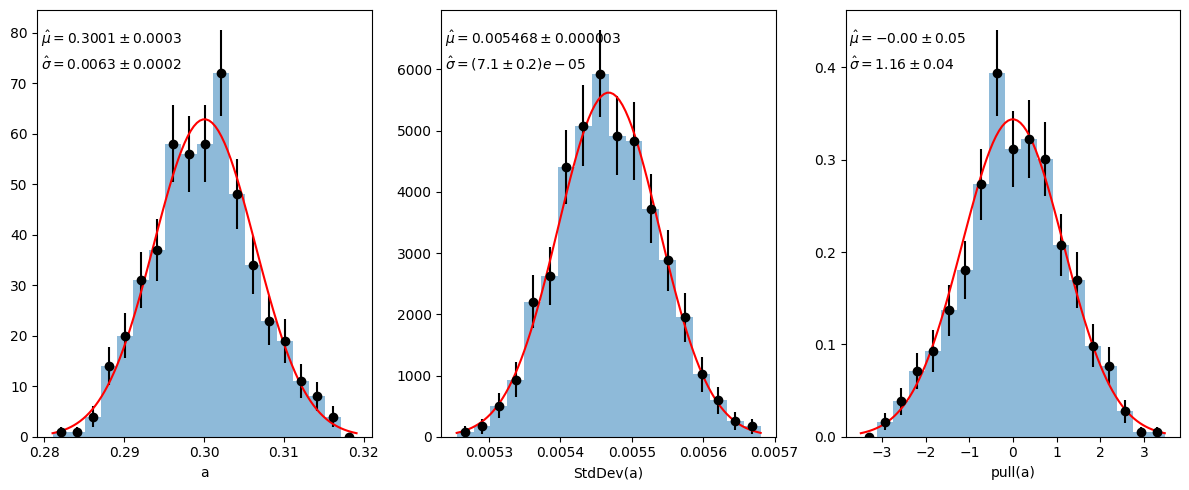

In [34]:
for size in sample_sizes:
    estimates = np.array(lambdas_sw_dict[size])
    errors = np.array(lambdas_err_sw_dict[size])
    pulls = (0.3-estimates)/errors

    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    for(i, par), ax in zip(enumerate(['a']), axes):
        
        ax = axes[0]
        plot(estimates, ax)
        ax.set_xlabel(par)

        ax = axes[1]
        plot(errors, ax)
        ax.set_xlabel(f"StdDev({par})")

        ax = axes[2]
        plot(pulls, ax)
        ax.set_xlabel(f"pull({par})")

        plt.tight_layout()

In [35]:
copy_lambdas_sw_dict = lambdas_sw_dict
copy_lambdas_err_sw_dict = lambdas_err_sw_dict

#### Bias calculation and visualization

[0.25616016267049946, 0.3451184749546061, 0.27917786724079074, 0.4337246353183941, 0.24326585783181875, 0.288029541545163, 0.2764846524043054, 0.22932535700718581, 0.25771468963339283, 0.3043556681453299, 0.2813947311000595, 0.30585289352991896, 0.2811765794811836, 0.30137986330758326, 0.3684657462571794, 0.3767796683951161, 0.3684875044278655, 0.33099057310956614, 0.30523227173852785, 0.31312967064489383, 0.35380411676782675, 0.31816289173849865, 0.3181683880786488, 0.28779576303638743, 0.30064277091153535, 0.28229546080104684, 0.2874975746788808, 0.3151763043454878, 0.300959447454334, 0.2923472752240224, 0.3240659538630768, 0.3401097043422947, 0.24378910118284192, 0.33839188412224797, 0.35278682238589765, 0.2748559910159918, 0.27611287433795373, 0.3015977996209729, 0.3459622782403633, 0.30625904077247124, 0.33283819842185713, 0.26414000810281757, 0.294437784897956, 0.2686503189091385, 0.3359669022652325, 0.31158317806156255, 0.3193655094744208, 0.2555453015438949, 0.26720837150470955

Text(0.5, 0, 'Sample size')

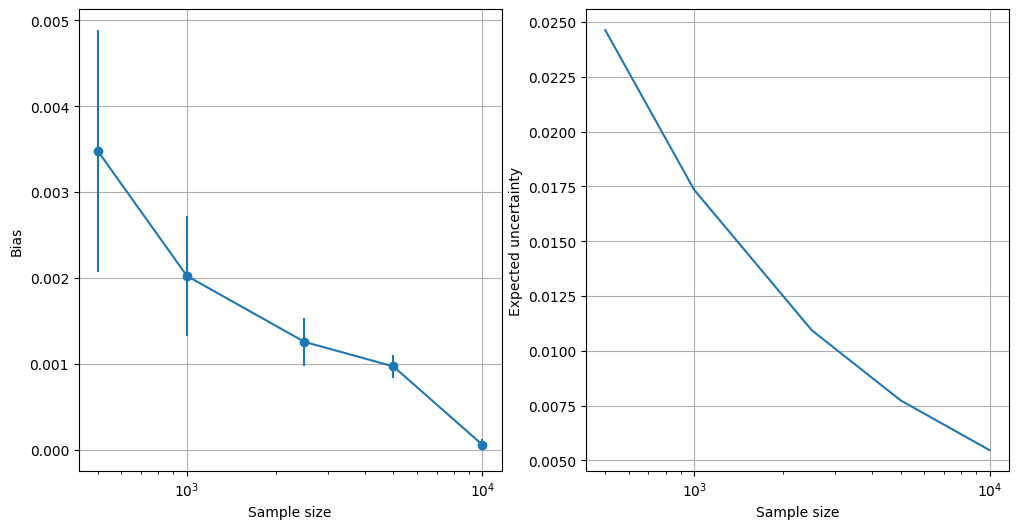

In [ ]:
arr_lambda_diff_sw = []
lambdas_sw = []
arr_lambda_est_errs_sw = []
arr_lambda_diff_std_sw = []
lambda_true = 0.3

for size in sample_sizes:
    # extract the data
    lambdas_sw = lambdas_sw_dict[size]
    print(lambdas_sw)
    lambdas_err_sw = lambdas_err_sw_dict[size]

    # calculate the bias of estimates for each sample size
    arr_lambda_diff_sw.append(lambda_true - np.mean(lambdas_sw))
    arr_lambda_est_errs_sw.append(np.mean(lambdas_err_sw))

    # calculate standard deviation for error bars
    arr_lambda_diff_std_sw.append(np.std(lambdas_sw) / np.sqrt(size))

fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].errorbar(sample_sizes, np.abs(arr_lambda_diff_sw), yerr=arr_lambda_diff_std_sw, fmt='o-', label='Bias')
ax[0].grid(True)
ax[0].set_xscale('log')
ax[0].set_ylabel("Bias")
ax[0].set_xlabel('Sample size')

ax[1].plot(sample_sizes, np.abs(arr_lambda_est_errs_sw))
ax[1].grid(True)
ax[1].set_xscale('log')
ax[1].set_ylabel('Expected uncertainty')
ax[1].set_xlabel('Sample size')

### Comparison of results: sWeights and 2D eMLE

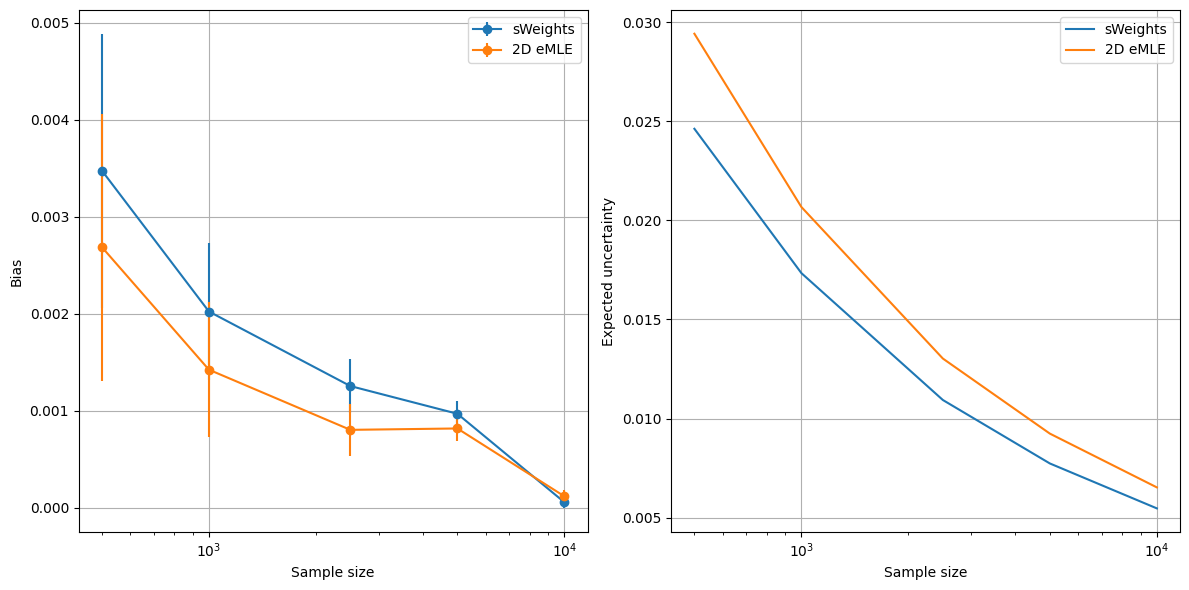

In [42]:
arr_lambda_diff_sw = []
arr_lambda_diff = []
arr_lambda_est_errs_sw = []
arr_lambda_est_errs = []
arr_lambda_diff_std_sw = []
arr_lambda_diff_std = []
lambda_true = 0.3

for size in sample_sizes:
    # extract the data
    lambdas_sw = lambdas_sw_dict[size]
    lambdas_err_sw = lambdas_err_sw_dict[size]

    estimates = storage_params[size]['estimates']
    errors = storage_params[size]['errors']
    # extract only the lambda which was at index 6
    lambda_vals = estimates[:,6]
    lambda_errs = errors[:,6]

    # calculate the bias of estimates for each sample size
    arr_lambda_diff_sw.append(lambda_true - np.mean(lambdas_sw))
    arr_lambda_est_errs_sw.append(np.mean(lambdas_err_sw))
    # calculate the bias of estimates for each sample size
    arr_lambda_diff.append(lambda_true - np.mean(lambda_vals))
    arr_lambda_est_errs.append(lambda_errs.mean())

    # calculate standard deviation for error bars
    arr_lambda_diff_std_sw.append(np.std(lambdas_sw) / np.sqrt(size))
    arr_lambda_diff_std.append(np.std(lambda_vals) / np.sqrt(size))

fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].errorbar(sample_sizes, np.abs(arr_lambda_diff_sw), yerr=arr_lambda_diff_std_sw, fmt='o-', label='sWeights')
ax[0].errorbar(sample_sizes, np.abs(arr_lambda_diff), yerr=arr_lambda_diff_std, fmt='o-', label='2D eMLE')
ax[0].grid(True)
ax[0].set_xscale('log')
ax[0].set_ylabel("Bias")
ax[0].set_xlabel('Sample size')
ax[0].legend(loc='upper right')

ax[1].plot(sample_sizes, np.abs(arr_lambda_est_errs_sw), label='sWeights')
ax[1].plot(sample_sizes, np.abs(arr_lambda_est_errs), label='2D eMLE')
ax[1].grid(True)
ax[1].set_xscale('log')
ax[1].set_ylabel('Expected uncertainty')
ax[1].set_xlabel('Sample size')
ax[1].legend(loc='upper right')

plt.tight_layout()

#### 2 std error bars:

Text(0.5, 0, 'Sample size')

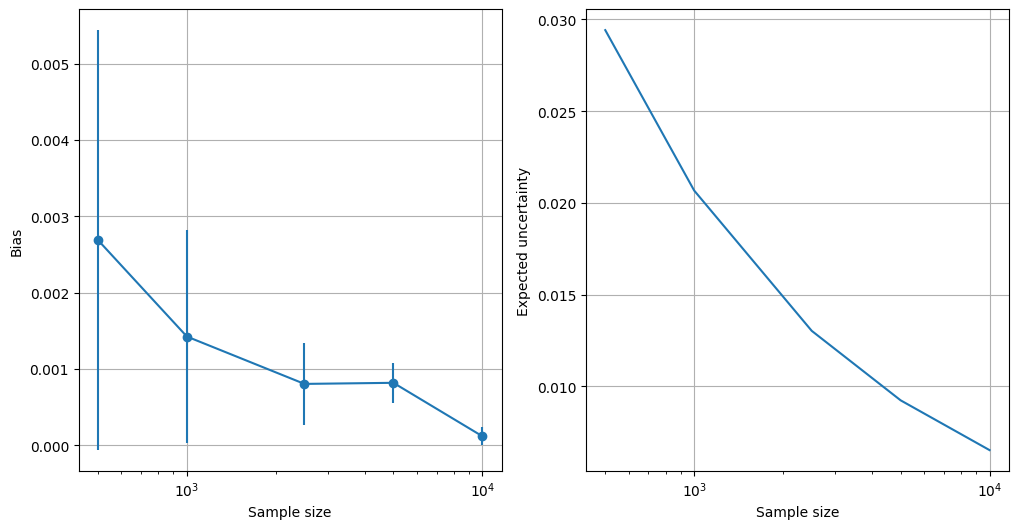

In [48]:
arr_lambda_diff = []
arr_lambda_est_errs = []
arr_lambda_est_errs_stddev = []
arr_lambda_diff_std = []
lambda_true = 0.3

for size in sample_sizes:
    # extract the data
    estimates = storage_params[size]['estimates']
    errors = storage_params[size]['errors']
    
    # extract only the lambda which was at index 6
    lambda_vals = estimates[:,6]
    lambda_errs = errors[:,6]

    # calculate the bias of estimates for each sample size
    arr_lambda_diff.append(lambda_true - np.mean(lambda_vals))
    arr_lambda_est_errs.append(lambda_errs.mean())

    # calculate standard deviation for error bars
    arr_lambda_diff_std.append(2 * np.std(lambda_vals) / np.sqrt(size))
    arr_lambda_est_errs_stddev.append(np.std(lambda_errs) / np.sqrt(size))

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].errorbar(sample_sizes, np.abs(arr_lambda_diff), yerr=arr_lambda_diff_std, fmt='o-', label='Bias')
ax[0].grid(True)
ax[0].set_xscale('log')
ax[0].set_ylabel('Bias')
ax[0].set_xlabel('Sample size')

ax[1].plot(sample_sizes, np.abs(arr_lambda_est_errs))
ax[1].grid(True)
ax[1].set_xscale('log')
ax[1].set_ylabel('Expected uncertainty')
ax[1].set_xlabel('Sample size')

